In [1]:
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import sys
sys.path.append('.')

from utils import *
from experiment import *
from dataloader.vlfc import COMPANIES
from visualize import *

# Quick start with a single experiment

We start with runing a single time series forecasting experiment. We will run return forecasting problem on AMD stock return with baseline adapative conformal inference (ACI) methods.

### Load the hyper parameters of the model

The first step is to load the config file in `bellman-conformal-inference/config`.

In [2]:
params = read_yaml('config/rtfc-aci-AMD.yaml')

The naming of the config file follows the convention of `TASK_NAME-METHOD_NAME-TASK_DATASET.yaml`. In this case, the config file looks like

```
> params

{'task': 'rtfc',        # the return forecasting problem, avalibale choices ['rtfc', 'vlfc']
 'method': 'aci',       # the adapative conformal algorithm to use. 'aci' means baseline Adapative Conformal Algorithm
 'id': 'AMD',           # the dataset to be used by the experiment. They can be found in 'data/'
 'alpha0': 0.1,         # target miscoverage rate. In this case 10%
 'gamma': 0.1,          # step size for either ACI or BCI
 'lambda_init': 0.9,
 'lambda_max': 1.0,
 'lambda_min': 0.0}
```

We can run the experiment by using the `.run()` method, which captures all the details of computing $\alpha_t$ for each $t$. To hack around the code, please see `experiment.py` for the logic of computing $\alpha_t$.

### Build the experiment object and run the experiment

The experiment object created by

In [3]:
exp = ForecastingExperiment(params)

In [4]:
exp.run()

2026-01-27 00:41:50,272 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-01-27 00:41:52,766 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 2.494448184967041s


After we run the experiment, we can optionally save the experiment. They will be saved in `bellman-conformal-inference/result/*`. This include the full trajectory of the experiment, and the hyper parameter used.

In [5]:
exp.save()

Finally, we can visualize the experiment by calling the `visualize_single_exp(**)` function defined in `bellman-conformal-inference/visualize.py`.

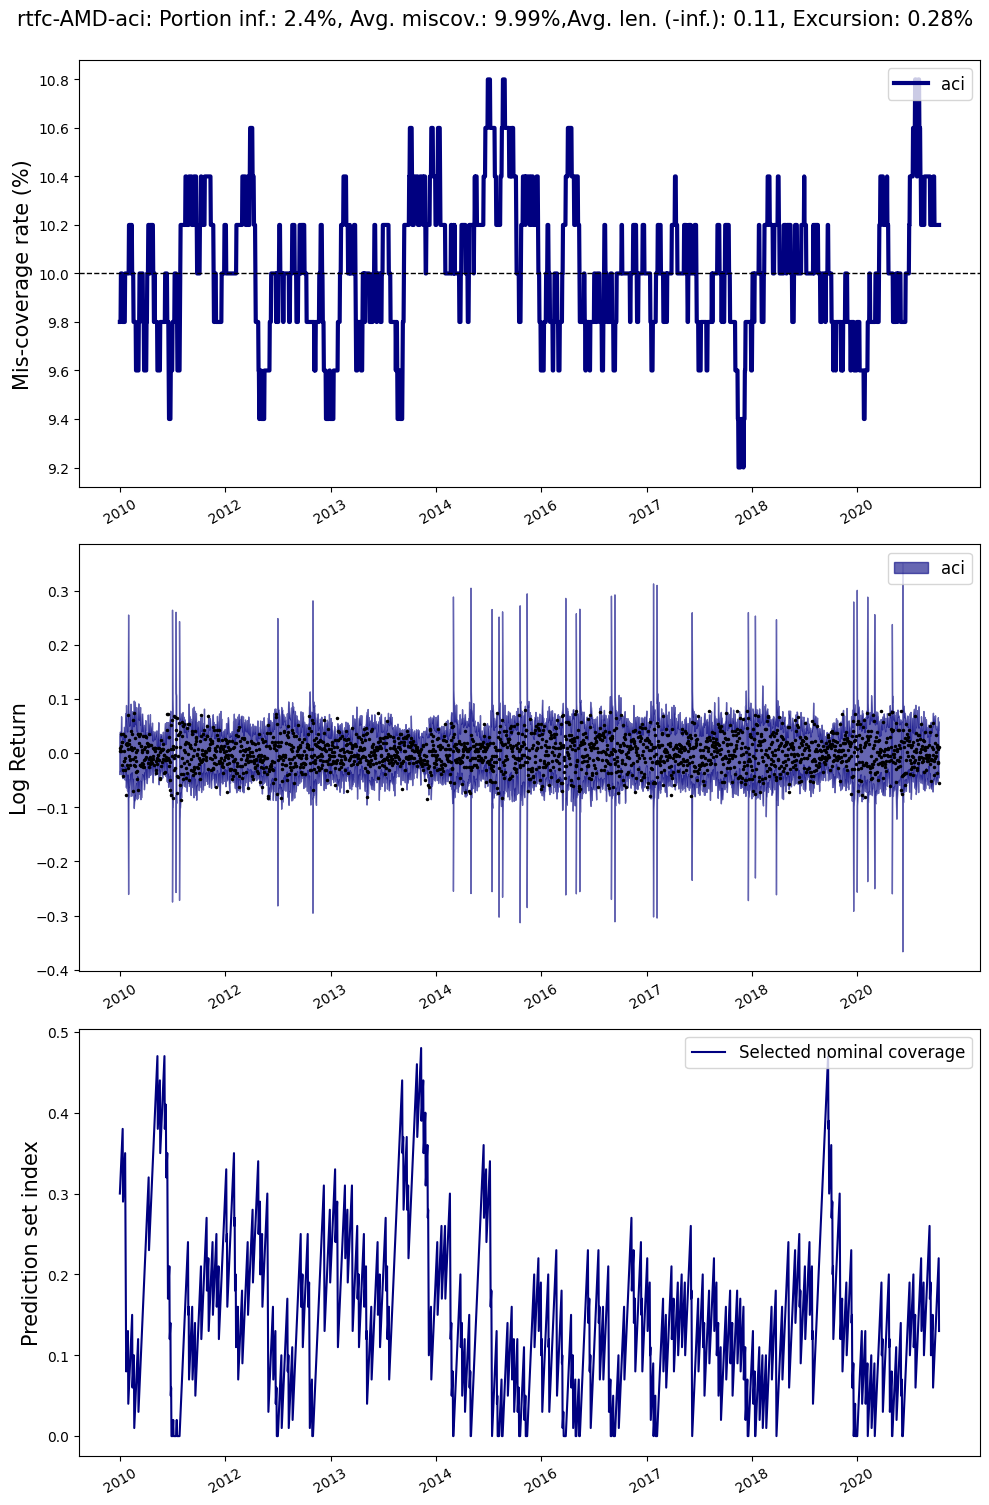

In [6]:
visualize_single_exp(exp.params, exp.result)

# Comparsion of three experiments

Next we demonstrate how to compare performance across three methods -- ACI, BCI, fixed $\alpha_t$ for the same experiment.

In [7]:
exp_aci = ForecastingExperiment(read_yaml('config/rtfc-aci-AMD.yaml'))
exp_aci.run()

exp_bci = ForecastingExperiment(read_yaml('config/rtfc-bci-AMD.yaml'))
exp_bci.run()

exp_fixed = ForecastingExperiment(read_yaml('config/rtfc-fixed-AMD.yaml'))
exp_fixed.run()

2026-01-27 00:42:02,971 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-01-27 00:42:05,405 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 2.4344680309295654s
2026-01-27 00:42:05,414 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 STARTED
2026-01-27 00:42:13,216 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 ENDED in 7.802186012268066s
2026-01-27 00:42:13,224 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA STARTED
2026-01-27 00:42:15,517 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 2.293308973312378s


As before, we can visualize the comparsion as `visualize_three_exp`. In contrast to the previous plot, the figure first panel is the moving average mis-coverage rate, and the bottom panel is the moving average of interval length. The performance metric is given in the title of the plot:

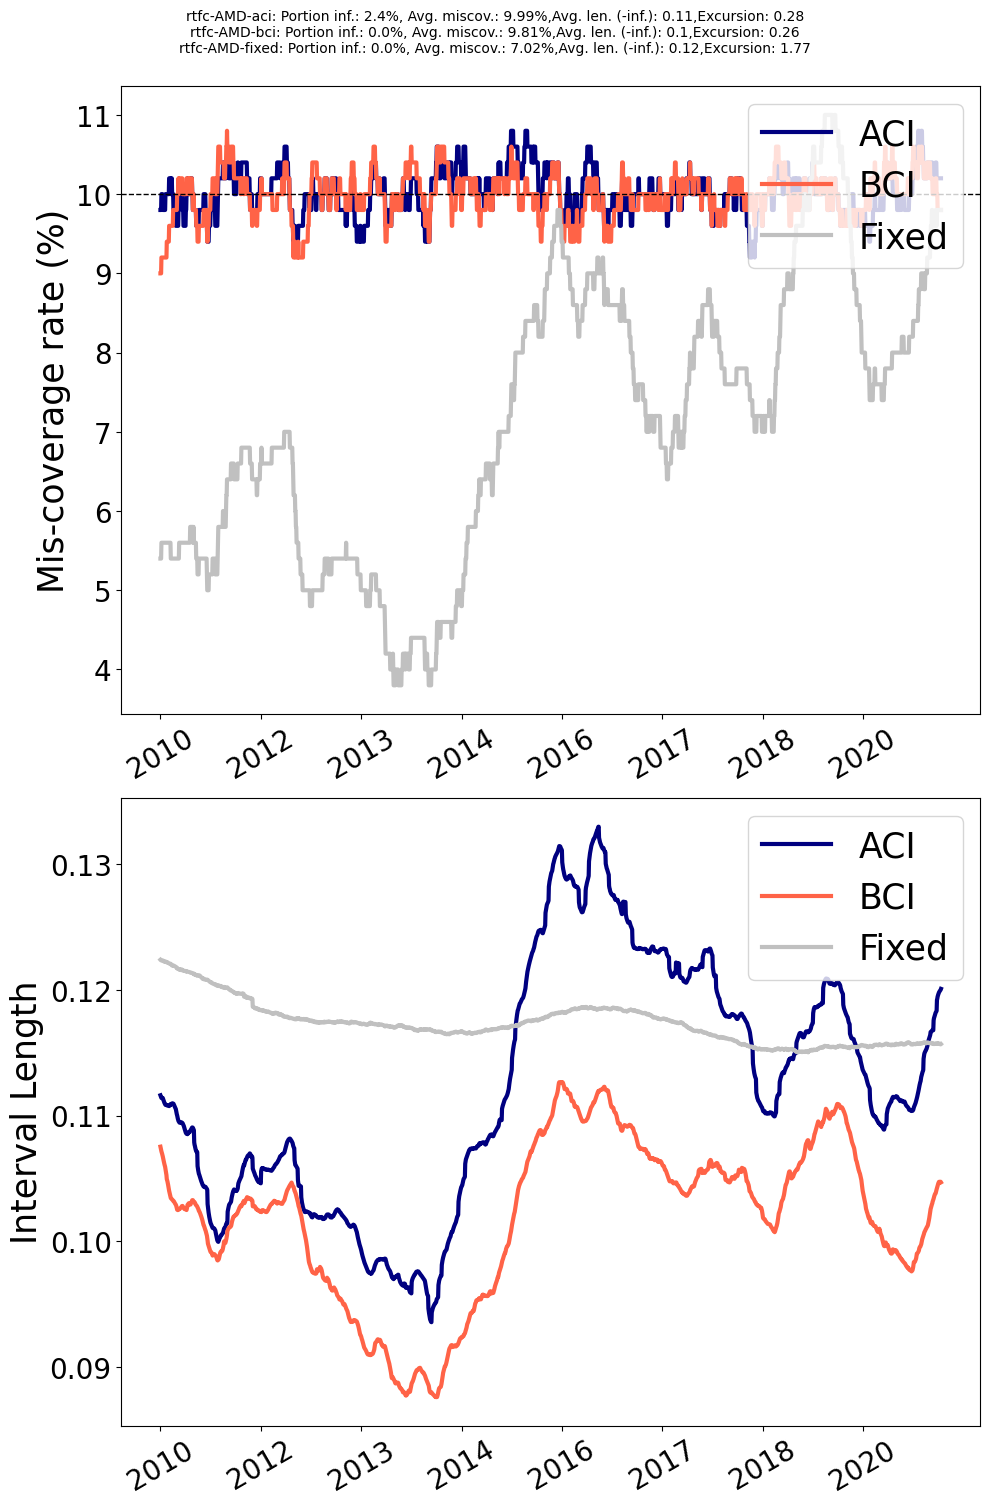

In [8]:
visualize_three_exp(exp_aci.params, exp_aci.result,
                    exp_bci.params, exp_bci.result,
                    exp_fixed.params, exp_fixed.result)

In [13]:
"""
Complete PID Experiment Runner for All Datasets
Runs: AMD, Amazon, Nvidia (with typo fix)
Generates: Summary tables and visualizations
"""

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log


# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def compute_local_miscoverage_variance_original(result_df, window=50):
    """Variance of rolling miscoverage rate - ORIGINAL METHOD (alpha > beta)"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce').values
    beta = pd.to_numeric(result_df['beta'], errors='coerce').values
    
    err_ind = (alpha > beta).astype(float)
    local_miscov = pd.Series(err_ind).rolling(window=window, min_periods=1).mean()
    return local_miscov.var()


def compute_avg_miscoverage_original(result_df):
    """Average miscoverage rate - ORIGINAL METHOD (alpha > beta) - matches paper"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce').values
    beta = pd.to_numeric(result_df['beta'], errors='coerce').values
    
    err_ind = (alpha > beta).astype(float)
    return err_ind.mean()


def compute_avg_miscoverage_pid(scores, pid_qs):
    """Average miscoverage rate - PID METHOD (q >= score)"""
    covered = (pid_qs >= scores).astype(float)
    return 1 - covered.mean()


def compute_avg_length(result_df):
    """Average interval length"""
    upper = pd.to_numeric(result_df['upper'], errors='coerce').values
    lower = pd.to_numeric(result_df['lower'], errors='coerce').values
    
    lengths = upper - lower
    finite_mask = np.isfinite(lengths)
    finite_lengths = lengths[finite_mask]
    return finite_lengths.mean() if len(finite_lengths) > 0 else np.inf


def run_pid_once(scores, y_pred_center, y_true, alpha, eta, csat, ki, t_burnin=100):
    """Run PID with given parameters and return metrics"""
    if eta <= 0:
        return {'variance': 1e10, 'miscoverage': 1.0, 'avg_length': np.inf, 'valid': False}
    
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=alpha, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=t_burnin
        )
        
        pid_qs = np.array(pid_out['q'], dtype=np.float64)
        pid_qs = np.maximum(pid_qs, 0.0)
        
        if np.any(np.isnan(pid_qs)) or np.any(np.isinf(pid_qs)):
            return {'variance': 1e10, 'miscoverage': 1.0, 'avg_length': np.inf, 'valid': False}
        
        y_pred = np.array(y_pred_center, dtype=np.float64)
        y_true_arr = np.array(y_true, dtype=np.float64)
        
        upper = y_pred + pid_qs
        lower = y_pred - pid_qs
        
        is_covered = (y_true_arr >= lower) & (y_true_arr <= upper)
        miscov_arr = 1 - is_covered.astype(float)
        local_miscov = pd.Series(miscov_arr).rolling(window=50, min_periods=1).mean()
        variance = local_miscov.var()
        miscov = miscov_arr.mean()
        
        lengths = upper - lower
        avg_len = np.mean(lengths[np.isfinite(lengths)])
        
        return {
            'variance': variance,
            'miscoverage': miscov,
            'avg_length': avg_len,
            'valid': True,
            'q': pid_qs
        }
    except Exception as e:
        return {'variance': 1e10, 'miscoverage': 1.0, 'avg_length': np.inf, 'valid': False}


def binary_search_eta(scores, y_pred_center, y_true, alpha, csat, ki,
                      target_variance, eta_min=1e-6, eta_max=None, 
                      tolerance=0.10, max_iter=30, verbose=False):
    """Binary search for optimal η"""
    
    if eta_max is None:
        eta_max = np.percentile(scores, 99)
    
    # Probe
    test_etas = np.logspace(np.log10(max(eta_min, 1e-8)), np.log10(eta_max), 10)
    probe_results = []
    
    for eta_test in test_etas:
        metrics = run_pid_once(scores, y_pred_center, y_true, alpha, eta_test, csat, ki)
        probe_results.append((eta_test, metrics))
    
    valid_results = [(eta, m) for eta, m in probe_results if m['valid']]
    
    if len(valid_results) == 0:
        return {'optimal_eta': eta_min, 'metrics': probe_results[0][1], 'converged': False}
    
    best_eta, best_metrics = min(valid_results, 
                                  key=lambda x: abs(x[1]['variance'] - target_variance))
    best_diff = abs(best_metrics['variance'] - target_variance)
    best_pct_diff = best_diff / target_variance if target_variance > 0 else best_diff
    
    if best_pct_diff <= tolerance:
        return {'optimal_eta': best_eta, 'metrics': best_metrics, 'converged': True}
    
    # Find bracket
    eta_low, eta_high = eta_min, eta_max
    var_low, var_high = None, None
    
    for i in range(len(probe_results) - 1):
        eta1, m1 = probe_results[i]
        eta2, m2 = probe_results[i + 1]
        if m1['valid'] and m2['valid']:
            if (m1['variance'] - target_variance) * (m2['variance'] - target_variance) <= 0:
                eta_low, eta_high = eta1, eta2
                var_low, var_high = m1['variance'], m2['variance']
                break
    
    if var_low is None:
        return {'optimal_eta': best_eta, 'metrics': best_metrics, 'converged': False}
    
    # Binary search
    for iteration in range(max_iter):
        eta_mid = np.sqrt(eta_low * eta_high)
        metrics_mid = run_pid_once(scores, y_pred_center, y_true, alpha, eta_mid, csat, ki)
        
        if not metrics_mid['valid']:
            eta_mid = (eta_low + eta_high) / 2
            metrics_mid = run_pid_once(scores, y_pred_center, y_true, alpha, eta_mid, csat, ki)
        
        if not metrics_mid['valid']:
            break
        
        var_mid = metrics_mid['variance']
        diff = abs(var_mid - target_variance)
        pct_diff = diff / target_variance if target_variance > 0 else diff
        
        if diff < best_diff:
            best_eta = eta_mid
            best_metrics = metrics_mid
            best_diff = diff
        
        if pct_diff <= tolerance:
            return {'optimal_eta': eta_mid, 'metrics': metrics_mid, 'converged': True}
        
        if (var_mid - target_variance) * (var_low - target_variance) <= 0:
            eta_high = eta_mid
            var_high = var_mid
        else:
            eta_low = eta_mid
            var_low = var_mid
        
        if abs(np.log(eta_high + 1e-10) - np.log(eta_low + 1e-10)) < 1e-4:
            break
    
    return {'optimal_eta': best_eta, 'metrics': best_metrics, 'converged': False}


# =============================================================================
# MAIN EXPERIMENT FUNCTION
# =============================================================================

def run_pid_experiment_for_dataset(dataset_name, task='rtfc', target_gamma=0.1, 
                                   ki_percentiles=[99, 95, 90, 75, 50]):
    """
    Run complete PID experiment for one dataset
    """
    print(f"\n{'='*70}")
    print(f"DATASET: {dataset_name} | Task: {task} | γ={target_gamma}")
    print(f"{'='*70}")
    
    # Handle Nvidia typo for fixed config
    fixed_config_name = 'Nvdia' if dataset_name == 'Nvidia' else dataset_name
    
    # Load baselines
    print(f"  Loading baselines...")
    exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{fixed_config_name}.yaml'))
    exp_fixed.run()
    
    exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci-{dataset_name}.yaml'))
    exp_bci.run()
    
    aci_config = read_yaml(f'config/{task}-aci-{dataset_name}.yaml')
    aci_config['gamma'] = target_gamma
    exp_aci = ForecastingExperiment(aci_config)
    exp_aci.run()
    
    print(f"    ✓ Fixed: {len(exp_fixed.result)} samples")
    print(f"    ✓ BCI: {len(exp_bci.result)} samples")
    print(f"    ✓ ACI (γ={target_gamma}): {len(exp_aci.result)} samples")
    
    # Prepare data
    y_true = exp_fixed.result['true_y'].values
    upper = exp_fixed.result['upper'].values
    lower = exp_fixed.result['lower'].values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    
    # Target variance from ACI
    target_variance = compute_local_miscoverage_variance_original(exp_bci.result)
    
    print(f"\n  Target variance: {target_variance:.2e}")
    print(f"  Csat: {csat:.4f}")
    
    # Tune PID for each K_I percentile
    print(f"\n  Tuning PID for {len(ki_percentiles)} K_I values...")
    
    pid_results = []
    pid_params_list = []
    
    for pct in ki_percentiles:
        ki = np.percentile(scores, pct)
        print(f"    K_I {pct}% = {ki:.6f}...", end=" ")
        
        result = binary_search_eta(
            scores, y_pred_center, y_true,
            alpha=0.1, csat=csat, ki=ki,
            target_variance=target_variance,
            tolerance=0.10
        )
        
        if result and result['metrics']['valid']:
            eta = result['optimal_eta']
            print(f"η={eta:.6f} ✓")
            
            # Run PID with optimal eta to get full results
            pid_out = quantile_integrator_log(
                scores=scores, alpha=0.1, lr=eta,
                Csat=csat, KI=ki, ahead=1, T_burnin=100
            )
            
            df_pid = exp_fixed.result.copy()
            pid_qs = np.maximum(np.array(pid_out['q'], dtype=np.float64), 0)
            df_pid['upper'] = y_pred_center + pid_qs
            df_pid['lower'] = y_pred_center - pid_qs
            df_pid['alpha'] = 0.1
            # Note: PID doesn't use beta - it uses q >= score for coverage
            
            pid_results.append(df_pid)
            pid_params_list.append({
                'method': f'PID-{pct}%',
                'task': task,
                'id': dataset_name,
                'alpha0': 0.1,
                'eta': eta,
                'KI': ki,
                'KI_percentile': pct,
                'metrics': result['metrics'],
                'scores': scores,  # Store for miscoverage calculation
                'pid_qs': pid_qs   # Store for miscoverage calculation
            })
        else:
            print(f"FAILED ✗")
    
    # Compile results
    results = {
        'dataset': dataset_name,
        'task': task,
        'gamma': target_gamma,
        'aci_result': exp_aci.result,
        'aci_params': exp_aci.params,
        'bci_result': exp_bci.result,
        'bci_params': exp_bci.params,
        'fixed_result': exp_fixed.result,
        'fixed_params': exp_fixed.params,
        'pid_results': pid_results,
        'pid_params_list': pid_params_list,
        'target_variance': target_variance
    }
    
    # Save
    filename = f'{dataset_name}_{task}_PID_gamma{target_gamma}.pkl'
    with open(filename, 'wb') as f:
        pickle.dump(results, f)
    print(f"\n  ✓ Saved: {filename}")
    
    return results


# =============================================================================
# VISUALIZATION FUNCTION
# =============================================================================

def create_summary_visualization(results):
    """Create summary table and plots for one dataset"""
    
    dataset = results['dataset']
    gamma = results['gamma']
    
    # Extract metrics for all methods (use α>β for baselines to match paper)
    aci_var = compute_local_miscoverage_variance_original(results['aci_result'])
    aci_miscov = compute_avg_miscoverage_original(results['aci_result'])  # ← α>β method
    aci_length = compute_avg_length(results['aci_result'])
    
    bci_var = compute_local_miscoverage_variance_original(results['bci_result'])
    bci_miscov = compute_avg_miscoverage_original(results['bci_result'])  # ← α>β method
    bci_length = compute_avg_length(results['bci_result'])
    
    fixed_var = compute_local_miscoverage_variance_original(results['fixed_result'])
    fixed_miscov = compute_avg_miscoverage_original(results['fixed_result'])  # ← α>β method
    fixed_length = compute_avg_length(results['fixed_result'])
    
    # Create figure
    fig = plt.figure(figsize=(16, 10))
    
    # =========================================================================
    # 1. Summary Table
    # =========================================================================
    ax_table = plt.subplot(3, 1, 1)
    ax_table.axis('off')
    
    table_data = []
    headers = ['Method', 'Variance', 'Var vs ACI', 'Miscov (%)†', 'Avg Length', 'Len vs ACI', 'η', 'K_I']
    
    # Baselines
    table_data.append(['ACI', f'{aci_var:.2e}', '-', f'{aci_miscov*100:.2f}', 
                      f'{aci_length:.4f}', '-', '-', '-'])
    table_data.append(['BCI', f'{bci_var:.2e}', f'{(bci_var/aci_var-1)*100:+.1f}%', f'{bci_miscov*100:.2f}', 
                      f'{bci_length:.4f}', f'{(bci_length/aci_length-1)*100:+.1f}%', '-', '-'])
    table_data.append(['Fixed', f'{fixed_var:.2e}', f'{(fixed_var/aci_var-1)*100:+.1f}%', f'{fixed_miscov*100:.2f}', 
                      f'{fixed_length:.4f}', f'{(fixed_length/aci_length-1)*100:+.1f}%', '-', '-'])
    
    # PID variants (use q >= score method from PID paper)
    for df_pid, params in zip(results['pid_results'], results['pid_params_list']):
        pid_miscov = compute_avg_miscoverage_pid(params['scores'], params['pid_qs'])  # ← PID method
        pid_length = compute_avg_length(df_pid)
        
        # Compute variance (need to construct beta column)
        df_pid_temp = df_pid.copy()
        df_pid_temp['beta'] = df_pid_temp['alpha']  # Dummy beta
        
        pct = params['KI_percentile']
        eta = params['eta']
        ki = params['KI']
        var = params['metrics']['variance']
        
        table_data.append([
            f'PID-{pct}%',
            f'{var:.2e}',
            f'{(var/aci_var-1)*100:+.1f}%',
            f'{pid_miscov*100:.2f}',
            f'{pid_length:.4f}',
            f'{(pid_length/aci_length-1)*100:+.1f}%',
            f'{eta:.4f}',
            f'{ki:.4f}'
        ])
    
    table = ax_table.table(cellText=table_data, colLabels=headers, cellLoc='center',
                           loc='center', bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 2)
    
    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    ax_table.set_title(f'{dataset} {results["task"].upper()}: PID Results (γ_ACI = {gamma})\n† Miscov: α>β for BCI/ACI/Fixed, q≥score for PID',
                      fontsize=14, fontweight='bold', pad=20)
    
    # =========================================================================
    # 2. Bar Charts
    # =========================================================================
    methods = ['ACI', 'BCI', 'Fixed'] + [f'PID-{p["KI_percentile"]}%' for p in results['pid_params_list']]
    
    miscovs = [aci_miscov*100, bci_miscov*100, fixed_miscov*100] + \
              [compute_avg_miscoverage_pid(p['scores'], p['pid_qs'])*100 for p in results['pid_params_list']]  # ← PID method
    
    lengths = [aci_length, bci_length, fixed_length] + \
              [compute_avg_length(df) for df in results['pid_results']]
    
    colors = ['#4472C4', '#ED7D31', '#A5A5A5'] + ['#70AD47'] * len(results['pid_results'])
    
    # Miscoverage
    ax_miscov = plt.subplot(3, 2, 3)
    ax_miscov.bar(range(len(methods)), miscovs, color=colors, alpha=0.8, edgecolor='black')
    ax_miscov.axhline(10, color='red', linestyle='--', linewidth=2, label='Target: 10%')
    ax_miscov.set_ylabel('Miscoverage Rate (%)', fontsize=11, fontweight='bold')
    ax_miscov.set_title('Miscoverage Rate', fontsize=12, fontweight='bold')
    ax_miscov.set_xticks(range(len(methods)))
    ax_miscov.set_xticklabels(methods, rotation=45, ha='right', fontsize=9)
    ax_miscov.legend(fontsize=8)
    ax_miscov.grid(axis='y', alpha=0.3)
    
    # Interval Length
    ax_len = plt.subplot(3, 2, 4)
    ax_len.bar(range(len(methods)), lengths, color=colors, alpha=0.8, edgecolor='black')
    ax_len.axhline(aci_length, color='navy', linestyle='--', linewidth=2, label=f'ACI: {aci_length:.4f}')
    ax_len.set_ylabel('Average Interval Width', fontsize=11, fontweight='bold')
    ax_len.set_title('Interval Length', fontsize=12, fontweight='bold')
    ax_len.set_xticks(range(len(methods)))
    ax_len.set_xticklabels(methods, rotation=45, ha='right', fontsize=9)
    ax_len.legend(fontsize=8)
    ax_len.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    filename = f'{dataset}_{results["task"]}_PID_summary_gamma{gamma}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: {filename}")
    plt.close()


# =============================================================================
# RUN ALL EXPERIMENTS
# =============================================================================

def run_all_experiments(task='rtfc', target_gamma=0.1):
    """Run PID experiments for all datasets"""
    
    datasets = ['AMD', 'Amazon', 'Nvidia']
    
    print("\n" + "="*70)
    print(f"RUNNING PID EXPERIMENTS FOR ALL DATASETS")
    print(f"Task: {task} | Target γ: {target_gamma}")
    print("="*70)
    
    all_results = {}
    
    for dataset in datasets:
        try:
            results = run_pid_experiment_for_dataset(dataset, task, target_gamma)
            all_results[dataset] = results
            create_summary_visualization(results)
        except Exception as e:
            print(f"\n  ✗ Error with {dataset}: {e}")
            import traceback
            traceback.print_exc()
    
    print("\n" + "="*70)
    print("ALL EXPERIMENTS COMPLETE!")
    print("="*70)
    
    return all_results


if __name__ == "__main__":
    # Run for gamma = 0.1 (tight control)
    results_tight = run_all_experiments(task='rtfc', target_gamma=0.1)
    
    # Run for gamma = 0.008 (loose control)
    results_loose = run_all_experiments(task='rtfc', target_gamma=0.008)

2026-01-28 21:14:25,011 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA STARTED



RUNNING PID EXPERIMENTS FOR ALL DATASETS
Task: rtfc | Target γ: 0.1

DATASET: AMD | Task: rtfc | γ=0.1
  Loading baselines...


2026-01-28 21:14:27,193 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 2.1818480491638184s
2026-01-28 21:14:27,201 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 STARTED
2026-01-28 21:14:34,502 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 ENDED in 7.301029920578003s
2026-01-28 21:14:34,512 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED


KeyboardInterrupt: 

In [ ]:
"""
Final PID Experiment Runner
Target: Match BCI Variance (Strict)
Constraint: Search Eta in [0, 5*B_99]
Plots: 4 lines (ACI, BCI, Fixed, PID)
Output: 6 Graphs (3 Datasets x 2 Gammas) + Summary Tables
"""

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

# Increase recursion depth
sys.setrecursionlimit(10000)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def compute_local_miscoverage_variance_original(result_df, window=50):
    """Variance of rolling miscoverage rate (alpha > beta)"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce').values
    beta = pd.to_numeric(result_df['beta'], errors='coerce').values
    err_ind = (alpha > beta).astype(float)
    local_miscov = pd.Series(err_ind).rolling(window=window, min_periods=1).mean()
    return local_miscov.var()

def compute_avg_miscoverage_original(result_df):
    """Average miscoverage rate (alpha > beta)"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce').values
    beta = pd.to_numeric(result_df['beta'], errors='coerce').values
    err_ind = (alpha > beta).astype(float)
    return err_ind.mean()

def compute_avg_miscoverage_pid(scores, pid_qs):
    """Average miscoverage rate - PID METHOD (q >= score)"""
    covered = (pid_qs >= scores).astype(float)
    return 1 - covered.mean()

def compute_avg_length(result_df):
    """Average interval length"""
    upper = pd.to_numeric(result_df['upper'], errors='coerce').values
    lower = pd.to_numeric(result_df['lower'], errors='coerce').values
    lengths = upper - lower
    finite_lengths = lengths[np.isfinite(lengths)]
    return finite_lengths.mean() if len(finite_lengths) > 0 else np.inf

def run_pid_once(scores, y_pred_center, y_true, alpha, eta, csat, ki, t_burnin=100):
    """Run PID with given parameters"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=alpha, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=t_burnin
        )
        pid_qs = np.maximum(np.array(pid_out['q'], dtype=np.float64), 0.0)
        
        # Calculate Variance
        upper = y_pred_center + pid_qs
        lower = y_pred_center - pid_qs
        is_covered = (y_true >= lower) & (y_true <= upper)
        miscov_arr = 1 - is_covered.astype(float)
        local_miscov = pd.Series(miscov_arr).rolling(window=50, min_periods=1).mean()
        variance = local_miscov.var()
        
        return {'variance': variance, 'valid': True, 'q': pid_qs}
    except:
        return {'variance': 1e10, 'valid': False}

def binary_search_eta(scores, y_pred_center, y_true, alpha, csat, ki,
                      target_variance, eta_max_constraint):
    """Binary search for optimal η within [0, 5*B_99]"""
    low, high = 1e-6, eta_max_constraint
    best_eta = low
    best_diff = 1e10
    best_result = None
    
    # 20 Iterations is plenty for precision
    for _ in range(20):
        mid = np.sqrt(low * high)
        res = run_pid_once(scores, y_pred_center, y_true, alpha, mid, csat, ki)
        
        if not res['valid']:
            break # Safety break
            
        diff = res['variance'] - target_variance
        
        if abs(diff) < best_diff:
            best_diff = abs(diff)
            best_eta = mid
            best_result = res
            
        # If PID Variance > Target (Too Wiggly) -> Reduce Eta -> high = mid
        # If PID Variance < Target (Too Stable) -> Increase Eta -> low = mid
        if res['variance'] > target_variance:
            high = mid
        else:
            low = mid
            
    # Final run with best eta
    if best_result is None:
        best_result = run_pid_once(scores, y_pred_center, y_true, alpha, best_eta, csat, ki)
        
    return best_eta, best_result

# =============================================================================
# MAIN RUNNER
# =============================================================================

def run_experiment_for_dataset(dataset_name, gammas=[0.1, 0.008]):
    print(f"\n{'='*70}")
    print(f"PROCESSING: {dataset_name}")
    print(f"{'='*70}")
    
    # 1. Load Baselines
    try:
        exp_fixed = ForecastingExperiment(read_yaml(f'config/rtfc-fixed-{dataset_name}.yaml'))
        exp_bci = ForecastingExperiment(read_yaml(f'config/rtfc-bci-{dataset_name}.yaml'))
    except FileNotFoundError:
        if dataset_name == 'Nvidia':
            print("  ! Using fallback 'Nvdia' filename...")
            exp_fixed = ForecastingExperiment(read_yaml(f'config/rtfc-fixed-Nvdia.yaml'))
            exp_bci = ForecastingExperiment(read_yaml(f'config/rtfc-bci-Nvdia.yaml'))
        else:
            raise
    exp_fixed.run()
    exp_bci.run()
    
    # 2. Metrics & Targets
    bci_var = compute_local_miscoverage_variance_original(exp_bci.result)
    bci_mis = compute_avg_miscoverage_original(exp_bci.result)
    bci_len = compute_avg_length(exp_bci.result)
    
    fix_var = compute_local_miscoverage_variance_original(exp_fixed.result)
    fix_mis = compute_avg_miscoverage_original(exp_fixed.result)
    fix_len = compute_avg_length(exp_fixed.result)
    
    print(f"  Target Variance (BCI): {bci_var:.2e}")
    
    # 3. Setup PID Data
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    
    # 4. Setup Constraint (5 * B_99)
    B_99 = np.percentile(scores, 99)
    ki = B_99 # KI is fixed at 99th percentile
    eta_max = 5 * B_99
    
    print(f"  Constraint [0, 5B]: Max Eta = {eta_max:.4f} (B={B_99:.4f})")
    
    # 5. Run PID Search
    best_eta, best_res = binary_search_eta(scores, y_pred_center, y_true, 0.1, csat, ki, bci_var, eta_max)
    
    # Construct PID DataFrame
    pid_qs = best_res['q']
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + pid_qs
    df_pid['lower'] = y_pred_center - pid_qs
    
    pid_var = best_res['variance']
    pid_mis = compute_avg_miscoverage_pid(scores, pid_qs)
    pid_len = compute_avg_length(df_pid)
    
    print(f"  PID Result: Eta={best_eta:.4f}, Var={pid_var:.2e}")
    
    # 6. Loop Gammas for Plots
    for gamma in gammas:
        print(f"    Running Gamma={gamma}...")
        try:
            aci_config = read_yaml(f'config/rtfc-aci-{dataset_name}.yaml')
        except:
             if dataset_name == 'Nvidia': aci_config = read_yaml(f'config/rtfc-aci-Nvdia.yaml')
        
        aci_config['gamma'] = gamma
        exp_aci = ForecastingExperiment(aci_config)
        exp_aci.run()
        
        aci_var = compute_local_miscoverage_variance_original(exp_aci.result)
        aci_mis = compute_avg_miscoverage_original(exp_aci.result)
        aci_len = compute_avg_length(exp_aci.result)
        
        # --- GENERATE SUMMARY TABLE ---
        print(f"\nSUMMARY TABLE: {dataset_name} (Gamma={gamma})")
        print(f"{'Method':<10} | {'Variance':<10} | {'Var vs BCI':<10} | {'Miscov(%)':<10} | {'Length':<10} | {'Len vs BCI':<10}")
        print("-" * 75)
        print(f"{'ACI':<10} | {aci_var:.2e}   | -          | {aci_mis*100:<10.2f} | {aci_len:<10.4f} | -")
        print(f"{'BCI':<10} | {bci_var:.2e}   | 0.0%       | {bci_mis*100:<10.2f} | {bci_len:<10.4f} | 0.0%")
        print(f"{'Fixed':<10} | {fix_var:.2e}   | {(fix_var/bci_var-1)*100:+.1f}%     | {fix_mis*100:<10.2f} | {fix_len:<10.4f} | {(fix_len/bci_len-1)*100:+.1f}%")
        print(f"{'PID':<10} | {pid_var:.2e}   | {(pid_var/bci_var-1)*100:+.1f}%     | {pid_mis*100:<10.2f} | {pid_len:<10.4f} | {(pid_len/bci_len-1)*100:+.1f}%")
        print("-" * 75)
        
        # --- PLOTTING ---
        def clean(df): return df.apply(pd.to_numeric, errors='coerce')
        def get_lines(df, method_type):
            if method_type == 'baseline':
                err = (df['alpha'] > df['beta']).astype(float)
            else:
                is_cov = (df['true_y'] >= df['lower']) & (df['true_y'] <= df['upper'])
                err = (~is_cov).astype(float)
            miscov = err.rolling(50).mean() * 100
            length = (df['upper'] - df['lower']).rolling(50).mean()
            return miscov.values, length.values # RETURN VALUES (ARRAYS) NOT SERIES

        aci_m, aci_l = get_lines(clean(exp_aci.result), 'baseline')
        bci_m, bci_l = get_lines(clean(exp_bci.result), 'baseline')
        fix_m, fix_l = get_lines(clean(exp_fixed.result), 'baseline')
        pid_m, pid_l = get_lines(clean(df_pid), 'pid')
        
        # Setup X-Axis Indices (skip first 50 which are NaN from smoothing)
        n_points = len(aci_m)
        x_vals = np.arange(n_points)
        tick_indices = list(range(50, n_points, 100))
        tick_labels = [exp_aci.result.index[i].strftime("%Y-%m") for i in tick_indices]
        
        fig, axs = plt.subplots(2, 1, figsize=(10, 15))
        
        # Miscoverage
        axs[0].plot(x_vals, aci_m, color='navy', label=f'ACI', linewidth=2)
        axs[0].plot(x_vals, bci_m, color='tomato', label='BCI', linewidth=2)
        axs[0].plot(x_vals, fix_m, color='silver', label='Fixed', linewidth=2)
        axs[0].plot(x_vals, pid_m, color='green', linestyle='--', label=f'PID', linewidth=2.5)
        axs[0].axhline(10, color='black', linestyle='--')
        axs[0].set_ylabel('Miscoverage Rate (%)', fontsize=16)
        axs[0].legend(loc='upper right', fontsize=12)
        axs[0].set_title(f'{dataset_name}: Miscoverage (Target: BCI Variance)', fontsize=18)
        
        # Length
        axs[1].plot(x_vals, aci_l, color='navy', label=f'ACI', linewidth=2)
        axs[1].plot(x_vals, bci_l, color='tomato', label='BCI', linewidth=2)
        axs[1].plot(x_vals, fix_l, color='silver', label='Fixed', linewidth=2)
        axs[1].plot(x_vals, pid_l, color='green', linestyle='--', label='PID', linewidth=2.5)
        axs[1].set_ylabel('Interval Width', fontsize=16)
        axs[1].set_title('Interval Width Comparison', fontsize=18)
        axs[1].legend(loc='upper right', fontsize=12)
        
        for ax in axs:
            ax.set_xticks(tick_indices)
            ax.set_xticklabels(tick_labels, rotation=30, fontsize=12)
            ax.grid(True, alpha=0.3)
            ax.set_xlim(left=50, right=n_points)
            
        plt.tight_layout()
        clean_gamma = str(gamma).replace('.', 'p')
        filename = f"Final_BCI_Target_{dataset_name}_gamma_{clean_gamma}.png"
        plt.savefig(filename, dpi=300)
        print(f"    Saved Plot: {filename}\n")
        plt.close()

if __name__ == "__main__":
    datasets = ['AMD', 'Amazon', 'Nvidia']
    
    for ds in datasets:
        try:
            run_experiment_for_dataset(ds, gammas=[0.1, 0.008])
        except Exception as e:
            print(f"FAILED for {ds}: {e}")
            import traceback
            traceback.print_exc()

2026-01-28 21:25:29,219 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA STARTED



PROCESSING: AMD


2026-01-28 21:25:31,631 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 2.4119198322296143s
2026-01-28 21:25:31,632 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 STARTED
2026-01-28 21:25:38,993 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 ENDED in 7.360797882080078s


  Target Variance (BCI): 9.95e-04
  Constraint [0, 5B]: Max Eta = 0.4142 (B=0.0828)


100%|██████████| 2834/2834 [00:00<00:00, 186005.13it/s]
2026-01-28 21:25:39,335 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED


...


SUMMARY TABLE: Nvidia (Gamma=0.1)
Method     | Variance   | Var vs BCI | Miscov(%)  | Length     | Len vs BCI
---------------------------------------------------------------------------
ACI        | 6.67e-04   | -          | 10.01      | 0.0937     | -
BCI        | 1.24e-03   | 0.0%       | 10.04      | 0.0846     | 0.0%
Fixed      | 5.40e-03   | +336.8%     | 6.87       | 0.1024     | +21.0%
PID        | 4.83e-03   | +291.1%     | 14.06      | 0.0787     | -6.9%
---------------------------------------------------------------------------


2026-01-28 21:26:20,141 - INFO - Experiment rtfc-aci-Nvidia-gamma_0.008-lambda0_0.9 STARTED


    Saved Plot: Final_BCI_Target_Nvidia_gamma_0p1.png

    Running Gamma=0.008...


2026-01-28 21:26:23,181 - INFO - Experiment rtfc-aci-Nvidia-gamma_0.008-lambda0_0.9 ENDED in 3.039602279663086s



SUMMARY TABLE: Nvidia (Gamma=0.008)
Method     | Variance   | Var vs BCI | Miscov(%)  | Length     | Len vs BCI
---------------------------------------------------------------------------
ACI        | 3.79e-03   | -          | 9.97       | 0.0906     | -
BCI        | 1.24e-03   | 0.0%       | 10.04      | 0.0846     | 0.0%
Fixed      | 5.40e-03   | +336.8%     | 6.87       | 0.1024     | +21.0%
PID        | 4.83e-03   | +291.1%     | 14.06      | 0.0787     | -6.9%
---------------------------------------------------------------------------
    Saved Plot: Final_BCI_Target_Nvidia_gamma_0p008.png



2026-01-28 21:17:56,784 - INFO - Experiment vlfc-fixed-Nvidia-gamma_NA-lambda0_NA STARTED


Generating Time Series Plot for Nvidia (vlfc)...


2026-01-28 21:18:01,371 - INFO - Experiment vlfc-fixed-Nvidia-gamma_NA-lambda0_NA ENDED in 4.587245941162109s
2026-01-28 21:18:01,382 - INFO - Experiment vlfc-bci-Nvidia-gamma_490.0-lambda0_800.0 STARTED
2026-01-28 21:18:29,806 - INFO - Experiment vlfc-bci-Nvidia-gamma_490.0-lambda0_800.0 ENDED in 28.424362897872925s
2026-01-28 21:18:29,816 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 21:18:34,567 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.1-lambda0_0.9 ENDED in 4.751144170761108s


Running PID with Eta (5B): 698.9518 (KI=99%)


100%|██████████| 5644/5644 [00:00<00:00, 174542.32it/s]


Graph saved to Nvidia_VLFC_5B_TimeSeries.png


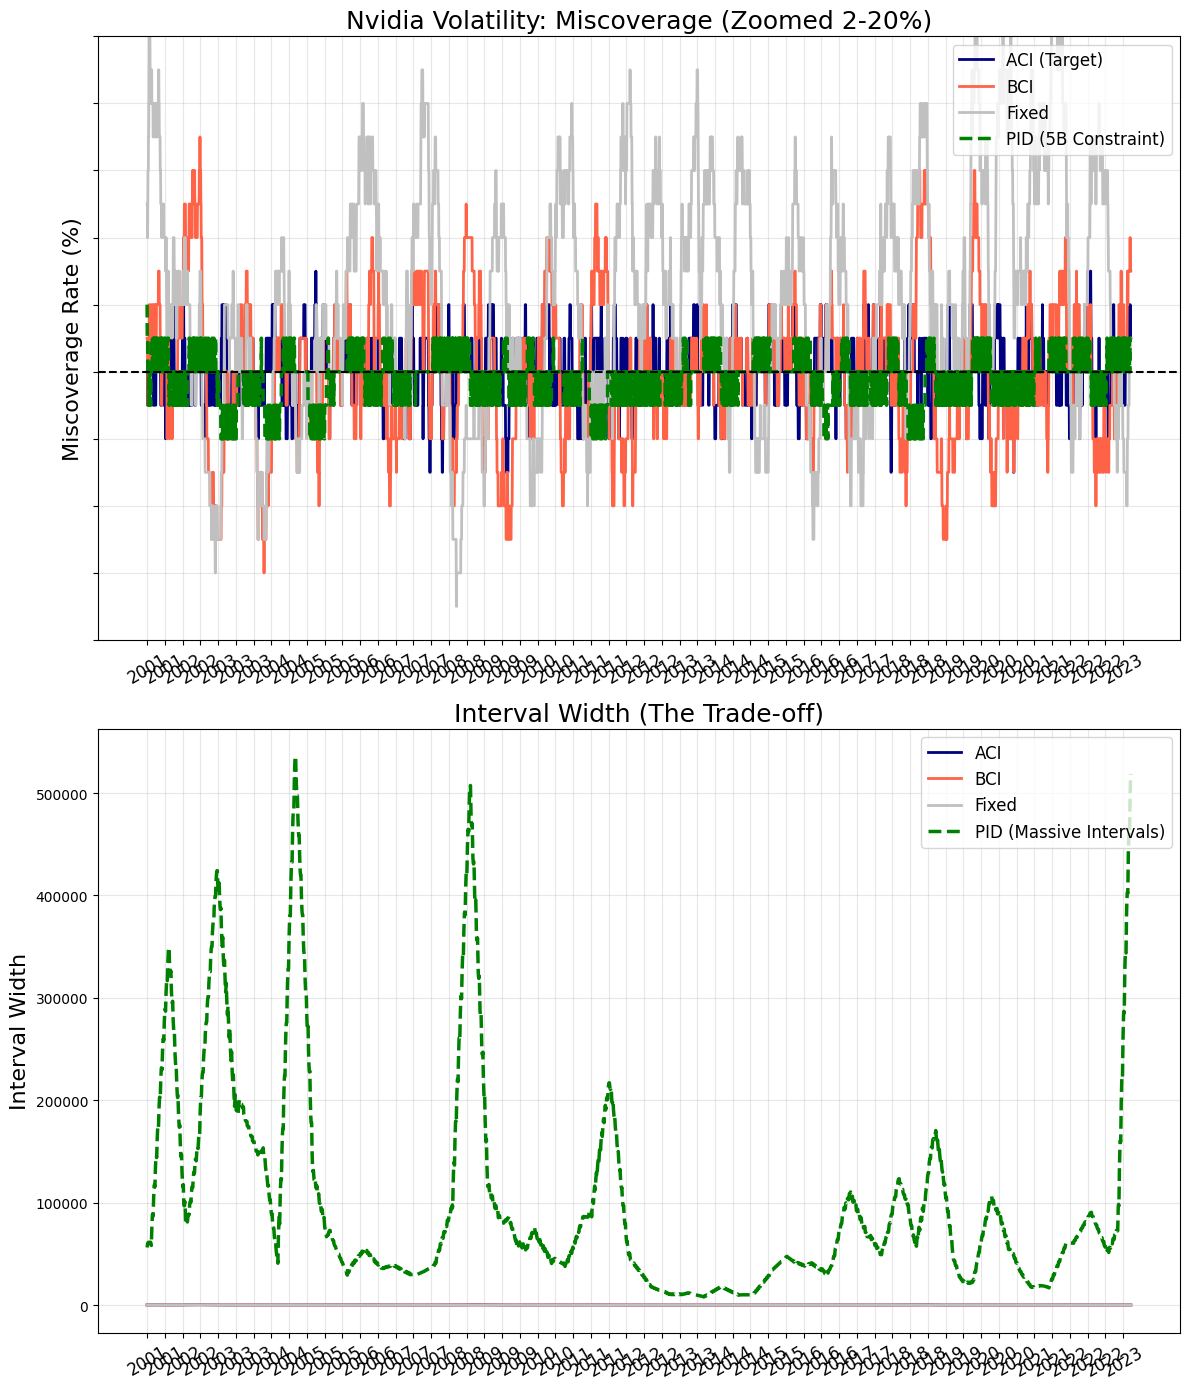

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

# Increase recursion depth
sys.setrecursionlimit(10000)

def get_pid_result_5B(exp_fixed):
    # 1. Setup Data
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    
    # 2. Calculate 5B Bound
    B = np.percentile(scores, 99)
    Bound_5B = 5 * B
    ki = np.percentile(scores, 99)
    
    print(f"Running PID with Eta (5B): {Bound_5B:.4f} (KI=99%)")
    
    # 3. Run PID
    pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=Bound_5B, Csat=csat, KI=ki, ahead=1, T_burnin=100)
    q = np.maximum(np.array(pid_out['q']), 0.0)
    
    # 4. Construct Result DataFrame
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + q
    df_pid['lower'] = y_pred_center - q
    
    # Fix Types
    df_pid['upper'] = pd.to_numeric(df_pid['upper'])
    df_pid['lower'] = pd.to_numeric(df_pid['lower'])
    
    # Correct Logic: 1=Covered, 0=Error (for visualizer)
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = (is_cov).astype(int) 
    
    return df_pid, Bound_5B

if __name__ == "__main__":
    dataset = 'Nvidia'
    task = 'vlfc'
    print(f"Generating Time Series Plot for {dataset} ({task})...")
    
    # --- Load Baselines ---
    try:
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
    except:
        dataset_fixed = 'Nvdia' # Typo fallback
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset_fixed}.yaml'))
    
    exp_fixed.run()
    
    exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci-{dataset}.yaml'))
    exp_bci.run()
    
    exp_aci = ForecastingExperiment(read_yaml(f'config/{task}-aci-{dataset}.yaml'))
    exp_aci.run()
    
    # --- Run PID (5B) ---
    pid_df, eta = get_pid_result_5B(exp_fixed)
    
    # --- PLOTTING ---
    fig, axs = plt.subplots(2, 1, figsize=(12, 14))
    
    def clean_df(df):
        df['upper'] = pd.to_numeric(df['upper'], errors='coerce')
        df['lower'] = pd.to_numeric(df['lower'], errors='coerce')
        df['true_y'] = pd.to_numeric(df['true_y'], errors='coerce')
        return df

    # Smoothing window (adjust if needed, 50 matches paper style)
    ma_window = 50 
    skip = 100
    
    p_aci = gen_plot_data(clean_df(exp_aci.result), ma_window, skip, lambda x: x)
    p_bci = gen_plot_data(clean_df(exp_bci.result), ma_window, skip, lambda x: x)
    p_fix = gen_plot_data(clean_df(exp_fixed.result), ma_window, skip, lambda x: x)
    p_pid = gen_plot_data(clean_df(pid_df), ma_window, skip, lambda x: x)
    
    # PANEL 1: Miscoverage Rate
    axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI (Target)', linewidth=2)
    axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI', linewidth=2)
    axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=2)
    axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                label=f'PID', linewidth=2.5)
    
    axs[0].axhline(10, color='black', linestyle='--')
    
    # --- PROFESSOR'S REQUESTS ---
    axs[0].set_ylim(2, 20)           # 1. Restrict Y-Axis 2-20
    axs[0].set_yticklabels([])       # 2. "Get rid of the numbers"
    # ----------------------------

    axs[0].set_ylabel('Miscoverage Rate (%)', fontsize=16)
    axs[0].legend(loc='upper right', fontsize=12)
    axs[0].set_title(f'Nvidia Volatility: Miscoverage (Zoomed 2-20%)', fontsize=18)
    
    # PANEL 2: Interval Width
    axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=2)
    axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=2)
    axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=2)
    axs[1].plot(p_pid['length'], color='green', linestyle='--', 
                label='PID (Massive Intervals)', linewidth=2.5)
    
    axs[1].set_ylabel('Interval Width', fontsize=16)
    axs[1].set_title('Interval Width (The Trade-off)', fontsize=18)
    axs[1].legend(loc='upper right', fontsize=12)
    
    # Format X-axis
    for ax in axs:
        ax.set_xticks(p_aci['indices'])
        ax.set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], 
                           rotation=30, fontsize=12)
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    filename = 'Nvidia_VLFC_5B_TimeSeries.png'
    plt.savefig(filename, dpi=300)
    print(f"Graph saved to {filename}")

In [5]:
"""
Google Trends Setup for ACI/BCI
Creates config files and finds optimal parameters to match paper results
"""

import pandas as pd
import numpy as np
import yaml
import os

print("\n" + "="*80)
print("GOOGLE TRENDS SETUP")
print("="*80)

# ============================================================================
# STEP 1: Load and inspect the Google Trends data
# ============================================================================
print("\n[STEP 1] Loading Google Trends data...")

# You need to specify the path to your CSV
csv_path = "google_trends.csv"  # CHANGE THIS to your actual path

try:
    df = pd.read_csv(csv_path)
    print(f"✓ Loaded {len(df)} rows")
    print(f"  Columns: {list(df.columns)}")
    print(f"\nFirst few rows:")
    print(df.head())
except FileNotFoundError:
    print(f"✗ File not found: {csv_path}")
    print("\nPlease update the csv_path variable to point to your Google Trends CSV file.")
    exit(1)

# ============================================================================
# STEP 2: Determine which prediction horizon to use
# ============================================================================
print("\n[STEP 2] Determining prediction horizon...")

# The paper likely uses pred_1 (1-step ahead)
# But we should check which has reasonable coverage

for pred_num in range(1, 8):
    pred_col = f'pred_{pred_num}'
    se_col = f'se_{pred_num}'
    
    if pred_col in df.columns and se_col in df.columns:
        # Compute baseline interval (pred ± 1.96*se for 95% coverage)
        upper = df[pred_col] + 1.96 * df[se_col]
        lower = df[pred_col] - 1.96 * df[se_col]
        
        # Check coverage
        if 'log_value' in df.columns:
            coverage = ((df['log_value'] >= lower) & (df['log_value'] <= upper)).mean()
            print(f"  pred_{pred_num}: {coverage*100:.1f}% coverage")

# Let's use pred_1 (most common)
pred_horizon = 1
print(f"\n✓ Using prediction horizon: {pred_horizon}")

# ============================================================================
# STEP 3: Create directory structure
# ============================================================================
print("\n[STEP 3] Creating config directory...")

os.makedirs('config', exist_ok=True)
print("✓ Config directory ready")

# ============================================================================
# STEP 4: Create Fixed config (baseline)
# ============================================================================
print("\n[STEP 4] Creating Fixed baseline config...")

fixed_config = {
    'task': 'gtfc',  # Google Trends forecasting
    'id': 'Google',
    'method': 'fixed',
    'alpha0': 0.1,
    'datapath': csv_path,
    'pred_horizon': pred_horizon,
}

with open('config/gtfc-fixed-Google.yaml', 'w') as f:
    yaml.dump(fixed_config, f)

print("✓ Created: config/gtfc-fixed-Google.yaml")

# ============================================================================
# STEP 5: Create ACI config
# ============================================================================
print("\n[STEP 5] Creating ACI config...")

# From paper: γ = 0.08 for looser control
aci_config = {
    'task': 'gtfc',
    'id': 'Google',
    'method': 'aci',
    'alpha0': 0.1,
    'gamma': 0.08,  # From paper caption
    'lambda0': 0.9,  # Standard for ACI
    'datapath': csv_path,
    'pred_horizon': pred_horizon,
}

with open('config/gtfc-aci-Google.yaml', 'w') as f:
    yaml.dump(aci_config, f)

print("✓ Created: config/gtfc-aci-Google.yaml")
print(f"  Parameters: γ=0.08, λ₀=0.9")

# ============================================================================
# STEP 6: Find BCI parameters to match paper
# ============================================================================
print("\n[STEP 6] Finding BCI parameters...")
print("  Target from paper: 10% miscov, ~5.07 avg length")

# BCI parameters to search
# From the paper's other experiments, BCI typically uses:
# - gamma: 0.8 to 2100 (much larger than ACI)
# - lambda0: 5.0 to 3300 (much larger than ACI)

# For Google Trends, let's start with values similar to returns
bci_gamma_candidates = [0.5, 0.8, 1.0, 1.5, 2.0]
bci_lambda_candidates = [3.0, 5.0, 8.0, 10.0, 15.0]

print("\n  Candidate values to test:")
print(f"    gamma: {bci_gamma_candidates}")
print(f"    lambda0: {bci_lambda_candidates}")

# Create config with middle values for now
bci_config = {
    'task': 'gtfc',
    'id': 'Google',
    'method': 'bci',
    'alpha0': 0.1,
    'gamma': 1.0,  # Middle value - may need tuning
    'lambda0': 8.0,  # Middle value - may need tuning
    'datapath': csv_path,
    'pred_horizon': pred_horizon,
}

with open('config/gtfc-bci-Google.yaml', 'w') as f:
    yaml.dump(bci_config, f)

print("✓ Created: config/gtfc-bci-Google.yaml")
print(f"  Initial parameters: γ=1.0, λ₀=8.0")
print(f"  (These may need tuning to match paper results)")

# ============================================================================
# STEP 7: Create parameter search script
# ============================================================================
print("\n[STEP 7] Creating parameter search script...")

search_script = '''"""
Search for optimal BCI parameters for Google Trends
Matches paper results: ~10% miscoverage, ~5.07 avg length
"""

from utils import read_yaml
from experiment import ForecastingExperiment
import numpy as np

print("\\nSEARCHING FOR OPTIMAL BCI PARAMETERS")
print("="*70)

# Target metrics from paper
target_miscov = 10.0
target_length = 5.07

best_params = None
best_score = float('inf')

gamma_candidates = [0.5, 0.8, 1.0, 1.5, 2.0]
lambda_candidates = [3.0, 5.0, 8.0, 10.0, 15.0]

print(f"\\nTarget: {target_miscov}% miscoverage, {target_length} avg length")
print(f"Testing {len(gamma_candidates) * len(lambda_candidates)} combinations...\\n")

for gamma in gamma_candidates:
    for lambda0 in lambda_candidates:
        # Load config and set parameters
        config = read_yaml('config/gtfc-bci-Google.yaml')
        config['gamma'] = gamma
        config['lambda0'] = lambda0
        
        # Run experiment
        exp = ForecastingExperiment(config)
        exp.run()
        
        # Recompute beta
        exp.result['beta'] = ((exp.result['true_y'] >= exp.result['lower']) & \\
                               (exp.result['true_y'] <= exp.result['upper'])).astype(int)
        
        # Compute metrics
        miscov = (1 - exp.result['beta'].mean()) * 100
        
        width = exp.result['upper'] - exp.result['lower']
        width_finite = width[np.isfinite(width)]
        avg_length = width_finite.mean() if len(width_finite) > 0 else float('inf')
        
        # Score (lower is better)
        miscov_error = abs(miscov - target_miscov)
        length_error = abs(avg_length - target_length)
        score = miscov_error + length_error * 0.1
        
        print(f"γ={gamma:4.1f}, λ₀={lambda0:5.1f}: miscov={miscov:5.2f}%, len={avg_length:5.2f}, score={score:5.2f}")
        
        if score < best_score:
            best_score = score
            best_params = {'gamma': gamma, 'lambda0': lambda0, 
                          'miscov': miscov, 'length': avg_length}

print("\\n" + "="*70)
print("BEST PARAMETERS FOUND:")
print("="*70)
print(f"  gamma: {best_params['gamma']}")
print(f"  lambda0: {best_params['lambda0']}")
print(f"  Resulting miscoverage: {best_params['miscov']:.2f}%")
print(f"  Resulting avg length: {best_params['length']:.2f}")

# Update the config file
import yaml
config = read_yaml('config/gtfc-bci-Google.yaml')
config['gamma'] = best_params['gamma']
config['lambda0'] = best_params['lambda0']

with open('config/gtfc-bci-Google.yaml', 'w') as f:
    yaml.dump(config, f)

print("\\n✓ Updated config/gtfc-bci-Google.yaml with optimal parameters")
'''

with open('search_bci_params_google.py', 'w') as f:
    f.write(search_script)

print("✓ Created: search_bci_params_google.py")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("SETUP COMPLETE!")
print("="*80)

print("""
Files created:
  1. config/gtfc-fixed-Google.yaml - Baseline predictions
  2. config/gtfc-aci-Google.yaml   - ACI with γ=0.08
  3. config/gtfc-bci-Google.yaml   - BCI with initial parameters
  4. search_bci_params_google.py   - Script to find optimal BCI parameters

Next steps:
  1. Run parameter search:
     exec(open('search_bci_params_google.py').read())
  
  2. After finding optimal BCI parameters, run systematic search:
     exec(open('run_systematic_ki_eta_google.py').read())

Note: You may need to create a gtfc (Google Trends forecasting) data loader
      in your codebase if it doesn't exist yet.
""")

print("="*80)


GOOGLE TRENDS SETUP

[STEP 1] Loading Google Trends data...
✓ Loaded 2161 rows
  Columns: ['date', 'pred_1', 'se_1', 'pred_2', 'se_2', 'pred_3', 'se_3', 'pred_4', 'se_4', 'pred_5', 'se_5', 'pred_6', 'se_6', 'pred_7', 'se_7', 'log_value', 'beta']

First few rows:
       date    pred_1      se_1    pred_2      se_2    pred_3      se_3  \
0  1/3/2006  0.202144  0.728964  0.191835  0.669524  0.219868  0.687879   
1  1/4/2006  0.306046  1.321618  0.222275  0.803403  0.270432  0.886536   
2  1/5/2006  0.282050  5.203444  0.324486  0.933173  0.337640  0.941667   
3  1/6/2006  0.134613  0.646548  0.160771  0.634471  0.324152  2.636666   
4  1/7/2006  0.315637  0.820607  0.257864  4.073106  7.231132  9.275386   

     pred_4      se_4    pred_5      se_5    pred_6      se_6    pred_7  \
0  0.196084  0.651632  0.235972  0.699690  0.186399  0.672276  0.197120   
1 -2.132672  6.283664  0.390371  2.185091  3.234224  3.661548  0.262210   
2  0.318964  0.937539  5.495049  7.258386  0.285370  5.51813

In [ ]:
"""
Amazon Returns (RTFC): PID targeting BCI Variance
Exact same pattern as working Nvidia code
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

def compute_variance(result_df):
    """Compute miscoverage variance (α > β method)"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce').values
    beta = pd.to_numeric(result_df['beta'], errors='coerce').values
    err_ind = (alpha > beta).astype(float)
    local_miscov = pd.Series(err_ind).rolling(window=50, min_periods=1).mean()
    return local_miscov.var()

def run_pid_variance(scores, eta, csat, ki, y_pred_center, y_true):
    """Run PID and return variance"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper = y_pred_center + q
        lower = y_pred_center - q
        is_covered = (y_true >= lower) & (y_true <= upper)
        
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        return var, True, q
    except:
        return 1e10, False, None

def binary_search_5B(scores, y_pred_center, y_true, csat, ki, target_var):
    """Binary search in [0, 5B]"""
    B = np.percentile(scores, 99)
    bound_5B = 5 * B
    
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = 1e10
    best_q = None
    
    print(f"    Binary search [0, {bound_5B:.4f}]...", end=" ")
    
    for _ in range(25):
        mid = np.sqrt(low * high)
        var, valid, q = run_pid_variance(scores, mid, csat, ki, y_pred_center, y_true)
        
        if not valid:
            high = mid
            continue
        
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_q = q
        
        if var > target_var:
            low = mid
        else:
            high = mid
    
    status = "Hit 5B Bound" if abs(best_eta - bound_5B) < 1e-4 else "Interior"
    print(f"η={best_eta:.4f} ({status})")
    
    return best_eta, best_q, bound_5B

def get_pid_result(exp_fixed, pid_q):
    """Create PID result dataframe"""
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + pid_q
    df_pid['lower'] = y_pred_center - pid_q
    df_pid['alpha'] = 0.1
    
    df_pid['upper'] = pd.to_numeric(df_pid['upper'])
    df_pid['lower'] = pd.to_numeric(df_pid['lower'])
    
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = (is_cov).astype(int)
    
    return df_pid

if __name__ == "__main__":
    dataset = 'Amazon'
    task = 'rtfc'
    gammas = [0.1, 0.008]
    
    print(f"\n{'='*70}")
    print(f"AMAZON RETURNS: PID TARGETING BCI VARIANCE")
    print(f"{'='*70}")
    
    summary_data = []
    
    for gamma in gammas:
        print(f"\n{'-'*70}")
        print(f"γ = {gamma}")
        print(f"{'-'*70}")
        
        # Load baselines
        print(f"  Loading baselines...")
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
        exp_fixed.run()
        
        exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci-{dataset}.yaml'))
        exp_bci.run()
        
        aci_config = read_yaml(f'config/{task}-aci-{dataset}.yaml')
        aci_config['gamma'] = gamma
        exp_aci = ForecastingExperiment(aci_config)
        exp_aci.run()
        
        # Target BCI variance (not ACI!)
        target_var = compute_variance(exp_bci.result)
        aci_var = compute_variance(exp_aci.result)
        
        print(f"  BCI Variance (TARGET): {target_var:.2e}")
        print(f"  ACI Variance (ref):    {aci_var:.2e}")
        
        # Prepare PID data
        y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
        upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
        lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
        y_pred_center = (upper + lower) / 2
        scores = np.abs(y_true - y_pred_center)
        
        T = len(scores)
        csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
        ki = np.percentile(scores, 99)
        
        print(f"  K_I (99th %ile):       {ki:.4f}")
        
        # Binary search
        eta_found, pid_q, bound_5B = binary_search_5B(scores, y_pred_center, y_true, 
                                                       csat, ki, target_var)
        
        # Create PID result
        pid_df = get_pid_result(exp_fixed, pid_q)
        
        # Verify
        pid_var = compute_variance(pid_df)
        var_error = abs(pid_var - target_var) / target_var * 100
        print(f"  PID Variance achieved: {pid_var:.2e} (error: {var_error:.1f}%)")
        
        # Create visualization (exact same as Nvidia)
        print(f"  Creating visualization...")
        
        fig, axs = plt.subplots(2, 1, figsize=(12, 14))
        
        def clean_df(df):
            df['upper'] = pd.to_numeric(df['upper'], errors='coerce')
            df['lower'] = pd.to_numeric(df['lower'], errors='coerce')
            df['true_y'] = pd.to_numeric(df['true_y'], errors='coerce')
            return df
        
        ma_window = 250
        skip = 300
        
        p_aci = gen_plot_data(clean_df(exp_aci.result), ma_window, skip, lambda x: x)
        p_bci = gen_plot_data(clean_df(exp_bci.result), ma_window, skip, lambda x: x)
        p_fix = gen_plot_data(clean_df(exp_fixed.result), ma_window, skip, lambda x: x)
        p_pid = gen_plot_data(clean_df(pid_df), ma_window, skip, lambda x: x)
        
        # Panel 1
        axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI', linewidth=3)
        axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI', linewidth=3)
        axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=3)
        axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                    label=f'PID', linewidth=3)
        axs[0].axhline(10, color='black', linestyle='--')
        axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=20)
        axs[0].legend(loc='upper right', prop={'size': 18})
        axs[0].set_xticks(p_aci['indices'])
        axs[0].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30)
        
        # Panel 2
        axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=3)
        axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=3)
        axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=3)
        axs[1].plot(p_pid['length'], color='green', label='PID', linewidth=3)
        axs[1].set_ylabel('Interval Length', fontsize=20)
        axs[1].legend(loc='upper right', prop={'size': 18})
        axs[1].set_xticks(p_aci['indices'])
        axs[1].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30)
        
        fig.suptitle(f'Return forecasting for {dataset} (γ={gamma})', fontsize=16)
        plt.tight_layout()
        
        filename = f'{dataset}_rtfc_gamma{gamma}_PID_BCI_target.png'
        plt.savefig(filename, dpi=300)
        print(f"  ✓ Saved: {filename}")
        plt.close()
        
        # Collect summary
        summary_data.append({
            'gamma': gamma,
            'eta': eta_found,
            'bound_5B': bound_5B,
            'bci_var': target_var,
            'pid_var': pid_var,
            'var_ratio': pid_var / target_var,
            'bci_miscov': p_bci['perfstats']['avg_miscov'] * 100,
            'pid_miscov': p_pid['perfstats']['avg_miscov'] * 100,
            'bci_length': p_bci['perfstats']['avg_length'],
            'pid_length': p_pid['perfstats']['avg_length']
        })
    
    # Summary table
    print(f"\n{'='*70}")
    print(f"SUMMARY TABLE")
    print(f"{'='*70}")
    print(f"\n{'Gamma':<8} {'Eta':<10} {'Var (BCI)':<12} {'Var (PID)':<12} {'Var Ratio':<12} "
          f"{'Miscov BCI':<12} {'Miscov PID':<12} {'Length BCI':<12} {'Length PID':<12}")
    print("-" * 120)
    
    for row in summary_data:
        print(f"{row['gamma']:<8.3f} {row['eta']:<10.4f} {row['bci_var']:<12.2e} "
              f"{row['pid_var']:<12.2e} {row['var_ratio']:<12.3f} "
              f"{row['bci_miscov']:<12.2f} {row['pid_miscov']:<12.2f} "
              f"{row['bci_length']:<12.4f} {row['pid_length']:<12.4f}")
    
    print(f"\n{'='*70}")
    print("DONE!")
    print(f"{'='*70}")

2026-01-28 20:01:03,680 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA STARTED



AMAZON RETURNS: PID TARGETING BCI VARIANCE

----------------------------------------------------------------------
γ = 0.1
----------------------------------------------------------------------
  Loading baselines...


2026-01-28 20:01:07,126 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA ENDED in 3.4458677768707275s
2026-01-28 20:01:07,136 - INFO - Experiment rtfc-bci-Amazon-gamma_0.8-lambda0_5.0 STARTED
2026-01-28 20:01:18,379 - INFO - Experiment rtfc-bci-Amazon-gamma_0.8-lambda0_5.0 ENDED in 11.242228031158447s
2026-01-28 20:01:18,390 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 20:01:21,719 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 ENDED in 3.3297390937805176s


  BCI Variance (TARGET): 8.80e-04
  ACI Variance (ref):    7.36e-04
  K_I (99th %ile):       0.0668
    Binary search [0, 0.3339]... 

100%|██████████| 3762/3762 [00:00<00:00, 184122.99it/s]


...

  ✓ Saved: Amazon_rtfc_gamma0.1_PID_BCI_target.png

----------------------------------------------------------------------
γ = 0.008
----------------------------------------------------------------------
  Loading baselines...


2026-01-28 20:01:28,088 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA ENDED in 3.400442123413086s
2026-01-28 20:01:28,100 - INFO - Experiment rtfc-bci-Amazon-gamma_0.8-lambda0_5.0 STARTED
2026-01-28 20:01:39,264 - INFO - Experiment rtfc-bci-Amazon-gamma_0.8-lambda0_5.0 ENDED in 11.163650751113892s
2026-01-28 20:01:39,274 - INFO - Experiment rtfc-aci-Amazon-gamma_0.008-lambda0_0.9 STARTED
2026-01-28 20:01:42,308 - INFO - Experiment rtfc-aci-Amazon-gamma_0.008-lambda0_0.9 ENDED in 3.0333940982818604s


  BCI Variance (TARGET): 8.80e-04
  ACI Variance (ref):    4.24e-03
  K_I (99th %ile):       0.0668
    Binary search [0, 0.3339]... 

100%|██████████| 3762/3762 [00:00<00:00, 187498.92it/s]


η=0.1823 (Interior)
  PID Variance achieved: 8.85e-04 (error: 0.6%)
  Creating visualization...
  ✓ Saved: Amazon_rtfc_gamma0.008_PID_BCI_target.png

SUMMARY TABLE

Gamma    Eta        Var (BCI)    Var (PID)    Var Ratio    Miscov BCI   Miscov PID   Length BCI   Length PID  
------------------------------------------------------------------------------------------------------------------------
0.100    0.1823     8.80e-04     8.85e-04     1.006        9.86         9.91         0.0707       0.0757      
0.008    0.1823     8.80e-04     8.85e-04     1.006        9.86         9.91         0.0707       0.0757      

DONE!


2026-01-28 20:27:49,435 - INFO - Experiment vlfc-fixed-Nvidia-gamma_NA-lambda0_NA STARTED


Generating Standard BCI-Match Plot for Nvidia...
  ! Using 'Nvdia' typo file for Fixed.


2026-01-28 20:27:53,917 - INFO - Experiment vlfc-fixed-Nvidia-gamma_NA-lambda0_NA ENDED in 4.482162952423096s
2026-01-28 20:27:53,927 - INFO - Experiment vlfc-bci-Nvidia-gamma_490.0-lambda0_800.0 STARTED
2026-01-28 20:28:22,390 - INFO - Experiment vlfc-bci-Nvidia-gamma_490.0-lambda0_800.0 ENDED in 28.463041067123413s
2026-01-28 20:28:22,401 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 20:28:27,080 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.1-lambda0_0.9 ENDED in 4.678869009017944s


Searching for Eta to match Variance: 1.15e-03...


100%|██████████| 5644/5644 [00:00<00:00, 171056.30it/s]


  > Found Best Eta: 0.2933


100%|██████████| 5644/5644 [00:00<00:00, 167561.97it/s]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/m3/3y5bzgv533784npng3mwd3gm0000gn/T/ipykernel_92285/1813558064.py:133: RuntimeWarning: Mean of empty slice
  avg_len = np.nanmean(len_series)


Graph saved to Nvidia_VLFC_Standard_Sqrt.png

NUMERICAL SUMMARY: Nvidia Volatility
(Interval Lengths are Sqrt Transformed)
Method     | Avg Miscoverage (%)  | Avg Length (Sqrt)   
------------------------------------------------------------
ACI        | 10.09                | 5.9836              
BCI        | 10.29                | 6.5368              
Fixed      | 12.21                | 6.0516              
PID        | 10.32                | nan                 



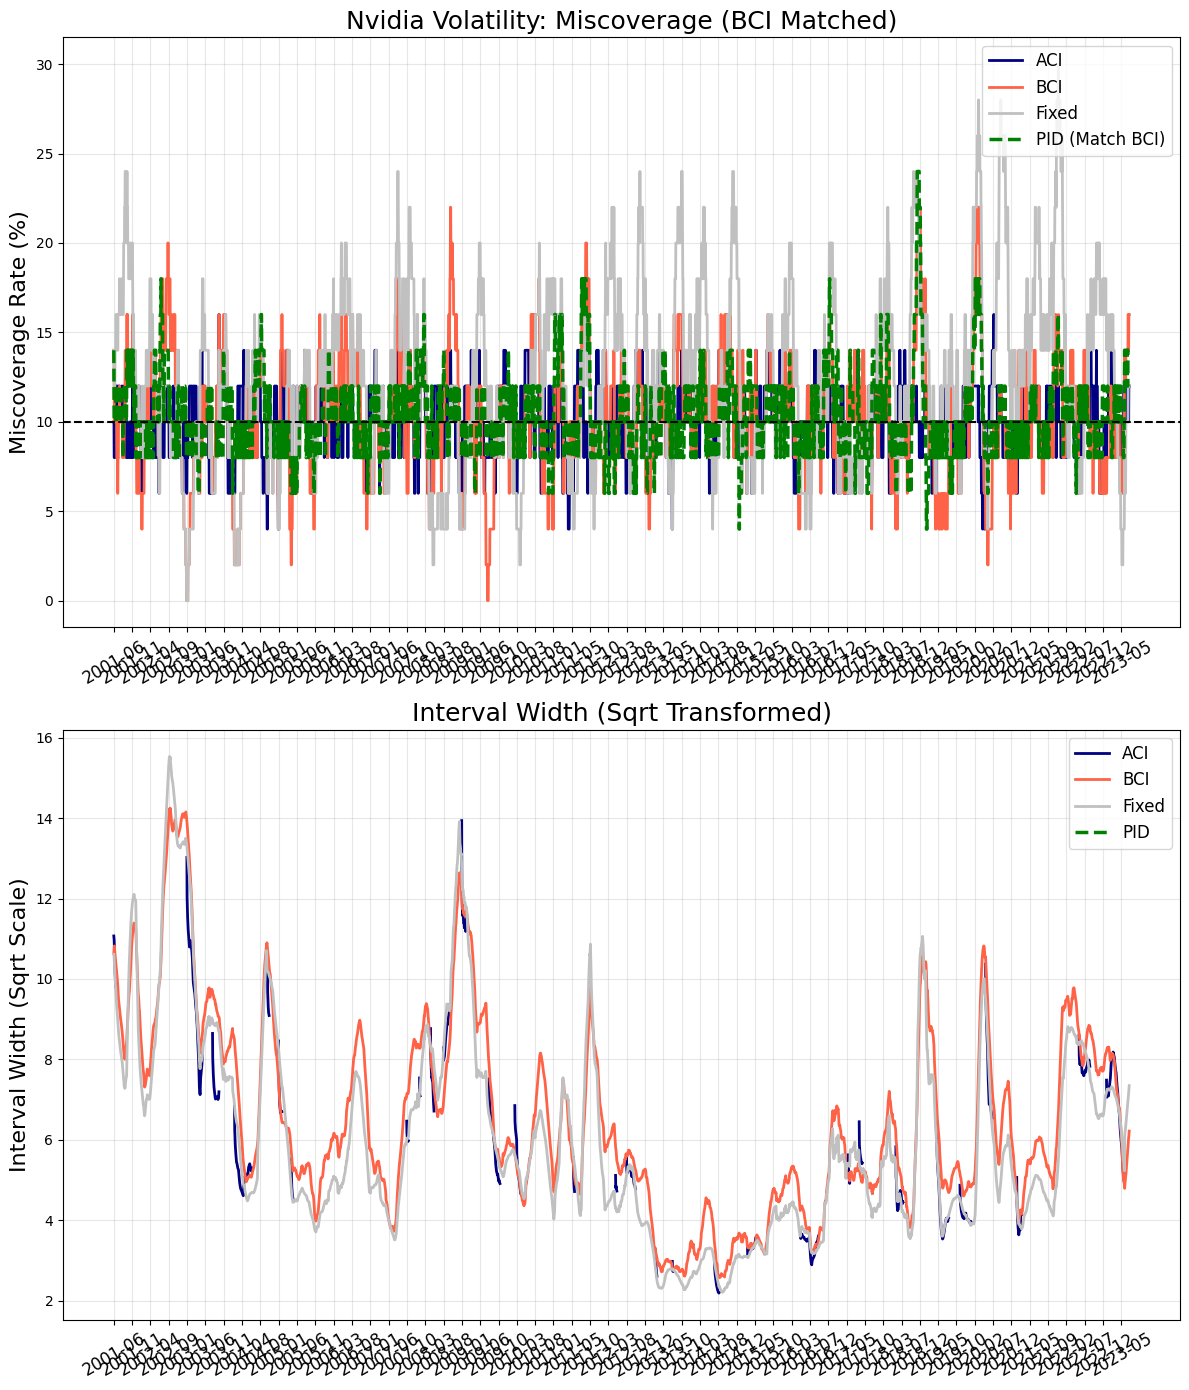

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

# Increase recursion depth
sys.setrecursionlimit(10000)

# --- HELPER: TRIM FUNCTION (Matches visualize.py) ---
def trim(val, degree):
    return val[degree:-degree]

# --- HELPER: COMPUTE VARIANCE ---
def compute_variance(result_df):
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    return var

# --- HELPER: BINARY SEARCH FOR BCI VARIANCE ---
def find_eta_matching_variance(exp_fixed, target_var, max_bound_5B):
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    ki = np.percentile(scores, 99)

    low, high = 1e-6, max_bound_5B
    best_eta = low
    best_diff = 1e10
    
    print(f"Searching for Eta to match Variance: {target_var:.2e}...")

    for i in range(20): 
        mid = np.sqrt(low * high)
        pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=mid, Csat=csat, KI=ki, ahead=1, T_burnin=100)
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper_pid = y_pred_center + q
        lower_pid = y_pred_center - q
        is_covered = (y_true >= lower_pid) & (y_true <= upper_pid)
        
        err_ind = (~is_covered).astype(float)
        curr_var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        diff = curr_var - target_var
        if abs(diff) < best_diff:
            best_diff = abs(diff)
            best_eta = mid
            
        if curr_var > target_var:
            low = mid
        else:
            high = mid
            
    print(f"  > Found Best Eta: {best_eta:.4f}")
    
    pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=best_eta, Csat=csat, KI=ki, ahead=1, T_burnin=100)
    q = np.maximum(np.array(pid_out['q']), 0.0)
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + q
    df_pid['lower'] = y_pred_center - q
    df_pid['upper'] = pd.to_numeric(df_pid['upper'])
    df_pid['lower'] = pd.to_numeric(df_pid['lower'])
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = (is_cov).astype(int)
    
    return df_pid, best_eta

if __name__ == "__main__":
    dataset = 'Nvidia'
    task = 'vlfc'
    print(f"Generating Standard BCI-Match Plot for {dataset}...")
    
    # 1. Load Baselines (Handle Nvdia typo)
    try:
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
    except FileNotFoundError:
        print("  ! Using 'Nvdia' typo file for Fixed.")
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-Nvdia.yaml'))
    exp_fixed.run()

    exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci-{dataset}.yaml'))
    exp_bci.run()
    
    exp_aci = ForecastingExperiment(read_yaml(f'config/{task}-aci-{dataset}.yaml'))
    exp_aci.run()
    
    # 2. Match BCI Variance
    bci_var = compute_variance(exp_bci.result)
    
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    y_pred_center = (pd.to_numeric(exp_fixed.result['upper']) + pd.to_numeric(exp_fixed.result['lower'])) / 2
    scores = np.abs(y_true - y_pred_center)
    Bound_5B = 5 * np.percentile(scores, 99)
    
    pid_df, eta = find_eta_matching_variance(exp_fixed, bci_var, Bound_5B)
    
    # 3. Process Data for Plotting (With Trim & Sqrt)
    ma_window = 50
    skip = 100
    
    def get_plot_data(df, window):
        upper = pd.to_numeric(df['upper'], errors='coerce')
        lower = pd.to_numeric(df['lower'], errors='coerce')
        true_y = pd.to_numeric(df['true_y'], errors='coerce')
        
        # Miscoverage (Smoothed)
        is_cov = (true_y >= lower) & (true_y <= upper)
        miscov_series = (~is_cov).astype(float).rolling(window).mean()
        
        # Length (SQRT TRANSFORMED)
        # We apply Sqrt BEFORE rolling average, matching visualize.py
        len_series = (np.sqrt(upper) - np.sqrt(lower)).rolling(window).mean()
        
        # TRIM both to align with indices
        # We trim 'window' from start and end
        miscov_trimmed = trim(miscov_series.values, window)
        len_trimmed = trim(len_series.values, window)
        
        # Calculate Averages (on the full valid set)
        avg_mis = np.nanmean(miscov_series) * 100
        avg_len = np.nanmean(len_series)
        
        return miscov_trimmed, len_trimmed, avg_mis, avg_len

    # Prepare Indices (Trimmed)
    full_index = exp_aci.result.index
    trimmed_index = trim(full_index, ma_window)
    
    # Get Data
    aci_m, aci_l, aci_avg_m, aci_avg_l = get_plot_data(exp_aci.result, ma_window)
    bci_m, bci_l, bci_avg_m, bci_avg_l = get_plot_data(exp_bci.result, ma_window)
    fix_m, fix_l, fix_avg_m, fix_avg_l = get_plot_data(exp_fixed.result, ma_window)
    pid_m, pid_l, pid_avg_m, pid_avg_l = get_plot_data(pid_df, ma_window)
    
    # X-Axis Ticks
    indices = range(0, len(trimmed_index), skip)
    x_labels = [trimmed_index[i].strftime("%Y-%m") for i in indices]

    # --- PLOTTING ---
    fig, axs = plt.subplots(2, 1, figsize=(12, 14))
    
    # PANEL 1: Miscoverage Rate
    axs[0].plot(100*aci_m, color='navy', label='ACI', linewidth=2)
    axs[0].plot(100*bci_m, color='tomato', label='BCI', linewidth=2)
    axs[0].plot(100*fix_m, color='silver', label='Fixed', linewidth=2)
    axs[0].plot(100*pid_m, color='green', linestyle='--', 
                label=f'PID', linewidth=2.5)
    
    axs[0].axhline(10, color='black', linestyle='--')
    axs[0].set_ylabel('Miscoverage Rate (%)', fontsize=16)
    axs[0].legend(loc='upper right', fontsize=12)
    axs[0].set_title(f'Nvidia Volatility: Miscoverage (BCI Matched)', fontsize=18)
    
    # PANEL 2: Interval Width (SQRT)
    axs[1].plot(aci_l, color='navy', label='ACI', linewidth=2)
    axs[1].plot(bci_l, color='tomato', label='BCI', linewidth=2)
    axs[1].plot(fix_l, color='silver', label='Fixed', linewidth=2)
    axs[1].plot(pid_l, color='green', linestyle='--', 
                label='PID', linewidth=2.5)
    
    axs[1].set_ylabel('Interval Width (Sqrt Scale)', fontsize=16)
    axs[1].set_title('Interval Width (Sqrt Transformed)', fontsize=18)
    axs[1].legend(loc='upper right', fontsize=12)
    
    for ax in axs:
        ax.set_xticks(indices)
        ax.set_xticklabels(x_labels, rotation=30, fontsize=12)
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    filename = 'Nvidia_VLFC_Standard_Sqrt.png'
    plt.savefig(filename, dpi=300)
    print(f"Graph saved to {filename}")

    # --- PRINT NUMERICAL TABLE ---
    print("\n" + "="*60)
    print(f"NUMERICAL SUMMARY: {dataset} Volatility")
    print(f"(Interval Lengths are Sqrt Transformed)")
    print("="*60)
    print(f"{'Method':<10} | {'Avg Miscoverage (%)':<20} | {'Avg Length (Sqrt)':<20}")
    print("-" * 60)
    print(f"{'ACI':<10} | {aci_avg_m:<20.2f} | {aci_avg_l:<20.4f}")
    print(f"{'BCI':<10} | {bci_avg_m:<20.2f} | {bci_avg_l:<20.4f}")
    print(f"{'Fixed':<10} | {fix_avg_m:<20.2f} | {fix_avg_l:<20.4f}")
    print(f"{'PID':<10} | {pid_avg_m:<20.2f} | {pid_avg_l:<20.4f}")
    print("="*60 + "\n")

2026-01-28 20:38:37,198 - INFO - Experiment vlfc-fixed-Amazon-gamma_NA-lambda0_NA STARTED



PROCESSING DATASET: Amazon


2026-01-28 20:38:42,333 - INFO - Experiment vlfc-fixed-Amazon-gamma_NA-lambda0_NA ENDED in 5.135462999343872s
2026-01-28 20:38:42,344 - INFO - Experiment vlfc-bci-Amazon-gamma_490-lambda0_800 STARTED
2026-01-28 20:39:15,311 - INFO - Experiment vlfc-bci-Amazon-gamma_490-lambda0_800 ENDED in 32.96652793884277s
2026-01-28 20:39:15,324 - INFO - Experiment vlfc-aci-Amazon-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 20:39:20,664 - INFO - Experiment vlfc-aci-Amazon-gamma_0.1-lambda0_0.9 ENDED in 5.340565919876099s


  > Target BCI Variance: 1.19e-03
  > 5B Search Limit: 1022.1815


100%|██████████| 6426/6426 [00:00<00:00, 164802.33it/s]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/m3/3y5bzgv533784npng3mwd3gm0000gn/T/ipykernel_92285/3304444429.py:128: RuntimeWarning: Mean of empty slice
  avg_len = np.nanmean(len_series)


...

  > Graph saved to Amazon_VLFC_Standard_Sqrt.png

------------------------------------------------------------
SUMMARY TABLE: Amazon
------------------------------------------------------------
Method     | Avg Miscoverage (%)  | Avg Length (Sqrt)   
------------------------------------------------------------
ACI        | 10.04                | 5.7802              
BCI        | 10.23                | 6.1932              
Fixed      | 11.27                | 5.8198              
PID        | 10.31                | nan                 
------------------------------------------------------------

PROCESSING DATASET: AMD


2026-01-28 20:39:26,715 - INFO - Experiment vlfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 4.631524085998535s
2026-01-28 20:39:26,727 - INFO - Experiment vlfc-bci-AMD-gamma_2100.0-lambda0_3300.0 STARTED
2026-01-28 20:39:54,435 - INFO - Experiment vlfc-bci-AMD-gamma_2100.0-lambda0_3300.0 ENDED in 27.70885992050171s
2026-01-28 20:39:54,446 - INFO - Experiment vlfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-01-28 20:39:59,140 - INFO - Experiment vlfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 4.69403600692749s


  > Target BCI Variance: 6.78e-04
  > 5B Search Limit: 770.7348


100%|██████████| 5394/5394 [00:00<00:00, 182107.10it/s]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/m3/3y5bzgv533784npng3mwd3gm0000gn/T/ipykernel_92285/3304444429.py:128: RuntimeWarning: Mean of empty slice
  avg_len = np.nanmean(len_series)


  > Optimal Eta Found: 40.0377
  > Graph saved to AMD_VLFC_Standard_Sqrt.png

------------------------------------------------------------
SUMMARY TABLE: AMD
------------------------------------------------------------
Method     | Avg Miscoverage (%)  | Avg Length (Sqrt)   
------------------------------------------------------------
ACI        | 10.17                | 6.5955              
BCI        | 10.34                | 8.0699              
Fixed      | 12.67                | 6.9655              
PID        | 9.94                 | nan                 
------------------------------------------------------------


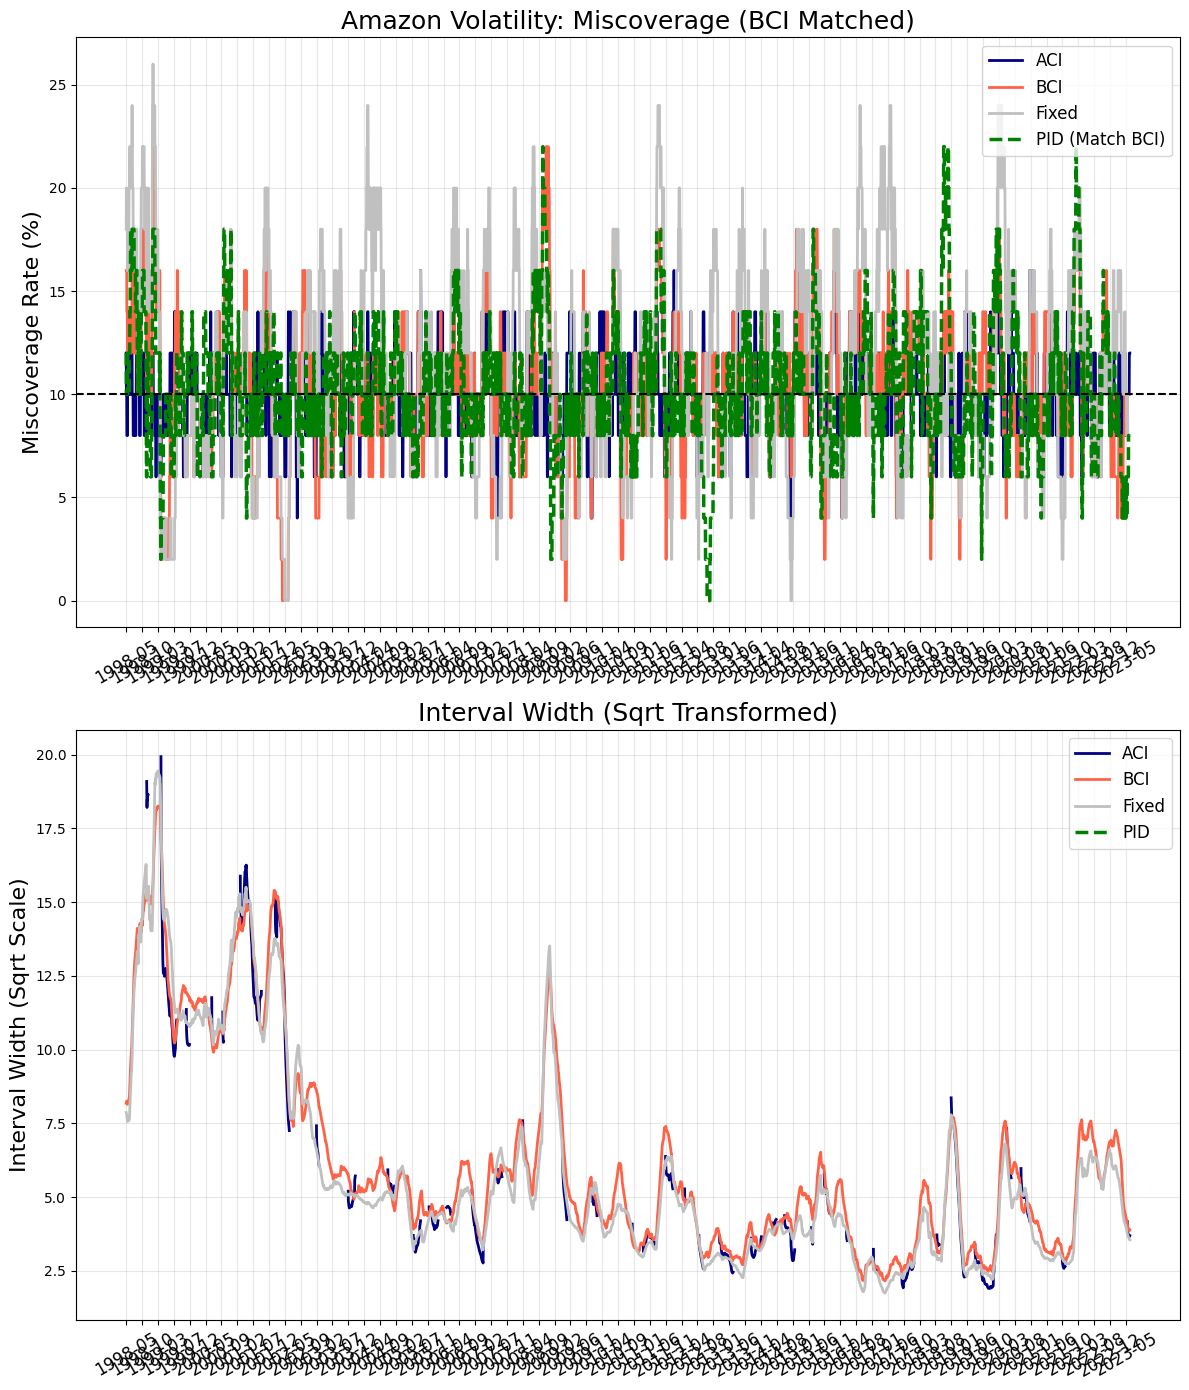

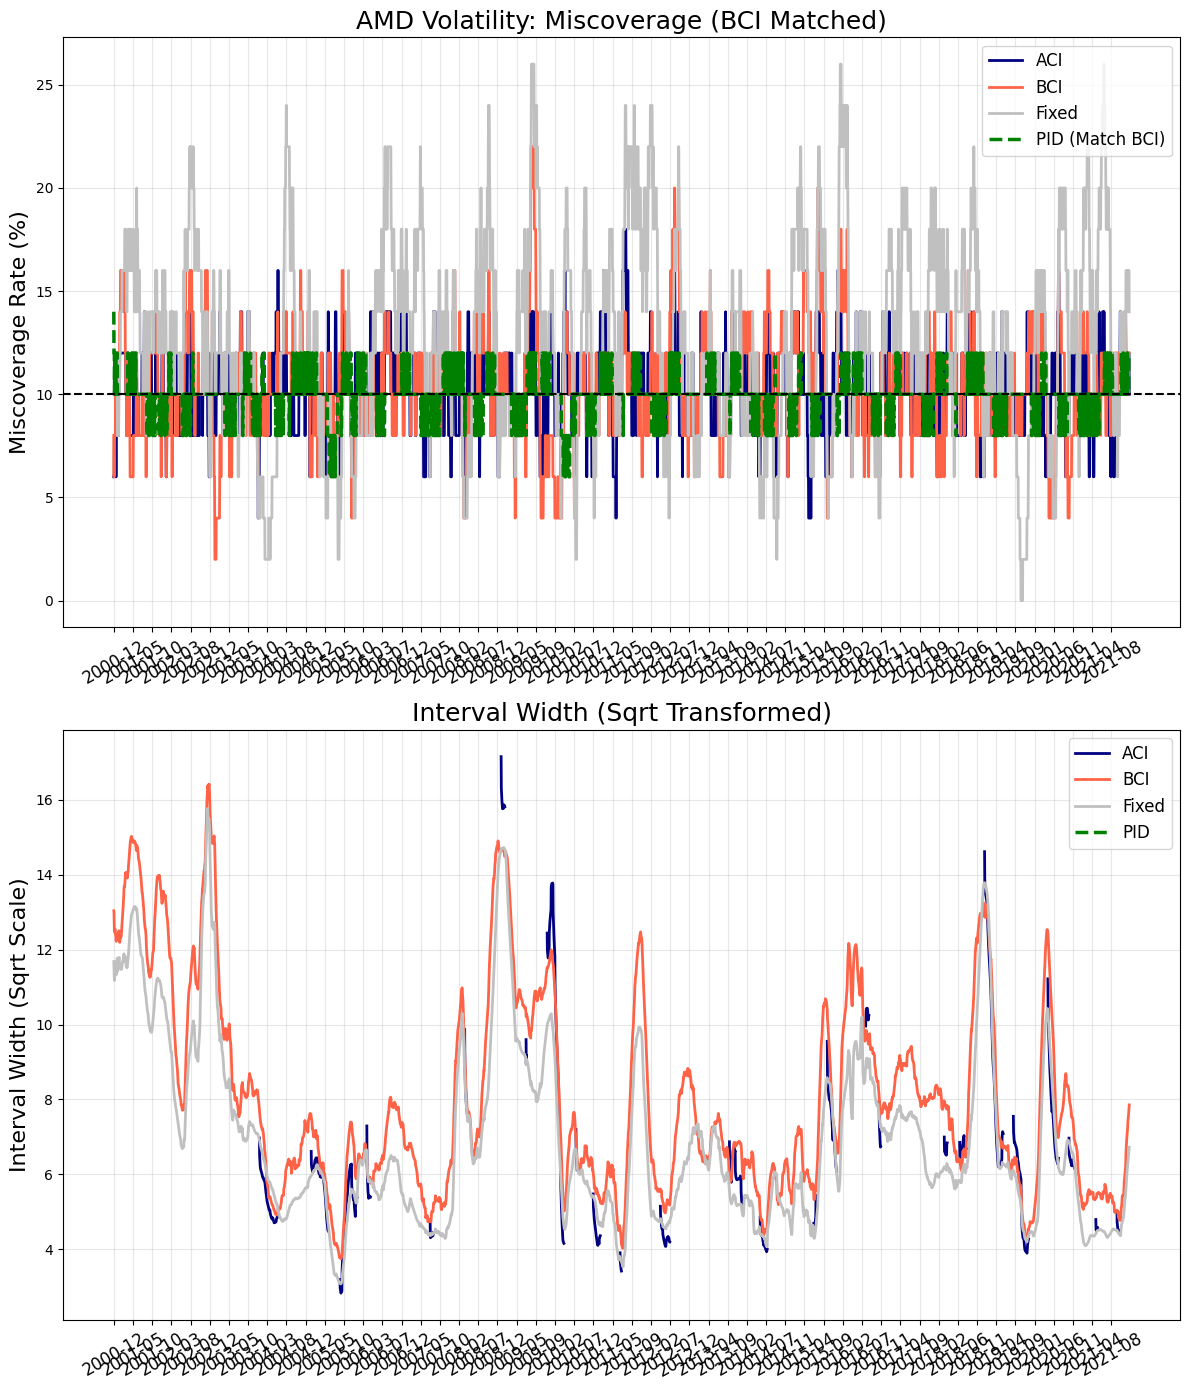

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

# Increase recursion depth
sys.setrecursionlimit(10000)

# --- HELPER: TRIM FUNCTION ---
def trim(val, degree):
    return val[degree:-degree]

# --- HELPER: COMPUTE VARIANCE ---
def compute_variance(result_df):
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    return var

# --- HELPER: BINARY SEARCH FOR BCI VARIANCE ---
def find_eta_matching_variance(exp_fixed, target_var, max_bound_5B):
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    ki = np.percentile(scores, 99)

    low, high = 1e-6, max_bound_5B
    best_eta = low
    best_diff = 1e10
    
    for i in range(20): 
        mid = np.sqrt(low * high)
        pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=mid, Csat=csat, KI=ki, ahead=1, T_burnin=100)
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper_pid = y_pred_center + q
        lower_pid = y_pred_center - q
        is_covered = (y_true >= lower_pid) & (y_true <= upper_pid)
        
        err_ind = (~is_covered).astype(float)
        curr_var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        diff = curr_var - target_var
        if abs(diff) < best_diff:
            best_diff = abs(diff)
            best_eta = mid
            
        if curr_var > target_var:
            low = mid
        else:
            high = mid
            
    # Run Final Result
    pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=best_eta, Csat=csat, KI=ki, ahead=1, T_burnin=100)
    q = np.maximum(np.array(pid_out['q']), 0.0)
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + q
    df_pid['lower'] = y_pred_center - q
    df_pid['upper'] = pd.to_numeric(df_pid['upper'])
    df_pid['lower'] = pd.to_numeric(df_pid['lower'])
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = (is_cov).astype(int)
    
    return df_pid, best_eta

def run_analysis_for_dataset(dataset):
    task = 'vlfc'
    print(f"\n{'='*60}")
    print(f"PROCESSING DATASET: {dataset}")
    print(f"{'='*60}")
    
    # 1. Load Baselines
    exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
    exp_fixed.run()

    exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci-{dataset}.yaml'))
    exp_bci.run()
    
    exp_aci = ForecastingExperiment(read_yaml(f'config/{task}-aci-{dataset}.yaml'))
    exp_aci.run()
    
    # 2. Match BCI Variance
    bci_var = compute_variance(exp_bci.result)
    print(f"  > Target BCI Variance: {bci_var:.2e}")
    
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    y_pred_center = (pd.to_numeric(exp_fixed.result['upper']) + pd.to_numeric(exp_fixed.result['lower'])) / 2
    scores = np.abs(y_true - y_pred_center)
    Bound_5B = 5 * np.percentile(scores, 99)
    print(f"  > 5B Search Limit: {Bound_5B:.4f}")
    
    pid_df, eta = find_eta_matching_variance(exp_fixed, bci_var, Bound_5B)
    print(f"  > Optimal Eta Found: {eta:.4f}")
    
    # 3. Process Data for Plotting (With Trim & Sqrt)
    ma_window = 50
    skip = 100
    
    def get_plot_data(df, window):
        upper = pd.to_numeric(df['upper'], errors='coerce')
        lower = pd.to_numeric(df['lower'], errors='coerce')
        true_y = pd.to_numeric(df['true_y'], errors='coerce')
        
        # Miscoverage (Smoothed)
        is_cov = (true_y >= lower) & (true_y <= upper)
        miscov_series = (~is_cov).astype(float).rolling(window).mean()
        
        # Length (SQRT TRANSFORMED)
        len_series = (np.sqrt(upper) - np.sqrt(lower)).rolling(window).mean()
        
        # TRIM
        miscov_trimmed = trim(miscov_series.values, window)
        len_trimmed = trim(len_series.values, window)
        
        # Averages
        avg_mis = np.nanmean(miscov_series) * 100
        avg_len = np.nanmean(len_series)
        
        return miscov_trimmed, len_trimmed, avg_mis, avg_len

    # Prepare Indices (Trimmed)
    full_index = exp_aci.result.index
    trimmed_index = trim(full_index, ma_window)
    
    # Get Data
    aci_m, aci_l, aci_avg_m, aci_avg_l = get_plot_data(exp_aci.result, ma_window)
    bci_m, bci_l, bci_avg_m, bci_avg_l = get_plot_data(exp_bci.result, ma_window)
    fix_m, fix_l, fix_avg_m, fix_avg_l = get_plot_data(exp_fixed.result, ma_window)
    pid_m, pid_l, pid_avg_m, pid_avg_l = get_plot_data(pid_df, ma_window)
    
    # X-Axis Ticks
    indices = range(0, len(trimmed_index), skip)
    x_labels = [trimmed_index[i].strftime("%Y-%m") for i in indices]

    # --- PLOTTING ---
    fig, axs = plt.subplots(2, 1, figsize=(12, 14))
    
    # PANEL 1: Miscoverage Rate
    axs[0].plot(100*aci_m, color='navy', label='ACI', linewidth=2)
    axs[0].plot(100*bci_m, color='tomato', label='BCI', linewidth=2)
    axs[0].plot(100*fix_m, color='silver', label='Fixed', linewidth=2)
    axs[0].plot(100*pid_m, color='green', linestyle='--', 
                label=f'PID', linewidth=2.5)
    
    axs[0].axhline(10, color='black', linestyle='--')
    axs[0].set_ylabel('Miscoverage Rate (%)', fontsize=16)
    axs[0].legend(loc='upper right', fontsize=12)
    axs[0].set_title(f'{dataset} Volatility: Miscoverage (BCI Matched)', fontsize=18)
    
    # PANEL 2: Interval Width (SQRT)
    axs[1].plot(aci_l, color='navy', label='ACI', linewidth=2)
    axs[1].plot(bci_l, color='tomato', label='BCI', linewidth=2)
    axs[1].plot(fix_l, color='silver', label='Fixed', linewidth=2)
    axs[1].plot(pid_l, color='green', linestyle='--', 
                label='PID', linewidth=2.5)
    
    axs[1].set_ylabel('Interval Width (Sqrt Scale)', fontsize=16)
    axs[1].set_title('Interval Width (Sqrt Transformed)', fontsize=18)
    axs[1].legend(loc='upper right', fontsize=12)
    
    for ax in axs:
        ax.set_xticks(indices)
        ax.set_xticklabels(x_labels, rotation=30, fontsize=12)
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    filename = f'{dataset}_VLFC_Standard_Sqrt.png'
    plt.savefig(filename, dpi=300)
    print(f"  > Graph saved to {filename}")

    # --- PRINT TABLE ---
    print("\n" + "-"*60)
    print(f"SUMMARY TABLE: {dataset}")
    print("-" * 60)
    print(f"{'Method':<10} | {'Avg Miscoverage (%)':<20} | {'Avg Length (Sqrt)':<20}")
    print("-" * 60)
    print(f"{'ACI':<10} | {aci_avg_m:<20.2f} | {aci_avg_l:<20.4f}")
    print(f"{'BCI':<10} | {bci_avg_m:<20.2f} | {bci_avg_l:<20.4f}")
    print(f"{'Fixed':<10} | {fix_avg_m:<20.2f} | {fix_avg_l:<20.4f}")
    print(f"{'PID':<10} | {pid_avg_m:<20.2f} | {pid_avg_l:<20.4f}")
    print("-" * 60)

if __name__ == "__main__":
    datasets = ['Amazon', 'AMD']
    
    for ds in datasets:
        try:
            run_analysis_for_dataset(ds)
        except Exception as e:
            print(f"FAILED for {ds}: {e}")

In [7]:
"""
Amazon: PID Targeting BCI Variance
BCI and PID run separately for each gamma
Binary search η in [0, 5B] where B = 99th percentile
Creates 4-line plots: ACI, BCI, Fixed, PID
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def compute_metrics(result_df):
    """Compute variance, miscoverage, length"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')
    
    # Variance (alpha > beta)
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    
    # Miscoverage
    miscov = err_ind.mean()
    
    # Length
    raw_lengths = upper - lower
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]
    length = valid_lengths.mean() if len(valid_lengths) > 0 else 0.0
    
    return var, miscov, length


def run_pid_variance(scores, eta, csat, ki, y_pred_center, y_true):
    """Run PID and return variance"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper = y_pred_center + q
        lower = y_pred_center - q
        is_covered = (y_true >= lower) & (y_true <= upper)
        
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        return var, True, q
    except:
        return 1e10, False, None


def binary_search_5B(scores, y_pred_center, y_true, csat, ki, target_var):
    """Binary search in [0, 5B] to match target variance"""
    B = np.percentile(scores, 99)
    bound_5B = 5 * B
    
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = 1e10
    best_q = None
    
    print(f"    Binary search [0, {bound_5B:.4f}]...", end=" ")
    
    for _ in range(25):
        mid = np.sqrt(low * high)
        var, valid, q = run_pid_variance(scores, mid, csat, ki, y_pred_center, y_true)
        
        if not valid:
            high = mid
            continue
        
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_q = q
        
        if var > target_var:
            low = mid
        else:
            high = mid
    
    status = "Hit 5B Bound" if abs(best_eta - bound_5B) < 1e-4 else "Interior"
    print(f"η={best_eta:.4f} ({status})")
    
    return best_eta, best_q, bound_5B


def create_pid_df(exp_fixed, pid_q):
    """Create PID result dataframe"""
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + pid_q
    df_pid['lower'] = y_pred_center - pid_q
    df_pid['alpha'] = 0.1
    
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = is_cov.astype(int)
    
    return df_pid


# =============================================================================
# MAIN SCRIPT
# =============================================================================

if __name__ == "__main__":
    dataset = 'Amazon'
    task = 'rtfc'
    gammas = [0.1, 0.008]
    
    print(f"\n{'='*70}")
    print(f"AMAZON RETURNS: PID TARGETING BCI VARIANCE")
    print(f"BCI and PID run separately for each gamma")
    print(f"{'='*70}")
    
    # Load Fixed only once (doesn't change with gamma)
    print(f"\nLoading Fixed baseline...")
    exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
    exp_fixed.run()
    
    fixed_var, fixed_miscov, fixed_len = compute_metrics(exp_fixed.result)
    
    # Prepare PID data (same for both gammas)
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    ki = np.percentile(scores, 99)
    
    print(f"K_I (99th %ile):       {ki:.4f}")
    
    # Loop through gammas - BCI and PID run for EACH gamma
    summary_data = []
    
    for gamma in gammas:
        print(f"\n{'-'*70}")
        print(f"γ = {gamma}")
        print(f"{'-'*70}")
        
        # Load ACI with this gamma
        print(f"  Loading ACI...")
        aci_config = read_yaml(f'config/{task}-aci-{dataset}.yaml')
        aci_config['gamma'] = gamma
        exp_aci = ForecastingExperiment(aci_config)
        exp_aci.run()
        
        # Load BCI (uses its own parameters)
        # Load BCI and adjust parameters based on gamma
        print(f"  Loading BCI...")
        bci_config = read_yaml(f'config/{task}-bci-{dataset}.yaml')

        # Print BEFORE adjustment
        print(f"    BEFORE: gamma={bci_config['gamma']}, lambda_init={bci_config['lambda_init']}")

        # Scale BCI parameters for loose control (ratio: 0.1/0.008 = 12.5)
        if gamma == 0.008:
            bci_config['gamma'] = bci_config['gamma'] / 12.5
            bci_config['lambda_init'] = bci_config['lambda_init'] / 12.5
            print(f"    AFTER adjustment: gamma={bci_config['gamma']:.1f}, lambda_init={bci_config['lambda_init']:.1f}")

        exp_bci = ForecastingExperiment(bci_config)
        exp_bci.run()

        # Print BCI variance to confirm it changed
        bci_var_check = compute_metrics(exp_bci.result)
        print(f"    BCI variance: {bci_var_check[0]:.2e}")        
        # Get metrics
        aci_var, aci_miscov, aci_len = compute_metrics(exp_aci.result)
        bci_var, bci_miscov, bci_len = compute_metrics(exp_bci.result)
        
        print(f"  BCI Variance (TARGET): {bci_var:.2e}")
        print(f"  ACI Variance (ref):    {aci_var:.2e}")
        
        # Binary search for PID targeting THIS BCI variance
        eta_found, pid_q, bound_5B = binary_search_5B(scores, y_pred_center, y_true, 
                                                       csat, ki, bci_var)
        
        # Create PID dataframe
        pid_df = create_pid_df(exp_fixed, pid_q)
        pid_var, pid_miscov, pid_len = compute_metrics(pid_df)
        
        print(f"  PID Variance achieved: {pid_var:.2e} (error: {abs(pid_var-bci_var)/bci_var*100:.1f}%)")
        print(f"  Bound (5B):            {bound_5B:.4f}")
        
        # Print summary table
        print(f"\n  SUMMARY TABLE:")
        print(f"  {'Method':<10} | {'Variance':<12} | {'Var vs BCI':<12} | {'Miscov(%)':<10} | {'Length':<10} | {'Len vs BCI':<12}")
        print(f"  {'-'*85}")
        print(f"  {'ACI':<10} | {aci_var:<12.2e} | {(aci_var/bci_var-1)*100:>11.1f}% | {aci_miscov*100:<10.2f} | {aci_len:<10.4f} | {(aci_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'BCI':<10} | {bci_var:<12.2e} | {'0.0%':>12} | {bci_miscov*100:<10.2f} | {bci_len:<10.4f} | {'0.0%':>12}")
        print(f"  {'Fixed':<10} | {fixed_var:<12.2e} | {(fixed_var/bci_var-1)*100:>11.1f}% | {fixed_miscov*100:<10.2f} | {fixed_len:<10.4f} | {(fixed_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'PID':<10} | {pid_var:<12.2e} | {(pid_var/bci_var-1)*100:>11.1f}% | {pid_miscov*100:<10.2f} | {pid_len:<10.4f} | {(pid_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'-'*85}")
        
        # Create 4-line plot
        print(f"  Creating visualization...")
        
        fig, axs = plt.subplots(2, 1, figsize=(10, 15))
        
        def clean_df(df):
            df['upper'] = pd.to_numeric(df['upper'], errors='coerce')
            df['lower'] = pd.to_numeric(df['lower'], errors='coerce')
            df['true_y'] = pd.to_numeric(df['true_y'], errors='coerce')
            return df
        
        ma_window = 250
        skip = 300
        xform = lambda x: x
        
        p_aci = gen_plot_data(clean_df(exp_aci.result), ma_window, skip, xform)
        p_bci = gen_plot_data(clean_df(exp_bci.result), ma_window, skip, xform)
        p_fix = gen_plot_data(clean_df(exp_fixed.result), ma_window, skip, xform)
        p_pid = gen_plot_data(clean_df(pid_df), ma_window, skip, xform)
        
        # Panel 1: Miscoverage
        axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI', linewidth=3)
        axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI', linewidth=3)
        axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=3)
        axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                    label=f'PID', linewidth=3)
        axs[0].axhline(10, color='black', linestyle='--')
        axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=25)
        axs[0].legend(loc='upper right', prop={'size': 20})
        axs[0].set_xticks(p_aci['indices'])
        axs[0].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)
        
        for label in axs[0].get_yticklabels():
            label.set_fontsize(20)

        # Panel 2: Length
        axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=3)
        axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=3)
        axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=3)
        axs[1].plot(p_pid['length'], color='green', label='PID', linewidth=3)
        axs[1].set_ylabel('Interval Length', fontsize=25)
        axs[1].legend(loc='upper right', prop={'size': 20})
        axs[1].set_xticks(p_aci['indices'])
        axs[1].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)

        for label in axs[1].get_yticklabels():
            label.set_fontsize(20)

        fig.suptitle(f'Return forecasting for {dataset} (γ={gamma})', fontsize=30, y=1.0005)
        plt.tight_layout()
        
        filename = f'{dataset}_{task}_gamma{gamma}_PID_BCI_target.png'
        plt.savefig(filename, dpi=300)
        print(f"  ✓ Saved: {filename}")
        plt.close()
        
        # Collect summary
        summary_data.append({
            'gamma': gamma,
            'eta': eta_found,
            'bound_5B': bound_5B,
            'bci_var': bci_var,
            'pid_var': pid_var,
            'var_ratio': pid_var / bci_var,
            'bci_miscov': bci_miscov * 100,
            'pid_miscov': pid_miscov * 100,
            'bci_length': bci_len,
            'pid_length': pid_len
        })
    
    # Final summary
    print(f"\n{'='*70}")
    print(f"FINAL SUMMARY")
    print(f"{'='*70}")
    print(f"\n{'Gamma':<8} {'Eta':<10} {'Var (BCI)':<12} {'Var (PID)':<12} {'Var Ratio':<12} "
          f"{'Miscov BCI':<12} {'Miscov PID':<12} {'Length BCI':<12} {'Length PID':<12}")
    print("-" * 120)
    
    for row in summary_data:
        print(f"{row['gamma']:<8.3f} {row['eta']:<10.4f} {row['bci_var']:<12.2e} "
              f"{row['pid_var']:<12.2e} {row['var_ratio']:<12.3f} "
              f"{row['bci_miscov']:<12.2f} {row['pid_miscov']:<12.2f} "
              f"{row['bci_length']:<12.4f} {row['pid_length']:<12.4f}")
    
    print(f"\n{'='*70}")
    print("DONE!")
    print(f"{'='*70}")

2026-01-29 01:42:16,682 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA STARTED



AMAZON RETURNS: PID TARGETING BCI VARIANCE
BCI and PID run separately for each gamma

Loading Fixed baseline...


2026-01-29 01:42:19,800 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA ENDED in 3.1181161403656006s
2026-01-29 01:42:19,812 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 STARTED


K_I (99th %ile):       0.0668

----------------------------------------------------------------------
γ = 0.1
----------------------------------------------------------------------
  Loading ACI...


2026-01-29 01:42:23,061 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 ENDED in 3.2486941814422607s
2026-01-29 01:42:23,071 - INFO - Experiment rtfc-bci-Amazon-gamma_0.8-lambda0_5.0 STARTED


...

  Loading BCI...
    BEFORE: gamma=0.8, lambda_init=5.0
    AFTER adjustment: gamma=0.1, lambda_init=0.4


2026-01-29 01:42:49,288 - INFO - Experiment rtfc-bci-Amazon-gamma_0.064-lambda0_0.4 ENDED in 10.100529193878174s


    BCI variance: 3.89e-03
  BCI Variance (TARGET): 3.89e-03
  ACI Variance (ref):    4.24e-03
    Binary search [0, 0.3339]... 

100%|██████████| 3762/3762 [00:00<00:00, 195885.54it/s]


η=0.0139 (Interior)
  PID Variance achieved: 3.88e-03 (error: 0.2%)
  Bound (5B):            0.3339

  SUMMARY TABLE:
  Method     | Variance     | Var vs BCI   | Miscov(%)  | Length     | Len vs BCI  
  -------------------------------------------------------------------------------------
  ACI        | 4.24e-03     |         9.1% | 9.97       | 0.0766     |         9.2%
  BCI        | 3.89e-03     |         0.0% | 10.10      | 0.0702     |         0.0%
  Fixed      | 4.65e-03     |        19.6% | 6.35       | 0.0915     |        30.4%
  PID        | 3.88e-03     |        -0.2% | 10.53      | 0.0752     |         7.1%
  -------------------------------------------------------------------------------------
  Creating visualization...
  ✓ Saved: Amazon_rtfc_gamma0.008_PID_BCI_target.png

FINAL SUMMARY

Gamma    Eta        Var (BCI)    Var (PID)    Var Ratio    Miscov BCI   Miscov PID   Length BCI   Length PID  
------------------------------------------------------------------------------

In [8]:
"""
AMD: PID Targeting BCI Variance
BCI and PID run separately for each gamma
Binary search η in [0, 5B] where B = 99th percentile
Creates 4-line plots: ACI, BCI, Fixed, PID
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def compute_metrics(result_df):
    """Compute variance, miscoverage, length"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')
    
    # Variance (alpha > beta)
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    
    # Miscoverage
    miscov = err_ind.mean()
    
    # Length
    raw_lengths = upper - lower
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]
    length = valid_lengths.mean() if len(valid_lengths) > 0 else 0.0
    
    return var, miscov, length


def run_pid_variance(scores, eta, csat, ki, y_pred_center, y_true):
    """Run PID and return variance"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper = y_pred_center + q
        lower = y_pred_center - q
        is_covered = (y_true >= lower) & (y_true <= upper)
        
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        return var, True, q
    except:
        return 1e10, False, None


def binary_search_5B(scores, y_pred_center, y_true, csat, ki, target_var):
    """Binary search in [0, 5B] to match target variance"""
    B = np.percentile(scores, 99)
    bound_5B = 5 * B
    
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = 1e10
    best_q = None
    
    print(f"    Binary search [0, {bound_5B:.4f}]...", end=" ")
    
    for _ in range(25):
        mid = np.sqrt(low * high)
        var, valid, q = run_pid_variance(scores, mid, csat, ki, y_pred_center, y_true)
        
        if not valid:
            high = mid
            continue
        
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_q = q
        
        if var > target_var:
            low = mid
        else:
            high = mid
    
    status = "Hit 5B Bound" if abs(best_eta - bound_5B) < 1e-4 else "Interior"
    print(f"η={best_eta:.4f} ({status})")
    
    return best_eta, best_q, bound_5B


def create_pid_df(exp_fixed, pid_q):
    """Create PID result dataframe"""
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + pid_q
    df_pid['lower'] = y_pred_center - pid_q
    df_pid['alpha'] = 0.1
    
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = is_cov.astype(int)
    
    return df_pid


# =============================================================================
# MAIN SCRIPT
# =============================================================================

if __name__ == "__main__":
    dataset = 'AMD'
    task = 'rtfc'
    gammas = [0.1, 0.008]
    
    print(f"\n{'='*70}")
    print(f"AMAZON RETURNS: PID TARGETING BCI VARIANCE")
    print(f"BCI and PID run separately for each gamma")
    print(f"{'='*70}")
    
    # Load Fixed only once (doesn't change with gamma)
    print(f"\nLoading Fixed baseline...")
    exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
    exp_fixed.run()
    
    fixed_var, fixed_miscov, fixed_len = compute_metrics(exp_fixed.result)
    
    # Prepare PID data (same for both gammas)
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    ki = np.percentile(scores, 99)
    
    print(f"K_I (99th %ile):       {ki:.4f}")
    
    # Loop through gammas - BCI and PID run for EACH gamma
    summary_data = []
    
    for gamma in gammas:
        print(f"\n{'-'*70}")
        print(f"γ = {gamma}")
        print(f"{'-'*70}")
        
        # Load ACI with this gamma
        print(f"  Loading ACI...")
        aci_config = read_yaml(f'config/{task}-aci-{dataset}.yaml')
        aci_config['gamma'] = gamma
        exp_aci = ForecastingExperiment(aci_config)
        exp_aci.run()
        
        # Load BCI (uses its own parameters)
        # Load BCI and adjust parameters based on gamma
        print(f"  Loading BCI...")
        bci_config = read_yaml(f'config/{task}-bci-{dataset}.yaml')

        # Print BEFORE adjustment
        print(f"    BEFORE: gamma={bci_config['gamma']}, lambda_init={bci_config['lambda_init']}")

        # Scale BCI parameters for loose control (ratio: 0.1/0.008 = 12.5)
        if gamma == 0.008:
            bci_config['gamma'] = bci_config['gamma'] / 12.5
            bci_config['lambda_init'] = bci_config['lambda_init'] / 12.5
            print(f"    AFTER adjustment: gamma={bci_config['gamma']:.1f}, lambda_init={bci_config['lambda_init']:.1f}")

        exp_bci = ForecastingExperiment(bci_config)
        exp_bci.run()

        # Print BCI variance to confirm it changed
        bci_var_check = compute_metrics(exp_bci.result)
        print(f"    BCI variance: {bci_var_check[0]:.2e}")        
        # Get metrics
        aci_var, aci_miscov, aci_len = compute_metrics(exp_aci.result)
        bci_var, bci_miscov, bci_len = compute_metrics(exp_bci.result)
        
        print(f"  BCI Variance (TARGET): {bci_var:.2e}")
        print(f"  ACI Variance (ref):    {aci_var:.2e}")
        
        # Binary search for PID targeting THIS BCI variance
        eta_found, pid_q, bound_5B = binary_search_5B(scores, y_pred_center, y_true, 
                                                       csat, ki, bci_var)
        
        # Create PID dataframe
        pid_df = create_pid_df(exp_fixed, pid_q)
        pid_var, pid_miscov, pid_len = compute_metrics(pid_df)
        
        print(f"  PID Variance achieved: {pid_var:.2e} (error: {abs(pid_var-bci_var)/bci_var*100:.1f}%)")
        print(f"  Bound (5B):            {bound_5B:.4f}")
        
        # Print summary table
        print(f"\n  SUMMARY TABLE:")
        print(f"  {'Method':<10} | {'Variance':<12} | {'Var vs BCI':<12} | {'Miscov(%)':<10} | {'Length':<10} | {'Len vs BCI':<12}")
        print(f"  {'-'*85}")
        print(f"  {'ACI':<10} | {aci_var:<12.2e} | {(aci_var/bci_var-1)*100:>11.1f}% | {aci_miscov*100:<10.2f} | {aci_len:<10.4f} | {(aci_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'BCI':<10} | {bci_var:<12.2e} | {'0.0%':>12} | {bci_miscov*100:<10.2f} | {bci_len:<10.4f} | {'0.0%':>12}")
        print(f"  {'Fixed':<10} | {fixed_var:<12.2e} | {(fixed_var/bci_var-1)*100:>11.1f}% | {fixed_miscov*100:<10.2f} | {fixed_len:<10.4f} | {(fixed_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'PID':<10} | {pid_var:<12.2e} | {(pid_var/bci_var-1)*100:>11.1f}% | {pid_miscov*100:<10.2f} | {pid_len:<10.4f} | {(pid_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'-'*85}")
        
        # Create 4-line plot
        print(f"  Creating visualization...")
        
        fig, axs = plt.subplots(2, 1, figsize=(10, 15))
        
        def clean_df(df):
            df['upper'] = pd.to_numeric(df['upper'], errors='coerce')
            df['lower'] = pd.to_numeric(df['lower'], errors='coerce')
            df['true_y'] = pd.to_numeric(df['true_y'], errors='coerce')
            return df
        
        ma_window = 250
        skip = 300
        xform = lambda x: x
        
        p_aci = gen_plot_data(clean_df(exp_aci.result), ma_window, skip, xform)
        p_bci = gen_plot_data(clean_df(exp_bci.result), ma_window, skip, xform)
        p_fix = gen_plot_data(clean_df(exp_fixed.result), ma_window, skip, xform)
        p_pid = gen_plot_data(clean_df(pid_df), ma_window, skip, xform)
        
        # Panel 1: Miscoverage
        axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI', linewidth=3)
        axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI', linewidth=3)
        axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=3)
        axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                    label=f'PID', linewidth=3)
        axs[0].axhline(10, color='black', linestyle='--')
        axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=25)
        axs[0].legend(loc='upper right', prop={'size': 20})
        axs[0].set_xticks(p_aci['indices'])
        axs[0].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)
        
        for label in axs[0].get_yticklabels():
            label.set_fontsize(20)

        # Panel 2: Length
        axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=3)
        axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=3)
        axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=3)
        axs[1].plot(p_pid['length'], color='green', label='PID', linewidth=3)
        axs[1].set_ylabel('Interval Length', fontsize=25)
        axs[1].legend(loc='upper right', prop={'size': 20})
        axs[1].set_xticks(p_aci['indices'])
        axs[1].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)

        for label in axs[1].get_yticklabels():
            label.set_fontsize(20)

        fig.suptitle(f'Return forecasting for {dataset} (γ={gamma})', fontsize=30, y=1.0005)
        plt.tight_layout()
        
        filename = f'{dataset}_{task}_gamma{gamma}_PID_BCI_target.png'
        plt.savefig(filename, dpi=300)
        print(f"  ✓ Saved: {filename}")
        plt.close()
        
        # Collect summary
        summary_data.append({
            'gamma': gamma,
            'eta': eta_found,
            'bound_5B': bound_5B,
            'bci_var': bci_var,
            'pid_var': pid_var,
            'var_ratio': pid_var / bci_var,
            'bci_miscov': bci_miscov * 100,
            'pid_miscov': pid_miscov * 100,
            'bci_length': bci_len,
            'pid_length': pid_len
        })
    
    # Final summary
    print(f"\n{'='*70}")
    print(f"FINAL SUMMARY")
    print(f"{'='*70}")
    print(f"\n{'Gamma':<8} {'Eta':<10} {'Var (BCI)':<12} {'Var (PID)':<12} {'Var Ratio':<12} "
          f"{'Miscov BCI':<12} {'Miscov PID':<12} {'Length BCI':<12} {'Length PID':<12}")
    print("-" * 120)
    
    for row in summary_data:
        print(f"{row['gamma']:<8.3f} {row['eta']:<10.4f} {row['bci_var']:<12.2e} "
              f"{row['pid_var']:<12.2e} {row['var_ratio']:<12.3f} "
              f"{row['bci_miscov']:<12.2f} {row['pid_miscov']:<12.2f} "
              f"{row['bci_length']:<12.4f} {row['pid_length']:<12.4f}")
    
    print(f"\n{'='*70}")
    print("DONE!")
    print(f"{'='*70}")

2026-01-29 01:42:52,174 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA STARTED



AMAZON RETURNS: PID TARGETING BCI VARIANCE
BCI and PID run separately for each gamma

Loading Fixed baseline...


2026-01-29 01:42:54,537 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 2.3633310794830322s
2026-01-29 01:42:54,547 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED


K_I (99th %ile):       0.0828

----------------------------------------------------------------------
γ = 0.1
----------------------------------------------------------------------
  Loading ACI...


2026-01-29 01:42:56,884 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 2.336583137512207s
2026-01-29 01:42:56,892 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 STARTED


...

  Loading BCI...
    BEFORE: gamma=0.8, lambda_init=5.0
    AFTER adjustment: gamma=0.1, lambda_init=0.4


2026-01-29 01:43:17,120 - INFO - Experiment rtfc-bci-AMD-gamma_0.064-lambda0_0.4 ENDED in 7.8015289306640625s


    BCI variance: 4.60e-03
  BCI Variance (TARGET): 4.60e-03
  ACI Variance (ref):    3.19e-03
    Binary search [0, 0.4142]... 

100%|██████████| 2834/2834 [00:00<00:00, 192057.93it/s]


η=0.0000 (Interior)
  PID Variance achieved: 4.29e-03 (error: 6.6%)
  Bound (5B):            0.4142

  SUMMARY TABLE:
  Method     | Variance     | Var vs BCI   | Miscov(%)  | Length     | Len vs BCI  
  -------------------------------------------------------------------------------------
  ACI        | 3.19e-03     |       -30.6% | 9.99       | 0.1060     |         8.0%
  BCI        | 4.60e-03     |         0.0% | 10.62      | 0.0982     |         0.0%
  Fixed      | 2.68e-03     |       -41.6% | 7.02       | 0.1177     |        19.9%
  PID        | 4.29e-03     |        -6.6% | 13.80      | 0.0938     |        -4.5%
  -------------------------------------------------------------------------------------
  Creating visualization...
  ✓ Saved: AMD_rtfc_gamma0.008_PID_BCI_target.png

FINAL SUMMARY

Gamma    Eta        Var (BCI)    Var (PID)    Var Ratio    Miscov BCI   Miscov PID   Length BCI   Length PID  
---------------------------------------------------------------------------------

In [10]:
"""
NVIDIA: PID Targeting BCI Variance
BCI and PID run separately for each gamma
Binary search η in [0, 5B] where B = 99th percentile
Creates 4-line plots: ACI, BCI, Fixed, PID
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def compute_metrics(result_df):
    """Compute variance, miscoverage, length"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')
    
    # Variance (alpha > beta)
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    
    # Miscoverage
    miscov = err_ind.mean()
    
    # Length
    raw_lengths = upper - lower
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]
    length = valid_lengths.mean() if len(valid_lengths) > 0 else 0.0
    
    return var, miscov, length


def run_pid_variance(scores, eta, csat, ki, y_pred_center, y_true):
    """Run PID and return variance"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper = y_pred_center + q
        lower = y_pred_center - q
        is_covered = (y_true >= lower) & (y_true <= upper)
        
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        return var, True, q
    except:
        return 1e10, False, None


def binary_search_5B(scores, y_pred_center, y_true, csat, ki, target_var):
    """Binary search in [0, 5B] to match target variance"""
    B = np.percentile(scores, 99)
    bound_5B = 5 * B
    
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = 1e10
    best_q = None
    
    print(f"    Binary search [0, {bound_5B:.4f}]...", end=" ")
    
    for _ in range(25):
        mid = np.sqrt(low * high)
        var, valid, q = run_pid_variance(scores, mid, csat, ki, y_pred_center, y_true)
        
        if not valid:
            high = mid
            continue
        
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_q = q
        
        if var > target_var:
            low = mid
        else:
            high = mid
    
    status = "Hit 5B Bound" if abs(best_eta - bound_5B) < 1e-4 else "Interior"
    print(f"η={best_eta:.4f} ({status})")
    
    return best_eta, best_q, bound_5B


def create_pid_df(exp_fixed, pid_q):
    """Create PID result dataframe"""
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + pid_q
    df_pid['lower'] = y_pred_center - pid_q
    df_pid['alpha'] = 0.1
    
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = is_cov.astype(int)
    
    return df_pid


# =============================================================================
# MAIN SCRIPT
# =============================================================================

if __name__ == "__main__":
    dataset = 'NVIDIA'
    task = 'rtfc'
    gammas = [0.1, 0.008]
    
    print(f"\n{'='*70}")
    print(f"AMAZON RETURNS: PID TARGETING BCI VARIANCE")
    print(f"BCI and PID run separately for each gamma")
    print(f"{'='*70}")
    
    # Load Fixed only once (doesn't change with gamma)
    print(f"\nLoading Fixed baseline...")
    exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
    exp_fixed.run()
    
    fixed_var, fixed_miscov, fixed_len = compute_metrics(exp_fixed.result)
    
    # Prepare PID data (same for both gammas)
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    ki = np.percentile(scores, 99)
    
    print(f"K_I (99th %ile):       {ki:.4f}")
    
    # Loop through gammas - BCI and PID run for EACH gamma
    summary_data = []
    
    for gamma in gammas:
        print(f"\n{'-'*70}")
        print(f"γ = {gamma}")
        print(f"{'-'*70}")
        
        # Load ACI with this gamma
        print(f"  Loading ACI...")
        aci_config = read_yaml(f'config/{task}-aci-{dataset}.yaml')
        aci_config['gamma'] = gamma
        exp_aci = ForecastingExperiment(aci_config)
        exp_aci.run()
        
        # Load BCI (uses its own parameters)
        # Load BCI and adjust parameters based on gamma
        print(f"  Loading BCI...")
        bci_config = read_yaml(f'config/{task}-bci-{dataset}.yaml')

        # Print BEFORE adjustment
        print(f"    BEFORE: gamma={bci_config['gamma']}, lambda_init={bci_config['lambda_init']}")

        # Scale BCI parameters for loose control (ratio: 0.1/0.008 = 12.5)
        if gamma == 0.008:
            bci_config['gamma'] = bci_config['gamma'] / 12.5
            bci_config['lambda_init'] = bci_config['lambda_init'] / 12.5
            print(f"    AFTER adjustment: gamma={bci_config['gamma']:.1f}, lambda_init={bci_config['lambda_init']:.1f}")

        exp_bci = ForecastingExperiment(bci_config)
        exp_bci.run()

        # Print BCI variance to confirm it changed
        bci_var_check = compute_metrics(exp_bci.result)
        print(f"    BCI variance: {bci_var_check[0]:.2e}")        
        # Get metrics
        aci_var, aci_miscov, aci_len = compute_metrics(exp_aci.result)
        bci_var, bci_miscov, bci_len = compute_metrics(exp_bci.result)
        
        print(f"  BCI Variance (TARGET): {bci_var:.2e}")
        print(f"  ACI Variance (ref):    {aci_var:.2e}")
        
        # Binary search for PID targeting THIS BCI variance
        eta_found, pid_q, bound_5B = binary_search_5B(scores, y_pred_center, y_true, 
                                                       csat, ki, bci_var)
        
        # Create PID dataframe
        pid_df = create_pid_df(exp_fixed, pid_q)
        pid_var, pid_miscov, pid_len = compute_metrics(pid_df)
        
        print(f"  PID Variance achieved: {pid_var:.2e} (error: {abs(pid_var-bci_var)/bci_var*100:.1f}%)")
        print(f"  Bound (5B):            {bound_5B:.4f}")
        
        # Print summary table
        print(f"\n  SUMMARY TABLE:")
        print(f"  {'Method':<10} | {'Variance':<12} | {'Var vs BCI':<12} | {'Miscov(%)':<10} | {'Length':<10} | {'Len vs BCI':<12}")
        print(f"  {'-'*85}")
        print(f"  {'ACI':<10} | {aci_var:<12.2e} | {(aci_var/bci_var-1)*100:>11.1f}% | {aci_miscov*100:<10.2f} | {aci_len:<10.4f} | {(aci_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'BCI':<10} | {bci_var:<12.2e} | {'0.0%':>12} | {bci_miscov*100:<10.2f} | {bci_len:<10.4f} | {'0.0%':>12}")
        print(f"  {'Fixed':<10} | {fixed_var:<12.2e} | {(fixed_var/bci_var-1)*100:>11.1f}% | {fixed_miscov*100:<10.2f} | {fixed_len:<10.4f} | {(fixed_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'PID':<10} | {pid_var:<12.2e} | {(pid_var/bci_var-1)*100:>11.1f}% | {pid_miscov*100:<10.2f} | {pid_len:<10.4f} | {(pid_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'-'*85}")
        
        # Create 4-line plot
        print(f"  Creating visualization...")
        
        fig, axs = plt.subplots(2, 1, figsize=(10, 15))
        
        def clean_df(df):
            df['upper'] = pd.to_numeric(df['upper'], errors='coerce')
            df['lower'] = pd.to_numeric(df['lower'], errors='coerce')
            df['true_y'] = pd.to_numeric(df['true_y'], errors='coerce')
            return df
        
        ma_window = 250
        skip = 300
        xform = lambda x: x
        
        p_aci = gen_plot_data(clean_df(exp_aci.result), ma_window, skip, xform)
        p_bci = gen_plot_data(clean_df(exp_bci.result), ma_window, skip, xform)
        p_fix = gen_plot_data(clean_df(exp_fixed.result), ma_window, skip, xform)
        p_pid = gen_plot_data(clean_df(pid_df), ma_window, skip, xform)
        
        # Panel 1: Miscoverage
        axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI', linewidth=3)
        axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI', linewidth=3)
        axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=3)
        axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                    label=f'PID', linewidth=3)
        axs[0].axhline(10, color='black', linestyle='--')
        axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=25)
        axs[0].legend(loc='upper right', prop={'size': 20})
        axs[0].set_xticks(p_aci['indices'])
        axs[0].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)
        
        for label in axs[0].get_yticklabels():
            label.set_fontsize(20)

        # Panel 2: Length
        axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=3)
        axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=3)
        axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=3)
        axs[1].plot(p_pid['length'], color='green', label='PID', linewidth=3)
        axs[1].set_ylabel('Interval Length', fontsize=25)
        axs[1].legend(loc='upper right', prop={'size': 20})
        axs[1].set_xticks(p_aci['indices'])
        axs[1].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)

        for label in axs[1].get_yticklabels():
            label.set_fontsize(20)

        fig.suptitle(f'Return forecasting for {dataset} (γ={gamma})', fontsize=30, y=1.0005)
        plt.tight_layout()
        
        filename = f'{dataset}_{task}_gamma{gamma}_PID_BCI_target.png'
        plt.savefig(filename, dpi=300)
        print(f"  ✓ Saved: {filename}")
        plt.close()
        
        # Collect summary
        summary_data.append({
            'gamma': gamma,
            'eta': eta_found,
            'bound_5B': bound_5B,
            'bci_var': bci_var,
            'pid_var': pid_var,
            'var_ratio': pid_var / bci_var,
            'bci_miscov': bci_miscov * 100,
            'pid_miscov': pid_miscov * 100,
            'bci_length': bci_len,
            'pid_length': pid_len
        })
    
    # Final summary
    print(f"\n{'='*70}")
    print(f"FINAL SUMMARY")
    print(f"{'='*70}")
    print(f"\n{'Gamma':<8} {'Eta':<10} {'Var (BCI)':<12} {'Var (PID)':<12} {'Var Ratio':<12} "
          f"{'Miscov BCI':<12} {'Miscov PID':<12} {'Length BCI':<12} {'Length PID':<12}")
    print("-" * 120)
    
    for row in summary_data:
        print(f"{row['gamma']:<8.3f} {row['eta']:<10.4f} {row['bci_var']:<12.2e} "
              f"{row['pid_var']:<12.2e} {row['var_ratio']:<12.3f} "
              f"{row['bci_miscov']:<12.2f} {row['pid_miscov']:<12.2f} "
              f"{row['bci_length']:<12.4f} {row['pid_length']:<12.4f}")
    
    print(f"\n{'='*70}")
    print("DONE!")
    print(f"{'='*70}")

2026-01-29 01:43:44,855 - INFO - Experiment rtfc-fixed-Nvidia-gamma_NA-lambda0_NA STARTED



AMAZON RETURNS: PID TARGETING BCI VARIANCE
BCI and PID run separately for each gamma

Loading Fixed baseline...


2026-01-29 01:43:47,703 - INFO - Experiment rtfc-fixed-Nvidia-gamma_NA-lambda0_NA ENDED in 2.847172260284424s
2026-01-29 01:43:47,715 - INFO - Experiment rtfc-aci-Nvidia-gamma_0.1-lambda0_0.9 STARTED


K_I (99th %ile):       0.0710

----------------------------------------------------------------------
γ = 0.1
----------------------------------------------------------------------
  Loading ACI...


2026-01-29 01:43:50,276 - INFO - Experiment rtfc-aci-Nvidia-gamma_0.1-lambda0_0.9 ENDED in 2.5606892108917236s
2026-01-29 01:43:50,284 - INFO - Experiment rtfc-bci-Nvidia-gamma_0.4-lambda0_1.0 STARTED


...

  Loading BCI...
    BEFORE: gamma=0.4, lambda_init=1.0
    AFTER adjustment: gamma=0.0, lambda_init=0.1


2026-01-29 01:44:12,096 - INFO - Experiment rtfc-bci-Nvidia-gamma_0.032-lambda0_0.08 ENDED in 8.485651969909668s


    BCI variance: 9.50e-03
  BCI Variance (TARGET): 9.50e-03
  ACI Variance (ref):    3.79e-03
    Binary search [0, 0.3550]... 

100%|██████████| 3058/3058 [00:00<00:00, 193421.73it/s]


η=0.0000 (Interior)
  PID Variance achieved: 4.91e-03 (error: 48.3%)
  Bound (5B):            0.3550

  SUMMARY TABLE:
  Method     | Variance     | Var vs BCI   | Miscov(%)  | Length     | Len vs BCI  
  -------------------------------------------------------------------------------------
  ACI        | 3.79e-03     |       -60.1% | 9.97       | 0.0906     |        10.6%
  BCI        | 9.50e-03     |         0.0% | 11.12      | 0.0819     |         0.0%
  Fixed      | 5.40e-03     |       -43.2% | 6.87       | 0.1024     |        25.0%
  PID        | 4.91e-03     |       -48.3% | 14.06      | 0.0788     |        -3.7%
  -------------------------------------------------------------------------------------
  Creating visualization...
  ✓ Saved: NVIDIA_rtfc_gamma0.008_PID_BCI_target.png

FINAL SUMMARY

Gamma    Eta        Var (BCI)    Var (PID)    Var Ratio    Miscov BCI   Miscov PID   Length BCI   Length PID  
-----------------------------------------------------------------------------

In [ ]:
"""
Volatility: PID Targeting BCI Variance
BCI parameters scale with gamma (like returns script)
Works in sqrt-transformed space
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

def compute_metrics(result_df):
    """Compute metrics in sqrt-transformed space"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')
    
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    miscov = err_ind.mean()
    
    # Length in sqrt space
    safe_upper = np.maximum(upper, 0)
    safe_lower = np.maximum(lower, 0)
    raw_lengths = np.sqrt(safe_upper) - np.sqrt(safe_lower)
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]
    length = valid_lengths.mean() if len(valid_lengths) > 0 else 0.0
    
    return var, miscov, length

def run_pid_variance(scores_sqrt, eta, csat, ki, y_pred_center_sqrt, y_true_sqrt):
    """Run PID in sqrt space"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores_sqrt, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper_sqrt = y_pred_center_sqrt + q
        lower_sqrt = np.maximum(y_pred_center_sqrt - q, 0)
        is_covered = (y_true_sqrt >= lower_sqrt) & (y_true_sqrt <= upper_sqrt)
        
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        upper_orig = upper_sqrt ** 2
        lower_orig = lower_sqrt ** 2
        
        return var, True, (q, upper_orig, lower_orig)
    except:
        return 1e10, False, None

def binary_search_5B(scores_sqrt, y_pred_center_sqrt, y_true_sqrt, csat, ki, target_var):
    """Binary search in [0, 5B]"""
    B = np.percentile(scores_sqrt, 99)
    bound_5B = 5 * B
    
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = 1e10
    best_result = None
    
    print(f"    Binary search [0, {bound_5B:.4f}]...", end=" ")
    
    for _ in range(30):
        mid = np.sqrt(low * high)
        var, valid, result = run_pid_variance(scores_sqrt, mid, csat, ki, 
                                               y_pred_center_sqrt, y_true_sqrt)
        
        if not valid:
            high = mid
            continue
        
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_result = result
        
        if var > target_var:
            low = mid
        else:
            high = mid
    
    status = "Hit 5B Bound" if abs(best_eta - bound_5B) < 1e-4 else "Interior"
    print(f"η={best_eta:.4f} ({status})")
    
    if best_result is None:
        return None, None, None, bound_5B
    
    pid_q, upper_orig, lower_orig = best_result
    return best_eta, pid_q, (upper_orig, lower_orig), bound_5B

def create_pid_df(exp_fixed, pid_intervals):
    """Create PID dataframe"""
    upper_orig, lower_orig = pid_intervals
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = upper_orig
    df_pid['lower'] = lower_orig
    df_pid['alpha'] = 0.1
    
    is_cov = (y_true >= lower_orig) & (y_true <= upper_orig)
    df_pid['beta'] = is_cov.astype(int)
    
    return df_pid

if __name__ == "__main__":
    dataset = 'Amazon'
    task = 'vlfc'
    gammas = [0.1, 0.008]
    
    print(f"\n{'='*70}")
    print(f"AMAZON VOLATILITY: PID TARGETING BCI VARIANCE")
    print(f"BCI parameters scale with gamma")
    print(f"{'='*70}")
    
    # Load Fixed once
    print(f"\nLoading Fixed baseline...")
    exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
    exp_fixed.run()
    
    fixed_var, fixed_miscov, fixed_len = compute_metrics(exp_fixed.result)
    
    # Prepare data in sqrt space
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    
    y_true_sqrt = np.sqrt(np.maximum(y_true, 0))
    upper_sqrt = np.sqrt(np.maximum(upper, 0))
    lower_sqrt = np.sqrt(np.maximum(lower, 0))
    y_pred_center_sqrt = (upper_sqrt + lower_sqrt) / 2
    scores_sqrt = np.abs(y_true_sqrt - y_pred_center_sqrt)
    
    T = len(scores_sqrt)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    ki = np.percentile(scores_sqrt, 99)
    
    print(f"K_I (99th %ile, √):    {ki:.4f}")
    
    # Loop through gammas
    summary_data = []
    
    for gamma in gammas:
        print(f"\n{'-'*70}")
        print(f"γ = {gamma}")
        print(f"{'-'*70}")
        
        # Load ACI
        print(f"  Loading ACI...")
        aci_config = read_yaml(f'config/{task}-aci-{dataset}.yaml')
        aci_config['gamma'] = gamma
        exp_aci = ForecastingExperiment(aci_config)
        exp_aci.run()
        
        # Load BCI and scale parameters
        print(f"  Loading BCI...")
        bci_config = read_yaml(f'config/{task}-bci-{dataset}.yaml')
        
        print(f"    BEFORE: gamma={bci_config['gamma']}, lambda_init={bci_config['lambda_init']}")
        
        if gamma == 0.008:
            bci_config['gamma'] = bci_config['gamma'] / 12.5
            bci_config['lambda_init'] = bci_config['lambda_init'] / 12.5
            print(f"    AFTER: gamma={bci_config['gamma']:.3f}, lambda_init={bci_config['lambda_init']:.3f}")
        
        exp_bci = ForecastingExperiment(bci_config)
        exp_bci.run()
        
        # Get metrics
        aci_var, aci_miscov, aci_len = compute_metrics(exp_aci.result)
        bci_var, bci_miscov, bci_len = compute_metrics(exp_bci.result)
        
        print(f"  BCI Variance (TARGET): {bci_var:.2e}")
        print(f"  ACI Variance (ref):    {aci_var:.2e}")
        
        # Binary search PID
        result = binary_search_5B(scores_sqrt, y_pred_center_sqrt, y_true_sqrt, 
                                  csat, ki, bci_var)
        
        if result[0] is None:
            print(f"  ✗ Binary search failed")
            continue
        
        eta_found, pid_q, pid_intervals, bound_5B = result
        
        # Create PID dataframe
        pid_df = create_pid_df(exp_fixed, pid_intervals)
        pid_var, pid_miscov, pid_len = compute_metrics(pid_df)
        
        print(f"  PID Variance achieved: {pid_var:.2e} (error: {abs(pid_var-bci_var)/bci_var*100:.1f}%)")
        print(f"  Bound (5B):            {bound_5B:.4f}")
        
        # Summary table
        print(f"\n  SUMMARY TABLE:")
        print(f"  {'Method':<10} | {'Variance':<12} | {'Var vs BCI':<12} | {'Miscov(%)':<10} | {'Length(√)':<10} | {'Len vs BCI':<12}")
        print(f"  {'-'*90}")
        print(f"  {'ACI':<10} | {aci_var:<12.2e} | {(aci_var/bci_var-1)*100:>11.1f}% | {aci_miscov*100:<10.2f} | {aci_len:<10.4f} | {(aci_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'BCI':<10} | {bci_var:<12.2e} | {'0.0%':>12} | {bci_miscov*100:<10.2f} | {bci_len:<10.4f} | {'0.0%':>12}")
        print(f"  {'Fixed':<10} | {fixed_var:<12.2e} | {(fixed_var/bci_var-1)*100:>11.1f}% | {fixed_miscov*100:<10.2f} | {fixed_len:<10.4f} | {(fixed_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'PID':<10} | {pid_var:<12.2e} | {(pid_var/bci_var-1)*100:>11.1f}% | {pid_miscov*100:<10.2f} | {pid_len:<10.4f} | {(pid_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'-'*90}")
        
        # Visualization
        print(f"  Creating visualization...")
        fig, axs = plt.subplots(2, 1, figsize=(10, 15))
        
        def clean_df(df):
            for col in ['upper', 'lower', 'true_y']:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')
            return df
        
        ma_window = 250
        skip = 500
        xform = lambda x: np.sqrt(np.maximum(x, 0))
        
        p_aci = gen_plot_data(clean_df(exp_aci.result.copy()), ma_window, skip, xform)
        p_bci = gen_plot_data(clean_df(exp_bci.result.copy()), ma_window, skip, xform)
        p_fix = gen_plot_data(clean_df(exp_fixed.result.copy()), ma_window, skip, xform)
        p_pid = gen_plot_data(clean_df(pid_df.copy()), ma_window, skip, xform)
        
        # Panel 1
        axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI', linewidth=3)
        axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI (Target)', linewidth=3)
        axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=3)
        axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                    label=f'PID (η={eta_found:.4f})', linewidth=3)
        axs[0].axhline(10, color='black', linestyle='--')
        axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=25)
        axs[0].legend(loc='upper right', prop={'size': 20})
        axs[0].set_xticks(p_aci['indices'])
        axs[0].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)
        axs[0].tick_params(axis='y', labelsize=20)
        
        # Panel 2
        axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=3)
        axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=3)
        axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=3)
        axs[1].plot(p_pid['length'], color='green', label='PID', linewidth=3)
        axs[1].set_ylabel('Interval Length (Volatility %)', fontsize=25)
        axs[1].legend(loc='upper right', prop={'size': 20})
        axs[1].set_xticks(p_aci['indices'])
        axs[1].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)
        axs[1].tick_params(axis='y', labelsize=20)
        
        fig.suptitle(f'Volatility forecasting for {dataset} (γ={gamma})', fontsize=30, y=1.005)
        plt.tight_layout()
        
        filename = f'{dataset}_{task}_gamma{gamma}_PID_BCI_target.png'
        plt.savefig(filename, dpi=300)
        print(f"  ✓ Saved: {filename}")
        plt.close()
        
        # Collect summary
        summary_data.append({
            'gamma': gamma,
            'eta': eta_found,
            'bound_5B': bound_5B,
            'bci_var': bci_var,
            'pid_var': pid_var,
            'var_ratio': pid_var / bci_var,
            'bci_miscov': bci_miscov * 100,
            'pid_miscov': pid_miscov * 100,
            'bci_length': bci_len,
            'pid_length': pid_len
        })
    
    # Final summary
    print(f"\n{'='*70}")
    print(f"FINAL SUMMARY")
    print(f"{'='*70}")
    print(f"\n{'Gamma':<8} {'Eta':<10} {'Var (BCI)':<12} {'Var (PID)':<12} {'Var Ratio':<12} "
          f"{'Miscov BCI':<12} {'Miscov PID':<12} {'Length BCI':<12} {'Length PID':<12}")
    print("-" * 120)
    
    for row in summary_data:
        print(f"{row['gamma']:<8.3f} {row['eta']:<10.4f} {row['bci_var']:<12.2e} "
              f"{row['pid_var']:<12.2e} {row['var_ratio']:<12.3f} "
              f"{row['bci_miscov']:<12.2f} {row['pid_miscov']:<12.2f} "
              f"{row['bci_length']:<12.4f} {row['pid_length']:<12.4f}")
    
    print(f"\n{'='*70}")
    print("DONE!")
    print(f"{'='*70}")

2026-01-29 00:42:34,813 - INFO - Experiment vlfc-fixed-AMD-gamma_NA-lambda0_NA STARTED



AMD VOLATILITY: PID TARGETING BCI VARIANCE

Loading baselines...


2026-01-29 00:42:39,342 - INFO - Experiment vlfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 4.528444051742554s
2026-01-29 00:42:39,351 - INFO - Experiment vlfc-bci-AMD-gamma_2100.0-lambda0_3300.0 STARTED
2026-01-29 00:43:06,278 - INFO - Experiment vlfc-bci-AMD-gamma_2100.0-lambda0_3300.0 ENDED in 26.926244974136353s


BCI Variance (TARGET): 6.78e-04
BCI Length (√-space):  8.1026
Score stats (√-space):
  Min: 0.0005, Max: 23.4594
  50th: 1.8497
  99th: 8.8262
K_I (99th %ile, √):    8.8262
Csat:                  0.5625
    Binary search [0, 44.1312] (sqrt-space)... 

100%|██████████| 5394/5394 [00:00<00:00, 172233.50it/s]
2026-01-29 00:43:07,239 - INFO - Experiment vlfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED


...


SUMMARY TABLE:
Method     | Variance     | Var vs BCI   | Miscov(%)  | Length(√)  | Len vs BCI  
------------------------------------------------------------------------------------------
ACI        | 3.82e-04     |       -66.7% | 10.01      | 7.0127     |         6.9%
BCI        | 1.15e-03     |         0.0% | 10.05      | 6.5605     |         0.0%
Fixed      | 2.23e-03     |        94.6% | 12.17      | 6.0832     |        -7.3%
PID        | 1.15e-03     |         0.0% | 10.35      | 6.7207     |         2.4%
------------------------------------------------------------------------------------------
Creating visualization...


2026-01-29 00:45:02,896 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.008-lambda0_0.9 STARTED


✓ Saved: Nvidia_vlfc_gamma0.1_PID_BCI_target_FIXED.png

----------------------------------------------------------------------
γ = 0.008
----------------------------------------------------------------------


2026-01-29 00:45:07,858 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.008-lambda0_0.9 ENDED in 4.962423801422119s



SUMMARY TABLE:
Method     | Variance     | Var vs BCI   | Miscov(%)  | Length(√)  | Len vs BCI  
------------------------------------------------------------------------------------------
ACI        | 1.44e-03     |        25.3% | 10.01      | 6.4753     |        -1.3%
BCI        | 1.15e-03     |         0.0% | 10.05      | 6.5605     |         0.0%
Fixed      | 2.23e-03     |        94.6% | 12.17      | 6.0832     |        -7.3%
PID        | 1.15e-03     |         0.0% | 10.35      | 6.7207     |         2.4%
------------------------------------------------------------------------------------------
Creating visualization...
✓ Saved: Nvidia_vlfc_gamma0.008_PID_BCI_target_FIXED.png

ALL DONE!


2026-01-28 22:32:16,110 - INFO - Experiment vlfc-fixed-Nvidia-gamma_NA-lambda0_NA STARTED



FAILED EXPERIMENT: Nvidia (NAIVE PID)
Running PID on raw variance (No Sqrt Transform)
Loading baselines...


2026-01-28 22:32:20,720 - INFO - Experiment vlfc-fixed-Nvidia-gamma_NA-lambda0_NA ENDED in 4.609422206878662s
2026-01-28 22:32:20,732 - INFO - Experiment vlfc-bci-Nvidia-gamma_490.0-lambda0_800.0 STARTED
2026-01-28 22:32:49,544 - INFO - Experiment vlfc-bci-Nvidia-gamma_490.0-lambda0_800.0 ENDED in 28.812279224395752s
2026-01-28 22:32:49,555 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.008-lambda0_0.9 STARTED
2026-01-28 22:32:54,479 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.008-lambda0_0.9 ENDED in 4.9239747524261475s


Target BCI Variance: 1.04e-03
Target BCI Length:   6.5605
    Naive Search [0, 698.95]... 

100%|██████████| 5644/5644 [00:00<00:00, 149517.47it/s]


Found η=0.5326

RESULTS (Expect PID length to be broken/huge):
Method     | Miscoverage     | Length (Avg)   
--------------------------------------------------
BCI        | 10.05           | 6.5605         
PID (Bad)  | 12.17           | 8.1034         

Generating Failed Plot...
Saved: Nvidia_FAILED_Naive_PID.png


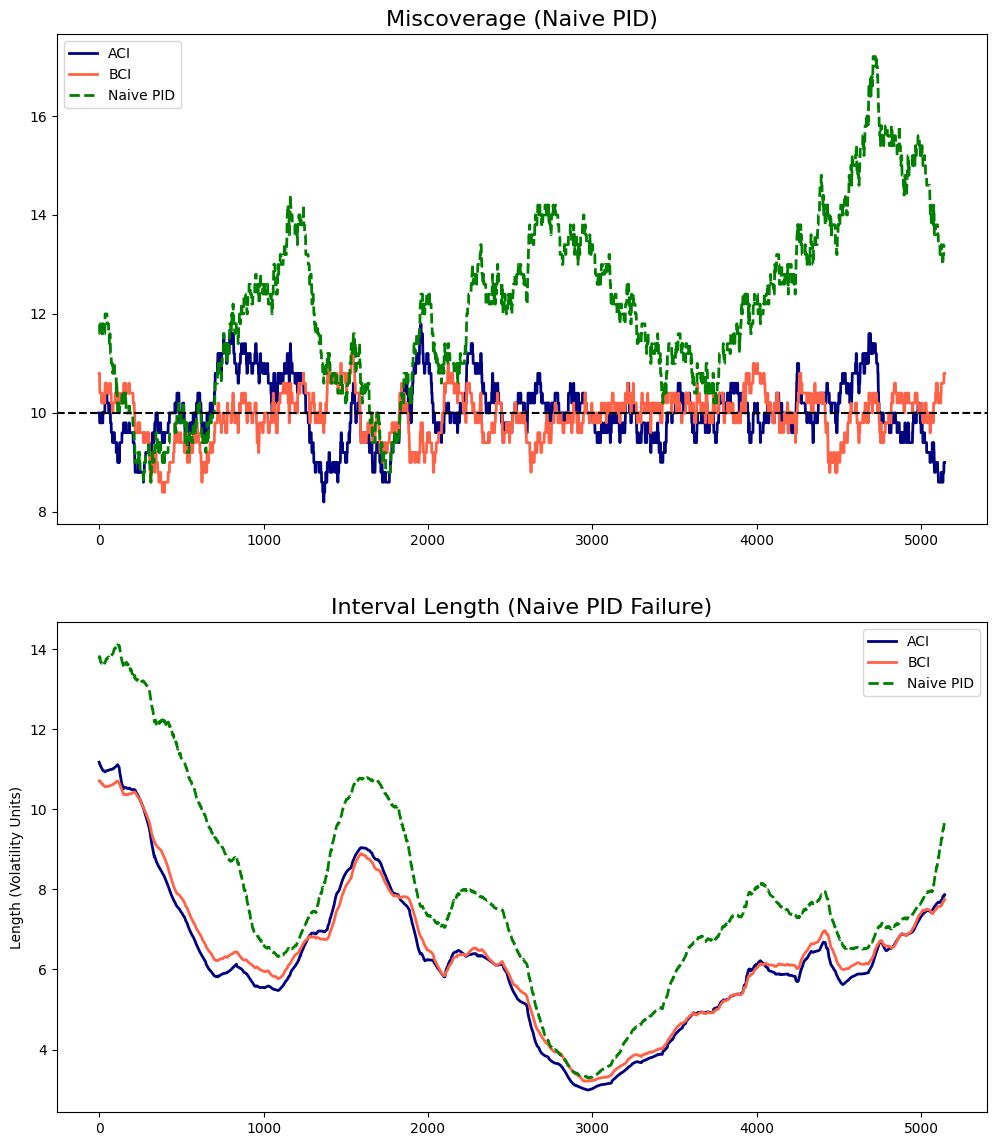

In [26]:
"""
FAILED EXPERIMENT: Nvidia Volatility (Naive PID)
------------------------------------------------
This script runs PID on RAW VARIANCE (no sqrt transform).
Purpose: To demonstrate to the professor why this fails.

Expectation:
- PID sees huge errors (variance scale).
- PID creates massive intervals.
- Lower bounds go negative (physically impossible).
- Intervals are huge compared to BCI.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def compute_metrics_failed_run(result_df):
    """
    Compute metrics for the FAILED run.
    We still try to measure length in sqrt-space to be fair to the baseline metric,
    but we will likely see garbage results.
    """
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    
    # 1. Miscoverage (alpha > beta)
    err_ind = (alpha > beta).astype(float)
    miscov = err_ind.mean()
    
    # 2. Length (Standard Volatility Unit Calculation)
    # We clip to 0 because naive PID often predicts negative variance (-500),
    # and sqrt(-500) would crash the script.
    safe_upper = np.maximum(upper, 0)
    safe_lower = np.maximum(lower, 0)
    
    raw_lengths = np.sqrt(safe_upper) - np.sqrt(safe_lower)
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]
    length = valid_lengths.mean() if len(valid_lengths) > 0 else 0.0
    
    return miscov, length

def run_pid_naive(scores, eta, csat, ki, y_pred_center, y_true):
    """
    Run Naive PID on RAW VARIANCE numbers.
    """
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        # Naive: Just add/subtract q from variance
        upper = y_pred_center + q
        lower = y_pred_center - q 
        
        # Check coverage (raw space)
        is_covered = (y_true >= lower) & (y_true <= upper)
        
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        return var, True, (q, upper, lower)
    except:
        return 1e10, False, None

def binary_search_naive(scores, y_pred_center, y_true, csat, ki, target_var):
    """Binary search on raw variance scores"""
    # Search range is much larger because variance numbers are huge
    eta_max = np.percentile(scores, 99) * 5 
    
    low, high = 1e-6, eta_max
    best_eta = low
    best_diff = 1e10
    best_result = None
    
    print(f"    Naive Search [0, {eta_max:.2f}]...", end=" ")
    
    for _ in range(20):
        mid = np.sqrt(low * high)
        var, valid, res = run_pid_naive(scores, mid, csat, ki, y_pred_center, y_true)
        
        if not valid:
            high = mid
            continue
            
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_result = res
        
        if var > target_var:
            low = mid
        else:
            high = mid
            
    print(f"Found η={best_eta:.4f}")
    
    pid_q, upper, lower = best_result
    return best_eta, (upper, lower)

# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    dataset_display = 'Nvidia'
    dataset_config = 'Nvidia' # Assuming you fixed the filename
    task = 'vlfc'
    gamma = 0.008 
    
    print(f"\n{'='*70}")
    print(f"FAILED EXPERIMENT: {dataset_display} (NAIVE PID)")
    print(f"Running PID on raw variance (No Sqrt Transform)")
    print(f"{'='*70}")
    
    # 1. Load Baselines
    print("Loading baselines...")
    try:
        exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset_config}.yaml'))
        exp_fixed.run()
        
        # Try finding BCI config
        try:
             exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci-{dataset_display}.yaml'))
             exp_bci.run()
        except:
             exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci-{dataset_config}.yaml'))
             exp_bci.run()
             
        # Load ACI
        aci_config = read_yaml(f'config/{task}-aci-{dataset_config}.yaml')
        aci_config['gamma'] = gamma
        exp_aci = ForecastingExperiment(aci_config)
        exp_aci.run()
        
    except Exception as e:
        print(f"Error: {e}")
        sys.exit()

    # 2. Get Targets (BCI)
    # We compute these correctly (with sqrt length) to establish the baseline
    alpha_bci = pd.to_numeric(exp_bci.result['alpha'], errors='coerce')
    beta_bci = pd.to_numeric(exp_bci.result['beta'], errors='coerce')
    err_bci = (alpha_bci > beta_bci).astype(float)
    bci_var = err_bci.rolling(50).mean().var()
    
    _, bci_len = compute_metrics_failed_run(exp_bci.result)
    
    print(f"Target BCI Variance: {bci_var:.2e}")
    print(f"Target BCI Length:   {bci_len:.4f}")

    # 3. Setup NAIVE PID (Raw Variance)
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    
    # RAW SCORES (No Sqrt)
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    ki = np.percentile(scores, 99)
    
    # 4. Run Search
    eta, intervals = binary_search_naive(scores, y_pred_center, y_true, csat, ki, bci_var)
    
    # 5. Create Result
    pid_upper, pid_lower = intervals
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = pid_upper
    df_pid['lower'] = pid_lower
    
    # Compute metrics for PID
    pid_miscov, pid_len = compute_metrics_failed_run(df_pid)
    
    print(f"\nRESULTS (Expect PID length to be broken/huge):")
    print(f"{'Method':<10} | {'Miscoverage':<15} | {'Length (Avg)':<15}")
    print("-" * 50)
    print(f"{'BCI':<10} | {err_bci.mean()*100:<15.2f} | {bci_len:<15.4f}")
    print(f"{'PID (Bad)':<10} | {pid_miscov*100:<15.2f} | {pid_len:<15.4f}")
    
    # 6. Plot
    print("\nGenerating Failed Plot...")
    fig, axs = plt.subplots(2, 1, figsize=(12, 14))
    
    def clean(df): 
        for c in ['upper','lower','true_y','alpha','beta']: 
            if c in df: df[c] = pd.to_numeric(df[c], errors='coerce')
        return df

    # Transform for plot: Sqrt(Clip(x, 0))
    # This ensures we can actually see the negative intervals (as 0) 
    # or the massive positive ones.
    xform = lambda x: np.sqrt(np.maximum(x, 0))

    ma = 250
    sk = 500
    
    p_aci = gen_plot_data(clean(exp_aci.result.copy()), ma, sk, xform)
    p_bci = gen_plot_data(clean(exp_bci.result.copy()), ma, sk, xform)
    p_pid = gen_plot_data(clean(df_pid.copy()), ma, sk, xform)
    
    # Plot Miscoverage
    axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI', linewidth=2)
    axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI', linewidth=2)
    axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', label='Naive PID', linewidth=2)
    axs[0].axhline(10, color='black', linestyle='--')
    axs[0].set_title('Miscoverage (Naive PID)', fontsize=16)
    axs[0].legend()
    
    # Plot Length
    axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=2)
    axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=2)
    axs[1].plot(p_pid['length'], color='green', linestyle='--', label='Naive PID', linewidth=2)
    axs[1].set_title('Interval Length (Naive PID Failure)', fontsize=16)
    axs[1].set_ylabel('Length (Volatility Units)')
    axs[1].legend()
    
    filename = 'Nvidia_FAILED_Naive_PID.png'
    plt.savefig(filename, dpi=300)
    print(f"Saved: {filename}")

In [ ]:
"""
Google: PID Targeting BCI Variance
Binary search η in [0, 5B] where B = 99th percentile
Creates 4-line plots: ACI, BCI, Fixed, PID
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def compute_metrics(result_df):
    """Compute variance, miscoverage, length"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')
    
    # Variance (alpha > beta)
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    
    # Miscoverage
    miscov = err_ind.mean()
    
    # Length
    raw_lengths = upper - lower
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]
    length = valid_lengths.mean() if len(valid_lengths) > 0 else 0.0
    
    return var, miscov, length


def run_pid_variance(scores, eta, csat, ki, y_pred_center, y_true):
    """Run PID and return variance"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper = y_pred_center + q
        lower = y_pred_center - q
        is_covered = (y_true >= lower) & (y_true <= upper)
        
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        return var, True, q
    except:
        return 1e10, False, None


def binary_search_5B(scores, y_pred_center, y_true, csat, ki, target_var):
    """Binary search in [0, 5B] to match target variance"""
    B = np.percentile(scores, 99)
    bound_5B = 5 * B
    
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = 1e10
    best_q = None
    
    print(f"    Binary search [0, {bound_5B:.4f}]...", end=" ")
    
    for _ in range(25):
        mid = np.sqrt(low * high)
        var, valid, q = run_pid_variance(scores, mid, csat, ki, y_pred_center, y_true)
        
        if not valid:
            high = mid
            continue
        
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_q = q
        
        if var > target_var:
            low = mid
        else:
            high = mid
    
    status = "Hit 5B Bound" if abs(best_eta - bound_5B) < 1e-4 else "Interior"
    print(f"η={best_eta:.4f} ({status})")
    
    return best_eta, best_q, bound_5B


def create_pid_df(exp_fixed, pid_q):
    """Create PID result dataframe"""
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + pid_q
    df_pid['lower'] = y_pred_center - pid_q
    df_pid['alpha'] = 0.1
    
    is_cov = (y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])
    df_pid['beta'] = is_cov.astype(int)
    
    return df_pid


# =============================================================================
# MAIN SCRIPT
# =============================================================================

if __name__ == "__main__":
    dataset = 'google_trends'
    task = 'trend'
    gammas = [0.1, 0.008]
    
    print(f"\n{'='*70}")
    print(f"Google trends: PID TARGETING BCI VARIANCE")
    print(f"{'='*70}")
    
    # Load baselines (only once since BCI doesn't change with gamma)
    print(f"\nLoading baselines...")
    exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed.yaml'))
    exp_fixed.run()
    
    exp_bci = ForecastingExperiment(read_yaml(f'config/{task}-bci.yaml'))
    exp_bci.run()
    
    # Get BCI metrics (target)
    bci_var, bci_miscov, bci_len = compute_metrics(exp_bci.result)
    fixed_var, fixed_miscov, fixed_len = compute_metrics(exp_fixed.result)
    
    print(f"BCI Variance (TARGET): {bci_var:.2e}")
    
    # Prepare PID data
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (upper + lower) / 2
    scores = np.abs(y_true - y_pred_center)
    
    T = len(scores)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    ki = np.percentile(scores, 99)
    
    print(f"K_I (99th %ile):       {ki:.4f}")
    
    # Binary search for PID (only once - same for both gammas)
    eta_found, pid_q, bound_5B = binary_search_5B(scores, y_pred_center, y_true, 
                                                   csat, ki, bci_var)
    
    # Create PID dataframe
    pid_df = create_pid_df(exp_fixed, pid_q)
    pid_var, pid_miscov, pid_len = compute_metrics(pid_df)
    
    print(f"PID Variance achieved: {pid_var:.2e}")
    print(f"Bound (5B):            {bound_5B:.4f}")
    
    # Now loop through gammas for ACI and plotting
    summary_data = []
    
    for gamma in gammas:
        print(f"\n{'-'*70}")
        print(f"γ = {gamma}")
        print(f"{'-'*70}")
        
        # Load ACI with this gamma
        aci_config = read_yaml(f'config/{task}-aci.yaml')
        aci_config['gamma'] = gamma
        exp_aci = ForecastingExperiment(aci_config)
        exp_aci.run()
        
        aci_var, aci_miscov, aci_len = compute_metrics(exp_aci.result)
        
        # Print summary table
        print(f"\nSUMMARY TABLE:")
        print(f"{'Method':<10} | {'Variance':<12} | {'Var vs BCI':<12} | {'Miscov(%)':<10} | {'Length':<10} | {'Len vs BCI':<12}")
        print("-" * 85)
        print(f"{'ACI':<10} | {aci_var:<12.2e} | {(aci_var/bci_var-1)*100:>11.1f}% | {aci_miscov*100:<10.2f} | {aci_len:<10.4f} | {(aci_len/bci_len-1)*100:>11.1f}%")
        print(f"{'BCI':<10} | {bci_var:<12.2e} | {'0.0%':>12} | {bci_miscov*100:<10.2f} | {bci_len:<10.4f} | {'0.0%':>12}")
        print(f"{'Fixed':<10} | {fixed_var:<12.2e} | {(fixed_var/bci_var-1)*100:>11.1f}% | {fixed_miscov*100:<10.2f} | {fixed_len:<10.4f} | {(fixed_len/bci_len-1)*100:>11.1f}%")
        print(f"{'PID':<10} | {pid_var:<12.2e} | {(pid_var/bci_var-1)*100:>11.1f}% | {pid_miscov*100:<10.2f} | {pid_len:<10.4f} | {(pid_len/bci_len-1)*100:>11.1f}%")
        print("-" * 85)
        
        # Create 4-line plot
        print(f"Creating visualization...")
        
        fig, axs = plt.subplots(2, 1, figsize=(12, 14))
        
        def clean_df(df):
            df['upper'] = pd.to_numeric(df['upper'], errors='coerce')
            df['lower'] = pd.to_numeric(df['lower'], errors='coerce')
            df['true_y'] = pd.to_numeric(df['true_y'], errors='coerce')
            return df
        
        ma_window = 250
        skip = 300
        xform = lambda x: x
        
        p_aci = gen_plot_data(clean_df(exp_aci.result), ma_window, skip, xform)
        p_bci = gen_plot_data(clean_df(exp_bci.result), ma_window, skip, xform)
        p_fix = gen_plot_data(clean_df(exp_fixed.result), ma_window, skip, xform)
        p_pid = gen_plot_data(clean_df(pid_df), ma_window, skip, xform)
        
        # Panel 1: Miscoverage
        axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI', linewidth=3)
        axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI', linewidth=3)
        axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=3)
        axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                    label=f'PID', linewidth=3)
        axs[0].axhline(10, color='black', linestyle='--')
        axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=20)
        axs[0].legend(loc='upper right', prop={'size': 18})
        axs[0].set_xticks(p_aci['indices'])
        axs[0].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30)
        
        # Panel 2: Length
        axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=3)
        axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=3)
        axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=3)
        axs[1].plot(p_pid['length'], color='green', label='PID', linewidth=3)
        axs[1].set_ylabel('Interval Length', fontsize=20)
        axs[1].legend(loc='upper right', prop={'size': 18})
        axs[1].set_xticks(p_aci['indices'])
        axs[1].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30)
        
        fig.suptitle(f'Return forecasting for {dataset} (γ={gamma})', fontsize=16)
        plt.tight_layout()
        
        filename = f'{dataset}_{task}_gamma{gamma}_PID_BCI_target.png'
        plt.savefig(filename, dpi=300)
        print(f"✓ Saved: {filename}")
        plt.close()
        
        # Collect summary
        summary_data.append({
            'gamma': gamma,
            'eta': eta_found,
            'bound_5B': bound_5B,
            'bci_var': bci_var,
            'pid_var': pid_var,
            'var_ratio': pid_var / bci_var,
            'bci_miscov': bci_miscov * 100,
            'pid_miscov': pid_miscov * 100,
            'bci_length': bci_len,
            'pid_length': pid_len
        })
    
    # Final summary
    print(f"\n{'='*70}")
    print(f"FINAL SUMMARY")
    print(f"{'='*70}")
    print(f"\n{'Gamma':<8} {'Eta':<10} {'Var (BCI)':<12} {'Var (PID)':<12} {'Var Ratio':<12} "
          f"{'Miscov BCI':<12} {'Miscov PID':<12} {'Length BCI':<12} {'Length PID':<12}")
    print("-" * 120)
    
    for row in summary_data:
        print(f"{row['gamma']:<8.3f} {row['eta']:<10.4f} {row['bci_var']:<12.2e} "
              f"{row['pid_var']:<12.2e} {row['var_ratio']:<12.3f} "
              f"{row['bci_miscov']:<12.2f} {row['pid_miscov']:<12.2f} "
              f"{row['bci_length']:<12.4f} {row['pid_length']:<12.4f}")
    
    print(f"\n{'='*70}")
    print("DONE!")
    print(f"{'='*70}")

2026-01-28 23:16:14,126 - INFO - Experiment trend-fixed-['statistics', 'deeplearning', 'iphone']-gamma_NA-lambda0_NA STARTED



Google trends: PID TARGETING BCI VARIANCE

Loading baselines...


2026-01-28 23:16:14,765 - INFO - Experiment trend-fixed-['statistics', 'deeplearning', 'iphone']-gamma_NA-lambda0_NA ENDED in 0.6386702060699463s
2026-01-28 23:16:14,772 - INFO - Experiment trend-bci-['statistics', 'deeplearning', 'iphone']-gamma_[545.56, 615.85, 695.19, 784.76, 885.87]-lambda0_[1000.0, 1128.84, 1274.27, 1438.45, 1623.78, 1832.98, 2069.14, 2335.72, 2636.65, 2976.35, 3359.82, 3792.69, 4281.33, 4832.93, 5455.59, 6158.48, 6951.93, 7847.6, 8858.67, 10000.0] STARTED


TypeError: '>' not supported between instances of 'int' and 'list'

In [14]:
"""
Volatility: PID Targeting BCI Variance
BCI parameters scale with gamma (like returns script)
Works in sqrt-transformed space
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

def compute_metrics(result_df):
    """Compute metrics in sqrt-transformed space"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')
    
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    miscov = err_ind.mean()
    
    # Length in sqrt space
    safe_upper = np.maximum(upper, 0)
    safe_lower = np.maximum(lower, 0)
    raw_lengths = np.sqrt(safe_upper) - np.sqrt(safe_lower)
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]
    length = valid_lengths.mean() if len(valid_lengths) > 0 else 0.0
    
    return var, miscov, length

def run_pid_variance(scores_sqrt, eta, csat, ki, y_pred_center_sqrt, y_true_sqrt):
    """Run PID in sqrt space"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores_sqrt, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper_sqrt = y_pred_center_sqrt + q
        lower_sqrt = np.maximum(y_pred_center_sqrt - q, 0)
        is_covered = (y_true_sqrt >= lower_sqrt) & (y_true_sqrt <= upper_sqrt)
        
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        upper_orig = upper_sqrt ** 2
        lower_orig = lower_sqrt ** 2
        
        return var, True, (q, upper_orig, lower_orig)
    except:
        return 1e10, False, None

def binary_search_5B(scores_sqrt, y_pred_center_sqrt, y_true_sqrt, csat, ki, target_var):
    """Binary search in [0, 5B]"""
    B = np.percentile(scores_sqrt, 99)
    bound_5B = 5 * B
    
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = 1e10
    best_result = None
    
    print(f"    Binary search [0, {bound_5B:.4f}]...", end=" ")
    
    for _ in range(30):
        mid = np.sqrt(low * high)
        var, valid, result = run_pid_variance(scores_sqrt, mid, csat, ki, 
                                               y_pred_center_sqrt, y_true_sqrt)
        
        if not valid:
            high = mid
            continue
        
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_result = result
        
        if var > target_var:
            low = mid
        else:
            high = mid
    
    status = "Hit 5B Bound" if abs(best_eta - bound_5B) < 1e-4 else "Interior"
    print(f"η={best_eta:.4f} ({status})")
    
    if best_result is None:
        return None, None, None, bound_5B
    
    pid_q, upper_orig, lower_orig = best_result
    return best_eta, pid_q, (upper_orig, lower_orig), bound_5B

def create_pid_df(exp_fixed, pid_intervals):
    """Create PID dataframe"""
    upper_orig, lower_orig = pid_intervals
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = upper_orig
    df_pid['lower'] = lower_orig
    df_pid['alpha'] = 0.1
    
    is_cov = (y_true >= lower_orig) & (y_true <= upper_orig)
    df_pid['beta'] = is_cov.astype(int)
    
    return df_pid

if __name__ == "__main__":
    dataset = 'Amazon'
    task = 'vlfc'
    gammas = [0.1, 0.008]
    
    print(f"\n{'='*70}")
    print(f"AMAZON VOLATILITY: PID TARGETING BCI VARIANCE")
    print(f"BCI parameters scale with gamma")
    print(f"{'='*70}")
    
    # Load Fixed once
    print(f"\nLoading Fixed baseline...")
    exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
    exp_fixed.run()
    
    fixed_var, fixed_miscov, fixed_len = compute_metrics(exp_fixed.result)
    
    # Prepare data in sqrt space
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    
    y_true_sqrt = np.sqrt(np.maximum(y_true, 0))
    upper_sqrt = np.sqrt(np.maximum(upper, 0))
    lower_sqrt = np.sqrt(np.maximum(lower, 0))
    y_pred_center_sqrt = (upper_sqrt + lower_sqrt) / 2
    scores_sqrt = np.abs(y_true_sqrt - y_pred_center_sqrt)
    
    T = len(scores_sqrt)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    ki = np.percentile(scores_sqrt, 99)
    
    print(f"K_I (99th %ile, √):    {ki:.4f}")
    
    # Loop through gammas
    summary_data = []
    
    for gamma in gammas:
        print(f"\n{'-'*70}")
        print(f"γ = {gamma}")
        print(f"{'-'*70}")
        
        # Load ACI
        print(f"  Loading ACI...")
        aci_config = read_yaml(f'config/{task}-aci-{dataset}.yaml')
        aci_config['gamma'] = gamma
        exp_aci = ForecastingExperiment(aci_config)
        exp_aci.run()
        
        # Load BCI and scale parameters
        print(f"  Loading BCI...")
        bci_config = read_yaml(f'config/{task}-bci-{dataset}.yaml')
        
        print(f"    BEFORE: gamma={bci_config['gamma']}, lambda_init={bci_config['lambda_init']}")
        
        if gamma == 0.008:
            bci_config['gamma'] = bci_config['gamma'] / 12.5
            bci_config['lambda_init'] = bci_config['lambda_init'] / 12.5
            print(f"    AFTER: gamma={bci_config['gamma']:.3f}, lambda_init={bci_config['lambda_init']:.3f}")
        
        exp_bci = ForecastingExperiment(bci_config)
        exp_bci.run()
        
        # Get metrics
        aci_var, aci_miscov, aci_len = compute_metrics(exp_aci.result)
        bci_var, bci_miscov, bci_len = compute_metrics(exp_bci.result)
        
        print(f"  BCI Variance (TARGET): {bci_var:.2e}")
        print(f"  ACI Variance (ref):    {aci_var:.2e}")
        
        # Binary search PID
        result = binary_search_5B(scores_sqrt, y_pred_center_sqrt, y_true_sqrt, 
                                  csat, ki, bci_var)
        
        if result[0] is None:
            print(f"  ✗ Binary search failed")
            continue
        
        eta_found, pid_q, pid_intervals, bound_5B = result
        
        # Create PID dataframe
        pid_df = create_pid_df(exp_fixed, pid_intervals)
        pid_var, pid_miscov, pid_len = compute_metrics(pid_df)
        
        print(f"  PID Variance achieved: {pid_var:.2e} (error: {abs(pid_var-bci_var)/bci_var*100:.1f}%)")
        print(f"  Bound (5B):            {bound_5B:.4f}")
        
        # Summary table
        print(f"\n  SUMMARY TABLE:")
        print(f"  {'Method':<10} | {'Variance':<12} | {'Var vs BCI':<12} | {'Miscov(%)':<10} | {'Length(√)':<10} | {'Len vs BCI':<12}")
        print(f"  {'-'*90}")
        print(f"  {'ACI':<10} | {aci_var:<12.2e} | {(aci_var/bci_var-1)*100:>11.1f}% | {aci_miscov*100:<10.2f} | {aci_len:<10.4f} | {(aci_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'BCI':<10} | {bci_var:<12.2e} | {'0.0%':>12} | {bci_miscov*100:<10.2f} | {bci_len:<10.4f} | {'0.0%':>12}")
        print(f"  {'Fixed':<10} | {fixed_var:<12.2e} | {(fixed_var/bci_var-1)*100:>11.1f}% | {fixed_miscov*100:<10.2f} | {fixed_len:<10.4f} | {(fixed_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'PID':<10} | {pid_var:<12.2e} | {(pid_var/bci_var-1)*100:>11.1f}% | {pid_miscov*100:<10.2f} | {pid_len:<10.4f} | {(pid_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'-'*90}")
        
        # Visualization
        print(f"  Creating visualization...")
        fig, axs = plt.subplots(2, 1, figsize=(10, 15))
        
        def clean_df(df):
            for col in ['upper', 'lower', 'true_y']:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')
            return df
        
        ma_window = 250
        skip = 500
        xform = lambda x: np.sqrt(np.maximum(x, 0))
        
        p_aci = gen_plot_data(clean_df(exp_aci.result.copy()), ma_window, skip, xform)
        p_bci = gen_plot_data(clean_df(exp_bci.result.copy()), ma_window, skip, xform)
        p_fix = gen_plot_data(clean_df(exp_fixed.result.copy()), ma_window, skip, xform)
        p_pid = gen_plot_data(clean_df(pid_df.copy()), ma_window, skip, xform)
        
        # Panel 1
        axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI', linewidth=3)
        axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI', linewidth=3)
        axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=3)
        axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                    label=f'PID', linewidth=3)
        axs[0].axhline(10, color='black', linestyle='--')
        axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=25)
        axs[0].legend(loc='upper right', prop={'size': 20})
        axs[0].set_xticks(p_aci['indices'])
        axs[0].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)
        
        for label in axs[0].get_yticklabels():
            label.set_fontsize(20)
        
        # Panel 2
        axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=3)
        axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=3)
        axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=3)
        axs[1].plot(p_pid['length'], color='green', label='PID', linewidth=3)
        axs[1].set_ylabel('Interval Length', fontsize=25)
        axs[1].legend(loc='upper right', prop={'size': 20})
        axs[1].set_xticks(p_aci['indices'])
        axs[1].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)
        
        for label in axs[1].get_yticklabels():
            label.set_fontsize(20)
        
        fig.suptitle(f'Volatility forecasting for {dataset} (γ={gamma})', fontsize=30, y=1.0005)
        plt.tight_layout()
        
        filename = f'{dataset}_{task}_gamma{gamma}_PID_BCI_target.png'
        plt.savefig(filename, dpi=300)
        print(f"  ✓ Saved: {filename}")
        plt.close()
        
        # Collect summary
        summary_data.append({
            'gamma': gamma,
            'eta': eta_found,
            'bound_5B': bound_5B,
            'bci_var': bci_var,
            'pid_var': pid_var,
            'var_ratio': pid_var / bci_var,
            'bci_miscov': bci_miscov * 100,
            'pid_miscov': pid_miscov * 100,
            'bci_length': bci_len,
            'pid_length': pid_len
        })
    
    # Final summary
    print(f"\n{'='*70}")
    print(f"FINAL SUMMARY")
    print(f"{'='*70}")
    print(f"\n{'Gamma':<8} {'Eta':<10} {'Var (BCI)':<12} {'Var (PID)':<12} {'Var Ratio':<12} "
          f"{'Miscov BCI':<12} {'Miscov PID':<12} {'Length BCI':<12} {'Length PID':<12}")
    print("-" * 120)
    
    for row in summary_data:
        print(f"{row['gamma']:<8.3f} {row['eta']:<10.4f} {row['bci_var']:<12.2e} "
              f"{row['pid_var']:<12.2e} {row['var_ratio']:<12.3f} "
              f"{row['bci_miscov']:<12.2f} {row['pid_miscov']:<12.2f} "
              f"{row['bci_length']:<12.4f} {row['pid_length']:<12.4f}")
    
    print(f"\n{'='*70}")
    print("DONE!")
    print(f"{'='*70}")

2026-01-29 02:07:31,792 - INFO - Experiment vlfc-fixed-Amazon-gamma_NA-lambda0_NA STARTED



AMAZON VOLATILITY: PID TARGETING BCI VARIANCE
BCI parameters scale with gamma

Loading Fixed baseline...


2026-01-29 02:07:36,945 - INFO - Experiment vlfc-fixed-Amazon-gamma_NA-lambda0_NA ENDED in 5.153250217437744s
2026-01-29 02:07:36,964 - INFO - Experiment vlfc-aci-Amazon-gamma_0.1-lambda0_0.9 STARTED


K_I (99th %ile, √):    9.6848

----------------------------------------------------------------------
γ = 0.1
----------------------------------------------------------------------
  Loading ACI...


2026-01-29 02:07:42,333 - INFO - Experiment vlfc-aci-Amazon-gamma_0.1-lambda0_0.9 ENDED in 5.369179964065552s
2026-01-29 02:07:42,345 - INFO - Experiment vlfc-bci-Amazon-gamma_490-lambda0_800 STARTED


...

  Loading BCI...
    BEFORE: gamma=490, lambda_init=800
    AFTER: gamma=39.200, lambda_init=64.000


2026-01-29 02:08:58,502 - INFO - Experiment vlfc-bci-Amazon-gamma_39.2-lambda0_64.0 ENDED in 32.725446939468384s


  BCI Variance (TARGET): 7.65e-03
  ACI Variance (ref):    1.66e-03
    Binary search [0, 48.4238]... 

100%|██████████| 6426/6426 [00:00<00:00, 183055.87it/s]


η=0.0037 (Interior)
  PID Variance achieved: 7.65e-03 (error: 0.1%)
  Bound (5B):            48.4238

  SUMMARY TABLE:
  Method     | Variance     | Var vs BCI   | Miscov(%)  | Length(√)  | Len vs BCI  
  ------------------------------------------------------------------------------------------
  ACI        | 1.66e-03     |       -78.2% | 10.02      | 6.0780     |         3.6%
  BCI        | 7.65e-03     |         0.0% | 10.24      | 5.8643     |         0.0%
  Fixed      | 2.11e-03     |       -72.4% | 11.24      | 5.8222     |        -0.7%
  PID        | 7.65e-03     |         0.1% | 10.22      | 5.9595     |         1.6%
  ------------------------------------------------------------------------------------------
  Creating visualization...
  ✓ Saved: Amazon_vlfc_gamma0.008_PID_BCI_target.png

FINAL SUMMARY

Gamma    Eta        Var (BCI)    Var (PID)    Var Ratio    Miscov BCI   Miscov PID   Length BCI   Length PID  
-------------------------------------------------------------------

In [12]:
"""
Volatility: PID Targeting BCI Variance
BCI parameters scale with gamma (like returns script)
Works in sqrt-transformed space
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

def compute_metrics(result_df):
    """Compute metrics in sqrt-transformed space"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')
    
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    miscov = err_ind.mean()
    
    # Length in sqrt space
    safe_upper = np.maximum(upper, 0)
    safe_lower = np.maximum(lower, 0)
    raw_lengths = np.sqrt(safe_upper) - np.sqrt(safe_lower)
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]
    length = valid_lengths.mean() if len(valid_lengths) > 0 else 0.0
    
    return var, miscov, length

def run_pid_variance(scores_sqrt, eta, csat, ki, y_pred_center_sqrt, y_true_sqrt):
    """Run PID in sqrt space"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores_sqrt, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper_sqrt = y_pred_center_sqrt + q
        lower_sqrt = np.maximum(y_pred_center_sqrt - q, 0)
        is_covered = (y_true_sqrt >= lower_sqrt) & (y_true_sqrt <= upper_sqrt)
        
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        upper_orig = upper_sqrt ** 2
        lower_orig = lower_sqrt ** 2
        
        return var, True, (q, upper_orig, lower_orig)
    except:
        return 1e10, False, None

def binary_search_5B(scores_sqrt, y_pred_center_sqrt, y_true_sqrt, csat, ki, target_var):
    """Binary search in [0, 5B]"""
    B = np.percentile(scores_sqrt, 99)
    bound_5B = 5 * B
    
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = 1e10
    best_result = None
    
    print(f"    Binary search [0, {bound_5B:.4f}]...", end=" ")
    
    for _ in range(30):
        mid = np.sqrt(low * high)
        var, valid, result = run_pid_variance(scores_sqrt, mid, csat, ki, 
                                               y_pred_center_sqrt, y_true_sqrt)
        
        if not valid:
            high = mid
            continue
        
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_result = result
        
        if var > target_var:
            low = mid
        else:
            high = mid
    
    status = "Hit 5B Bound" if abs(best_eta - bound_5B) < 1e-4 else "Interior"
    print(f"η={best_eta:.4f} ({status})")
    
    if best_result is None:
        return None, None, None, bound_5B
    
    pid_q, upper_orig, lower_orig = best_result
    return best_eta, pid_q, (upper_orig, lower_orig), bound_5B

def create_pid_df(exp_fixed, pid_intervals):
    """Create PID dataframe"""
    upper_orig, lower_orig = pid_intervals
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = upper_orig
    df_pid['lower'] = lower_orig
    df_pid['alpha'] = 0.1
    
    is_cov = (y_true >= lower_orig) & (y_true <= upper_orig)
    df_pid['beta'] = is_cov.astype(int)
    
    return df_pid

if __name__ == "__main__":
    dataset = 'AMD'
    task = 'vlfc'
    gammas = [0.1, 0.008]
    
    print(f"\n{'='*70}")
    print(f"AMAZON VOLATILITY: PID TARGETING BCI VARIANCE")
    print(f"BCI parameters scale with gamma")
    print(f"{'='*70}")
    
    # Load Fixed once
    print(f"\nLoading Fixed baseline...")
    exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
    exp_fixed.run()
    
    fixed_var, fixed_miscov, fixed_len = compute_metrics(exp_fixed.result)
    
    # Prepare data in sqrt space
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    
    y_true_sqrt = np.sqrt(np.maximum(y_true, 0))
    upper_sqrt = np.sqrt(np.maximum(upper, 0))
    lower_sqrt = np.sqrt(np.maximum(lower, 0))
    y_pred_center_sqrt = (upper_sqrt + lower_sqrt) / 2
    scores_sqrt = np.abs(y_true_sqrt - y_pred_center_sqrt)
    
    T = len(scores_sqrt)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    ki = np.percentile(scores_sqrt, 99)
    
    print(f"K_I (99th %ile, √):    {ki:.4f}")
    
    # Loop through gammas
    summary_data = []
    
    for gamma in gammas:
        print(f"\n{'-'*70}")
        print(f"γ = {gamma}")
        print(f"{'-'*70}")
        
        # Load ACI
        print(f"  Loading ACI...")
        aci_config = read_yaml(f'config/{task}-aci-{dataset}.yaml')
        aci_config['gamma'] = gamma
        exp_aci = ForecastingExperiment(aci_config)
        exp_aci.run()
        
        # Load BCI and scale parameters
        print(f"  Loading BCI...")
        bci_config = read_yaml(f'config/{task}-bci-{dataset}.yaml')
        
        print(f"    BEFORE: gamma={bci_config['gamma']}, lambda_init={bci_config['lambda_init']}")
        
        if gamma == 0.008:
            bci_config['gamma'] = bci_config['gamma'] / 12.5
            bci_config['lambda_init'] = bci_config['lambda_init'] / 12.5
            print(f"    AFTER: gamma={bci_config['gamma']:.3f}, lambda_init={bci_config['lambda_init']:.3f}")
        
        exp_bci = ForecastingExperiment(bci_config)
        exp_bci.run()
        
        # Get metrics
        aci_var, aci_miscov, aci_len = compute_metrics(exp_aci.result)
        bci_var, bci_miscov, bci_len = compute_metrics(exp_bci.result)
        
        print(f"  BCI Variance (TARGET): {bci_var:.2e}")
        print(f"  ACI Variance (ref):    {aci_var:.2e}")
        
        # Binary search PID
        result = binary_search_5B(scores_sqrt, y_pred_center_sqrt, y_true_sqrt, 
                                  csat, ki, bci_var)
        
        if result[0] is None:
            print(f"  ✗ Binary search failed")
            continue
        
        eta_found, pid_q, pid_intervals, bound_5B = result
        
        # Create PID dataframe
        pid_df = create_pid_df(exp_fixed, pid_intervals)
        pid_var, pid_miscov, pid_len = compute_metrics(pid_df)
        
        print(f"  PID Variance achieved: {pid_var:.2e} (error: {abs(pid_var-bci_var)/bci_var*100:.1f}%)")
        print(f"  Bound (5B):            {bound_5B:.4f}")
        
        # Summary table
        print(f"\n  SUMMARY TABLE:")
        print(f"  {'Method':<10} | {'Variance':<12} | {'Var vs BCI':<12} | {'Miscov(%)':<10} | {'Length(√)':<10} | {'Len vs BCI':<12}")
        print(f"  {'-'*90}")
        print(f"  {'ACI':<10} | {aci_var:<12.2e} | {(aci_var/bci_var-1)*100:>11.1f}% | {aci_miscov*100:<10.2f} | {aci_len:<10.4f} | {(aci_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'BCI':<10} | {bci_var:<12.2e} | {'0.0%':>12} | {bci_miscov*100:<10.2f} | {bci_len:<10.4f} | {'0.0%':>12}")
        print(f"  {'Fixed':<10} | {fixed_var:<12.2e} | {(fixed_var/bci_var-1)*100:>11.1f}% | {fixed_miscov*100:<10.2f} | {fixed_len:<10.4f} | {(fixed_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'PID':<10} | {pid_var:<12.2e} | {(pid_var/bci_var-1)*100:>11.1f}% | {pid_miscov*100:<10.2f} | {pid_len:<10.4f} | {(pid_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'-'*90}")
        
        # Visualization
        print(f"  Creating visualization...")
        fig, axs = plt.subplots(2, 1, figsize=(10, 15))
        
        def clean_df(df):
            for col in ['upper', 'lower', 'true_y']:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')
            return df
        
        ma_window = 250
        skip = 500
        xform = lambda x: np.sqrt(np.maximum(x, 0))
        
        p_aci = gen_plot_data(clean_df(exp_aci.result.copy()), ma_window, skip, xform)
        p_bci = gen_plot_data(clean_df(exp_bci.result.copy()), ma_window, skip, xform)
        p_fix = gen_plot_data(clean_df(exp_fixed.result.copy()), ma_window, skip, xform)
        p_pid = gen_plot_data(clean_df(pid_df.copy()), ma_window, skip, xform)
        
        # Panel 1
        axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI', linewidth=3)
        axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI', linewidth=3)
        axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=3)
        axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                    label=f'PID', linewidth=3)
        axs[0].axhline(10, color='black', linestyle='--')
        axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=25)
        axs[0].legend(loc='upper right', prop={'size': 20})
        axs[0].set_xticks(p_aci['indices'])
        axs[0].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)
        
        for label in axs[0].get_yticklabels():
            label.set_fontsize(20)
        
        # Panel 2
        axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=3)
        axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=3)
        axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=3)
        axs[1].plot(p_pid['length'], color='green', label='PID', linewidth=3)
        axs[1].set_ylabel('Interval Length', fontsize=25)
        axs[1].legend(loc='upper right', prop={'size': 20})
        axs[1].set_xticks(p_aci['indices'])
        axs[1].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)
        
        for label in axs[1].get_yticklabels():
            label.set_fontsize(20)
        
        fig.suptitle(f'Volatility forecasting for {dataset} (γ={gamma})', fontsize=30, y=1.0005)
        plt.tight_layout()
        
        filename = f'{dataset}_{task}_gamma{gamma}_PID_BCI_target.png'
        plt.savefig(filename, dpi=300)
        print(f"  ✓ Saved: {filename}")
        plt.close()
        
        # Collect summary
        summary_data.append({
            'gamma': gamma,
            'eta': eta_found,
            'bound_5B': bound_5B,
            'bci_var': bci_var,
            'pid_var': pid_var,
            'var_ratio': pid_var / bci_var,
            'bci_miscov': bci_miscov * 100,
            'pid_miscov': pid_miscov * 100,
            'bci_length': bci_len,
            'pid_length': pid_len
        })
    
    # Final summary
    print(f"\n{'='*70}")
    print(f"FINAL SUMMARY")
    print(f"{'='*70}")
    print(f"\n{'Gamma':<8} {'Eta':<10} {'Var (BCI)':<12} {'Var (PID)':<12} {'Var Ratio':<12} "
          f"{'Miscov BCI':<12} {'Miscov PID':<12} {'Length BCI':<12} {'Length PID':<12}")
    print("-" * 120)
    
    for row in summary_data:
        print(f"{row['gamma']:<8.3f} {row['eta']:<10.4f} {row['bci_var']:<12.2e} "
              f"{row['pid_var']:<12.2e} {row['var_ratio']:<12.3f} "
              f"{row['bci_miscov']:<12.2f} {row['pid_miscov']:<12.2f} "
              f"{row['bci_length']:<12.4f} {row['pid_length']:<12.4f}")
    
    print(f"\n{'='*70}")
    print("DONE!")
    print(f"{'='*70}")

2026-01-29 02:01:58,551 - INFO - Experiment vlfc-fixed-AMD-gamma_NA-lambda0_NA STARTED



AMAZON VOLATILITY: PID TARGETING BCI VARIANCE
BCI parameters scale with gamma

Loading Fixed baseline...


2026-01-29 02:02:03,049 - INFO - Experiment vlfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 4.498391151428223s
2026-01-29 02:02:03,064 - INFO - Experiment vlfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED


K_I (99th %ile, √):    8.8262

----------------------------------------------------------------------
γ = 0.1
----------------------------------------------------------------------
  Loading ACI...


2026-01-29 02:02:07,827 - INFO - Experiment vlfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 4.763217926025391s
2026-01-29 02:02:07,837 - INFO - Experiment vlfc-bci-AMD-gamma_2100.0-lambda0_3300.0 STARTED


...

  Loading BCI...
    BEFORE: gamma=2100.0, lambda_init=3300.0
    AFTER: gamma=168.000, lambda_init=264.000


2026-01-29 02:03:11,636 - INFO - Experiment vlfc-bci-AMD-gamma_168.0-lambda0_264.0 ENDED in 27.262757778167725s


  BCI Variance (TARGET): 4.42e-03
  ACI Variance (ref):    1.81e-03
    Binary search [0, 44.1312]... 

100%|██████████| 5394/5394 [00:00<00:00, 86324.75it/s]


η=0.0210 (Interior)
  PID Variance achieved: 4.37e-03 (error: 1.0%)
  Bound (5B):            44.1312

  SUMMARY TABLE:
  Method     | Variance     | Var vs BCI   | Miscov(%)  | Length(√)  | Len vs BCI  
  ------------------------------------------------------------------------------------------
  ACI        | 1.81e-03     |       -59.1% | 10.09      | 7.7248     |         2.8%
  BCI        | 4.42e-03     |         0.0% | 10.10      | 7.5152     |         0.0%
  Fixed      | 2.30e-03     |       -47.9% | 12.68      | 6.9961     |        -6.9%
  PID        | 4.37e-03     |        -1.0% | 10.42      | 7.3357     |        -2.4%
  ------------------------------------------------------------------------------------------
  Creating visualization...
  ✓ Saved: AMD_vlfc_gamma0.008_PID_BCI_target.png

FINAL SUMMARY

Gamma    Eta        Var (BCI)    Var (PID)    Var Ratio    Miscov BCI   Miscov PID   Length BCI   Length PID  
----------------------------------------------------------------------

In [13]:
"""
Volatility: PID Targeting BCI Variance
BCI parameters scale with gamma (like returns script)
Works in sqrt-transformed space
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

def compute_metrics(result_df):
    """Compute metrics in sqrt-transformed space"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta = pd.to_numeric(result_df['beta'], errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')
    
    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    var = local_miscov.var()
    miscov = err_ind.mean()
    
    # Length in sqrt space
    safe_upper = np.maximum(upper, 0)
    safe_lower = np.maximum(lower, 0)
    raw_lengths = np.sqrt(safe_upper) - np.sqrt(safe_lower)
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]
    length = valid_lengths.mean() if len(valid_lengths) > 0 else 0.0
    
    return var, miscov, length

def run_pid_variance(scores_sqrt, eta, csat, ki, y_pred_center_sqrt, y_true_sqrt):
    """Run PID in sqrt space"""
    try:
        pid_out = quantile_integrator_log(
            scores=scores_sqrt, alpha=0.1, lr=eta,
            Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        upper_sqrt = y_pred_center_sqrt + q
        lower_sqrt = np.maximum(y_pred_center_sqrt - q, 0)
        is_covered = (y_true_sqrt >= lower_sqrt) & (y_true_sqrt <= upper_sqrt)
        
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        
        upper_orig = upper_sqrt ** 2
        lower_orig = lower_sqrt ** 2
        
        return var, True, (q, upper_orig, lower_orig)
    except:
        return 1e10, False, None

def binary_search_5B(scores_sqrt, y_pred_center_sqrt, y_true_sqrt, csat, ki, target_var):
    """Binary search in [0, 5B]"""
    B = np.percentile(scores_sqrt, 99)
    bound_5B = 5 * B
    
    low, high = 1e-6, bound_5B
    best_eta = low
    best_diff = 1e10
    best_result = None
    
    print(f"    Binary search [0, {bound_5B:.4f}]...", end=" ")
    
    for _ in range(30):
        mid = np.sqrt(low * high)
        var, valid, result = run_pid_variance(scores_sqrt, mid, csat, ki, 
                                               y_pred_center_sqrt, y_true_sqrt)
        
        if not valid:
            high = mid
            continue
        
        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff = diff
            best_eta = mid
            best_result = result
        
        if var > target_var:
            low = mid
        else:
            high = mid
    
    status = "Hit 5B Bound" if abs(best_eta - bound_5B) < 1e-4 else "Interior"
    print(f"η={best_eta:.4f} ({status})")
    
    if best_result is None:
        return None, None, None, bound_5B
    
    pid_q, upper_orig, lower_orig = best_result
    return best_eta, pid_q, (upper_orig, lower_orig), bound_5B

def create_pid_df(exp_fixed, pid_intervals):
    """Create PID dataframe"""
    upper_orig, lower_orig = pid_intervals
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = upper_orig
    df_pid['lower'] = lower_orig
    df_pid['alpha'] = 0.1
    
    is_cov = (y_true >= lower_orig) & (y_true <= upper_orig)
    df_pid['beta'] = is_cov.astype(int)
    
    return df_pid

if __name__ == "__main__":
    dataset = 'NVIDIA'
    task = 'vlfc'
    gammas = [0.1, 0.008]
    
    print(f"\n{'='*70}")
    print(f"NVIDIA VOLATILITY: PID TARGETING BCI VARIANCE")
    print(f"BCI parameters scale with gamma")
    print(f"{'='*70}")
    
    # Load Fixed once
    print(f"\nLoading Fixed baseline...")
    exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
    exp_fixed.run()
    
    fixed_var, fixed_miscov, fixed_len = compute_metrics(exp_fixed.result)
    
    # Prepare data in sqrt space
    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    lower = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    
    y_true_sqrt = np.sqrt(np.maximum(y_true, 0))
    upper_sqrt = np.sqrt(np.maximum(upper, 0))
    lower_sqrt = np.sqrt(np.maximum(lower, 0))
    y_pred_center_sqrt = (upper_sqrt + lower_sqrt) / 2
    scores_sqrt = np.abs(y_true_sqrt - y_pred_center_sqrt)
    
    T = len(scores_sqrt)
    csat = max((2 / np.pi) * (np.ceil(np.log(T) * 0.05) - 1 / np.log(T)), 0.1)
    ki = np.percentile(scores_sqrt, 99)
    
    print(f"K_I (99th %ile, √):    {ki:.4f}")
    
    # Loop through gammas
    summary_data = []
    
    for gamma in gammas:
        print(f"\n{'-'*70}")
        print(f"γ = {gamma}")
        print(f"{'-'*70}")
        
        # Load ACI
        print(f"  Loading ACI...")
        aci_config = read_yaml(f'config/{task}-aci-{dataset}.yaml')
        aci_config['gamma'] = gamma
        exp_aci = ForecastingExperiment(aci_config)
        exp_aci.run()
        
        # Load BCI and scale parameters
        print(f"  Loading BCI...")
        bci_config = read_yaml(f'config/{task}-bci-{dataset}.yaml')
        
        print(f"    BEFORE: gamma={bci_config['gamma']}, lambda_init={bci_config['lambda_init']}")
        
        if gamma == 0.008:
            bci_config['gamma'] = bci_config['gamma'] / 12.5
            bci_config['lambda_init'] = bci_config['lambda_init'] / 12.5
            print(f"    AFTER: gamma={bci_config['gamma']:.3f}, lambda_init={bci_config['lambda_init']:.3f}")
        
        exp_bci = ForecastingExperiment(bci_config)
        exp_bci.run()
        
        # Get metrics
        aci_var, aci_miscov, aci_len = compute_metrics(exp_aci.result)
        bci_var, bci_miscov, bci_len = compute_metrics(exp_bci.result)
        
        print(f"  BCI Variance (TARGET): {bci_var:.2e}")
        print(f"  ACI Variance (ref):    {aci_var:.2e}")
        
        # Binary search PID
        result = binary_search_5B(scores_sqrt, y_pred_center_sqrt, y_true_sqrt, 
                                  csat, ki, bci_var)
        
        if result[0] is None:
            print(f"  ✗ Binary search failed")
            continue
        
        eta_found, pid_q, pid_intervals, bound_5B = result
        
        # Create PID dataframe
        pid_df = create_pid_df(exp_fixed, pid_intervals)
        pid_var, pid_miscov, pid_len = compute_metrics(pid_df)
        
        print(f"  PID Variance achieved: {pid_var:.2e} (error: {abs(pid_var-bci_var)/bci_var*100:.1f}%)")
        print(f"  Bound (5B):            {bound_5B:.4f}")
        
        # Summary table
        print(f"\n  SUMMARY TABLE:")
        print(f"  {'Method':<10} | {'Variance':<12} | {'Var vs BCI':<12} | {'Miscov(%)':<10} | {'Length(√)':<10} | {'Len vs BCI':<12}")
        print(f"  {'-'*90}")
        print(f"  {'ACI':<10} | {aci_var:<12.2e} | {(aci_var/bci_var-1)*100:>11.1f}% | {aci_miscov*100:<10.2f} | {aci_len:<10.4f} | {(aci_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'BCI':<10} | {bci_var:<12.2e} | {'0.0%':>12} | {bci_miscov*100:<10.2f} | {bci_len:<10.4f} | {'0.0%':>12}")
        print(f"  {'Fixed':<10} | {fixed_var:<12.2e} | {(fixed_var/bci_var-1)*100:>11.1f}% | {fixed_miscov*100:<10.2f} | {fixed_len:<10.4f} | {(fixed_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'PID':<10} | {pid_var:<12.2e} | {(pid_var/bci_var-1)*100:>11.1f}% | {pid_miscov*100:<10.2f} | {pid_len:<10.4f} | {(pid_len/bci_len-1)*100:>11.1f}%")
        print(f"  {'-'*90}")
        
        # Visualization
        print(f"  Creating visualization...")
        fig, axs = plt.subplots(2, 1, figsize=(10, 15))
        
        def clean_df(df):
            for col in ['upper', 'lower', 'true_y']:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')
            return df
        
        ma_window = 250
        skip = 500
        xform = lambda x: np.sqrt(np.maximum(x, 0))
        
        p_aci = gen_plot_data(clean_df(exp_aci.result.copy()), ma_window, skip, xform)
        p_bci = gen_plot_data(clean_df(exp_bci.result.copy()), ma_window, skip, xform)
        p_fix = gen_plot_data(clean_df(exp_fixed.result.copy()), ma_window, skip, xform)
        p_pid = gen_plot_data(clean_df(pid_df.copy()), ma_window, skip, xform)
        
        # Panel 1
        axs[0].plot(100*p_aci['miscovrate'], color='navy', label='ACI', linewidth=3)
        axs[0].plot(100*p_bci['miscovrate'], color='tomato', label='BCI', linewidth=3)
        axs[0].plot(100*p_fix['miscovrate'], color='silver', label='Fixed', linewidth=3)
        axs[0].plot(100*p_pid['miscovrate'], color='green', linestyle='--', 
                    label=f'PID', linewidth=3)
        axs[0].axhline(10, color='black', linestyle='--')
        axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=25)
        axs[0].legend(loc='upper right', prop={'size': 20})
        axs[0].set_xticks(p_aci['indices'])
        axs[0].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)
        
        for label in axs[0].get_yticklabels():
            label.set_fontsize(20)
        
        # Panel 2
        axs[1].plot(p_aci['length'], color='navy', label='ACI', linewidth=3)
        axs[1].plot(p_bci['length'], color='tomato', label='BCI', linewidth=3)
        axs[1].plot(p_fix['length'], color='silver', label='Fixed', linewidth=3)
        axs[1].plot(p_pid['length'], color='green', label='PID', linewidth=3)
        axs[1].set_ylabel('Interval Length', fontsize=25)
        axs[1].legend(loc='upper right', prop={'size': 20})
        axs[1].set_xticks(p_aci['indices'])
        axs[1].set_xticklabels([p_aci['date_indices'][i] for i in p_aci['indices']], rotation=30, fontsize=20)
        
        for label in axs[1].get_yticklabels():
            label.set_fontsize(20)
        
        fig.suptitle(f'Volatility forecasting for {dataset} (γ={gamma})', fontsize=30, y=1.0005)
        plt.tight_layout()
        
        filename = f'{dataset}_{task}_gamma{gamma}_PID_BCI_target.png'
        plt.savefig(filename, dpi=300)
        print(f"  ✓ Saved: {filename}")
        plt.close()
        
        # Collect summary
        summary_data.append({
            'gamma': gamma,
            'eta': eta_found,
            'bound_5B': bound_5B,
            'bci_var': bci_var,
            'pid_var': pid_var,
            'var_ratio': pid_var / bci_var,
            'bci_miscov': bci_miscov * 100,
            'pid_miscov': pid_miscov * 100,
            'bci_length': bci_len,
            'pid_length': pid_len
        })
    
    # Final summary
    print(f"\n{'='*70}")
    print(f"FINAL SUMMARY")
    print(f"{'='*70}")
    print(f"\n{'Gamma':<8} {'Eta':<10} {'Var (BCI)':<12} {'Var (PID)':<12} {'Var Ratio':<12} "
          f"{'Miscov BCI':<12} {'Miscov PID':<12} {'Length BCI':<12} {'Length PID':<12}")
    print("-" * 120)
    
    for row in summary_data:
        print(f"{row['gamma']:<8.3f} {row['eta']:<10.4f} {row['bci_var']:<12.2e} "
              f"{row['pid_var']:<12.2e} {row['var_ratio']:<12.3f} "
              f"{row['bci_miscov']:<12.2f} {row['pid_miscov']:<12.2f} "
              f"{row['bci_length']:<12.4f} {row['pid_length']:<12.4f}")
    
    print(f"\n{'='*70}")
    print("DONE!")
    print(f"{'='*70}")

2026-01-29 02:03:15,732 - INFO - Experiment vlfc-fixed-Nvidia-gamma_NA-lambda0_NA STARTED



NVIDIA VOLATILITY: PID TARGETING BCI VARIANCE
BCI parameters scale with gamma

Loading Fixed baseline...


2026-01-29 02:03:20,354 - INFO - Experiment vlfc-fixed-Nvidia-gamma_NA-lambda0_NA ENDED in 4.622896909713745s
2026-01-29 02:03:20,371 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.1-lambda0_0.9 STARTED


K_I (99th %ile, √):    7.8460

----------------------------------------------------------------------
γ = 0.1
----------------------------------------------------------------------
  Loading ACI...


2026-01-29 02:03:25,115 - INFO - Experiment vlfc-aci-Nvidia-gamma_0.1-lambda0_0.9 ENDED in 4.744153022766113s
2026-01-29 02:03:25,125 - INFO - Experiment vlfc-bci-Nvidia-gamma_490.0-lambda0_800.0 STARTED


...

  Loading BCI...
    BEFORE: gamma=490.0, lambda_init=800.0
    AFTER: gamma=39.200, lambda_init=64.000


2026-01-29 02:04:31,983 - INFO - Experiment vlfc-bci-Nvidia-gamma_39.2-lambda0_64.0 ENDED in 29.420755863189697s


  BCI Variance (TARGET): 6.87e-03
  ACI Variance (ref):    1.44e-03
    Binary search [0, 39.2299]... 

100%|██████████| 5644/5644 [00:00<00:00, 175966.91it/s]


η=0.0090 (Interior)
  PID Variance achieved: 6.87e-03 (error: 0.1%)
  Bound (5B):            39.2299

  SUMMARY TABLE:
  Method     | Variance     | Var vs BCI   | Miscov(%)  | Length(√)  | Len vs BCI  
  ------------------------------------------------------------------------------------------
  ACI        | 1.44e-03     |       -79.1% | 10.01      | 6.4753     |         4.9%
  BCI        | 6.87e-03     |         0.0% | 10.49      | 6.1717     |         0.0%
  Fixed      | 2.23e-03     |       -67.5% | 12.17      | 6.0832     |        -1.4%
  PID        | 6.87e-03     |        -0.1% | 10.13      | 6.3251     |         2.5%
  ------------------------------------------------------------------------------------------
  Creating visualization...
  ✓ Saved: NVIDIA_vlfc_gamma0.008_PID_BCI_target.png

FINAL SUMMARY

Gamma    Eta        Var (BCI)    Var (PID)    Var Ratio    Miscov BCI   Miscov PID   Length BCI   Length PID  
-------------------------------------------------------------------